In [67]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [68]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

# 用欧拉方法数值解常微分方程

> 注意：这里说的“欧拉方程”一般是指 **欧拉数值方法（Euler method）**，不是变分法里的“欧拉-拉格朗日方程”。下文统一称为“欧拉方法”。

---

## 1. 问题背景与目标

在计算物理中，我们经常遇到如下 **初值问题**（Initial Value Problem, IVP）：

$$
\begin{cases}
\displaystyle \frac{dy}{dt} = f(t, y), \\
y(t_0) = y_0.
\end{cases}
$$

- $t$：自变量（通常是时间）
- $y(t)$：未知函数，可以是标量，也可以是向量
- $f(t,y)$：已知函数，给出在点 $(t,y)$ 处的导数
- 初始条件：在 $t_0$ 时刻，$y$ 的值为 $y_0$

**目标**：不用解析方法（求显式解析解），而是用计算机数值地给出 $y(t)$ 在一系列离散时间点 $t_n$ 上的近似值。

欧拉方法是最简单的一阶时间步进方法，用于从已知的 $(t_n, y_n)$ 推算下一个点 $(t_{n+1}, y_{n+1})$。

---

## 2. 欧拉方法的基本思想（几何直观）

从微分方程

$$
\frac{dy}{dt} = f(t,y)
$$

我们知道，在点 $(t_n, y_n)$ 处，曲线的切线斜率就是 $f(t_n, y_n)$。

如果我们取一个 **小时间步长** $h$，从 $t_n$ 前进到 $t_{n+1} = t_n + h$，那么直观上可以做如下近似：

- 在这一小步里，导数（斜率）大致保持不变，为 $f(t_n, y_n)$
- 于是 $y$ 的变化量约为：$\Delta y \approx f(t_n, y_n) \cdot h$

所以我们用 **切线近似** 原函数在这个小区间上的变化：

$$
y_{n+1} \approx y_n + h \, f(t_n, y_n)
$$

这就是欧拉方法的核心更新公式。

---

## 3. 欧拉公式的推导（从泰勒展开出发）

更严格一点，可以从泰勒展开来推导。

对真实解 $y(t)$，在 $t_n$ 处做泰勒展开：

$$
y(t_n + h) = y(t_n) + h y'(t_n) + \frac{h^2}{2} y''(\xi_n),
$$
其中 $\xi_n \in (t_n, t_n + h)$。

因为微分方程给出 $y'(t) = f(t, y(t))$，所以：

$$
y(t_n + h) = y(t_n) + h f(t_n, y(t_n)) + \frac{h^2}{2} y''(\xi_n).
$$

若忽略高阶项 $\dfrac{h^2}{2} y''(\xi_n)$，就得到**一阶近似**：

$$
y(t_n + h) \approx y(t_n) + h f(t_n, y(t_n)).
$$

在数值方法中，我们记
$$
y_n \approx y(t_n)
$$
于是得到 **欧拉更新公式**：

$$
\boxed{
y_{n+1} = y_n + h \, f(t_n, y_n)
}
$$

---

## 4. 欧拉方法的算法流程

给定：
- 微分方程：$\displaystyle \frac{dy}{dt} = f(t, y)$
- 初始条件：$t_0, y_0$
- 终止时间：$T$
- 步长：$h > 0$，通常 $t_n = t_0 + n h$，直到 $t_N \approx T$

**算法步骤：**

1. 设定初值：  
   $$
   t_0,\quad y_0.
   $$

2. 计算步数：
   $$
   N = \text{int}\left( \frac{T - t_0}{h} \right).
   $$

3. 对 $n = 0, 1, 2, \dots, N-1$ 做循环：
   1. 计算当前斜率：
      $$
      k_n = f(t_n, y_n).
      $$
   2. 前进一步：
      $$
      y_{n+1} = y_n + h k_n = y_n + h f(t_n, y_n).
      $$
   3. 更新时间：
      $$
      t_{n+1} = t_n + h.
      $$

4. 循环结束后，得到近似解序列 $\{(t_n, y_n)\}_{n=0}^{N}$。

**要点：**
- 每次只用当前点的信息$ (t_n, y_n) $，不需要解方程（所以叫“显式”方法）。
- 计算简单，非常适合作为入门方法和教学示例。

---

## 5. 一个经典示例：指数衰减方程

考虑简单的一阶线性微分方程：

$$
\begin{cases}
\displaystyle \frac{dy}{dt} = -y, \\
y(0) = 1.
\end{cases}
$$

解析解为：

$$
y(t) = e^{-t}.
$$

### 用欧拉方法离散化

设步长为 $h$，离散点为 $t_n = nh$。  
方程给出 $f(t,y) = -y$，套入欧拉公式：

$$
y_{n+1} = y_n + h f(t_n, y_n) = y_n + h(-y_n) = y_n(1 - h).
$$

因此有递推关系式：

$$
\boxed{
y_{n+1} = (1 - h) y_n.
}
$$

由初值 $y_0 = 1$ 出发，可得到

$$
y_1 = (1 - h) y_0 = (1 - h),
$$
$$
y_2 = (1 - h) y_1 = (1 - h)^2,
$$
…
$$
\Rightarrow \; y_n = (1 - h)^n.
$$

而真实解为 $y(t_n) = e^{-t_n} = e^{-nh}$。

- 当 $h$ 较小时，$(1 - h)^n \approx e^{-nh}$，Euler 解比较接近真实解。
- 当 $h$ 较大时，误差会很明显，甚至会出现振荡或发散（下面讲稳定性）。


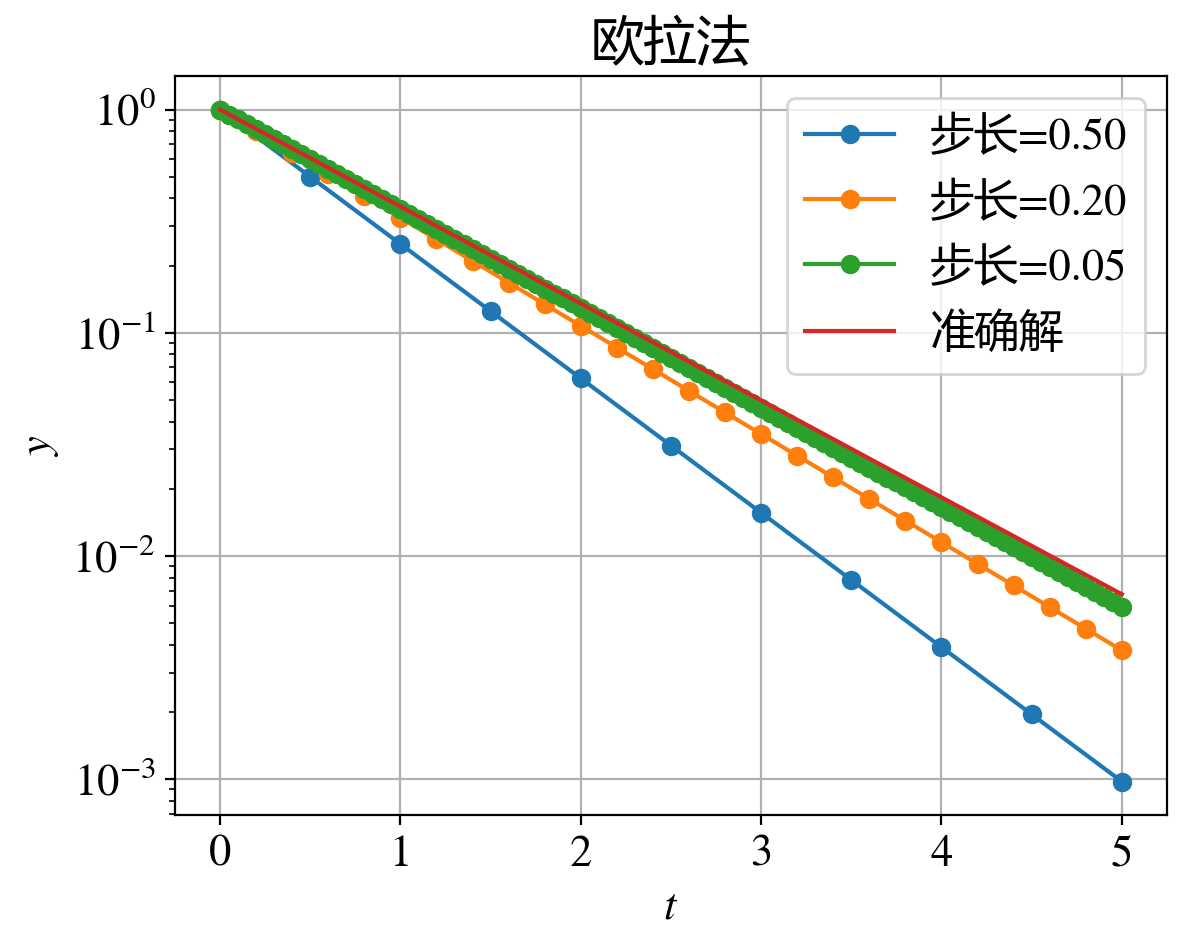

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def f1(t, y):
    """微分方程 dy/dt = f(t, y) 的右端"""
    return -y

def Euler_solver(func, t0, y0, T, h):
    """
    # 参数设置
    func: 代阶一阶常微分方程
    t0: 初始时间
    y0: 初始值
    T: 终止时间
    h: 步长
    """
    # 计算步数
    N = int((T - t0) / h)
    
    # 初始化数组
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    
    # 赋初值
    t[0] = t0
    y[0] = y0
    
    # 欧拉迭代
    for n in range(N):
        t[n+1] = t[n] + h
        y[n+1] = y[n] + h * func(t[n], y[n])

    return t, y

t0 = 0.0      # 初始时间
y0 = 1.0      # 初始值
T  = 5.0      # 终止时间

for _h in [0.5, 0.2, 0.05]:
    _t, _y = Euler_solver(f1, t0, y0, T, _h)
    plt.plot(_t, _y, 'o-', label=f'步长={_h:.2f}')

    
# 解析解用于对比
t_exact = np.linspace(t0, T, 1000)
y_exact = np.exp(-t_exact)

# 作图
plt.plot(t_exact, y_exact, label='准确解')
plt.title("欧拉法")
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

---

## 6. 截断误差：局部与全局

### 6.1 局部截断误差（Local Truncation Error, LTE）

局部截断误差指：假设在某一步的起点 $t_n$ 精确无误（即 $y_n = y(t_n)$），仅在这一小步使用欧拉方法产生的误差。

由泰勒展开：

$$
y(t_n + h) = y(t_n) + h y'(t_n) + \frac{h^2}{2} y''(\xi_n).
$$

欧拉方法给出的近似是：

$$
y_{n+1} = y_n + h f(t_n, y_n) = y(t_n) + h y'(t_n).
$$

所以本步的局部截断误差为：

$$
\tau_{n+1} = y(t_n + h) - y_{n+1} = \frac{h^2}{2} y''(\xi_n).
$$

因此 **局部截断误差阶数为 $O(h^2)$**。

### 6.2 全局截断误差（Global Error）

全局截断误差是指，经过多步积分到达 $t_n$ 时，数值解 $y_n$ 与真实值 $y(t_n)$ 之间的误差。

- 每步带来 $O(h^2)$ 的局部误差
- 一共约 $N \sim (T-t_0)/h$ 步
- 误差在传播和累积的过程中，整体上会累积到 $O(h)$ 级别

因此欧拉方法的 **全局误差为 $O(h)$**，它是一个**一阶方法**。

结论：  
若把步长减半 $h \to h/2$，欧拉方法的全局误差大约会降低一半（在足够小的 $h$ 下）。

---

## 7. 稳定性分析（以测试方程为例）

稳定性是数值解常微分方程中一个重要概念，尤其在计算物理中经常会遇到“刚性方程”。

考虑测试方程：

$$
\frac{dy}{dt} = \lambda y, \quad y(0) = y_0,
$$
其中 $\lambda$ 为复数常数。解析解为

$$
y(t) = y_0 e^{\lambda t}.
$$

当 $\text{Re}(\lambda) < 0$ 时，真实解随时间衰减到 0。

### 7.1 欧拉方法离散化

欧拉方法给出：

$$
y_{n+1} = y_n + h \lambda y_n = (1 + h\lambda) y_n.
$$

所以

$$
y_n = (1 + h\lambda)^n y_0.
$$

我们希望数值解也能够随 $n \to \infty$ 而趋向 0（即保证数值稳定性）。  
这要求：

$$
|1 + h\lambda| < 1.
$$

对于 **实数负 $\lambda < 0$**：

$$
1 + h\lambda \in \mathbb{R}, \quad |1 + h\lambda| < 1
$$

等价于

$$
-1 < 1 + h\lambda < 1
$$
$$
\Rightarrow -2 < h\lambda < 0
$$
$$
\Rightarrow 0 < h < \frac{2}{|\lambda|}.
$$

也就是说，对于衰减快（$|\lambda|$ 很大）的系统，要保持欧拉法稳定，就必须取 **非常小的步长 $h$**。  
这从数值分析角度解释了：欧拉方法在处理刚性问题时效率很低。

---

例子
$$
 \frac{d y}{d t} = y - \frac{2 t}{y}
$$

$y(0) = 1$

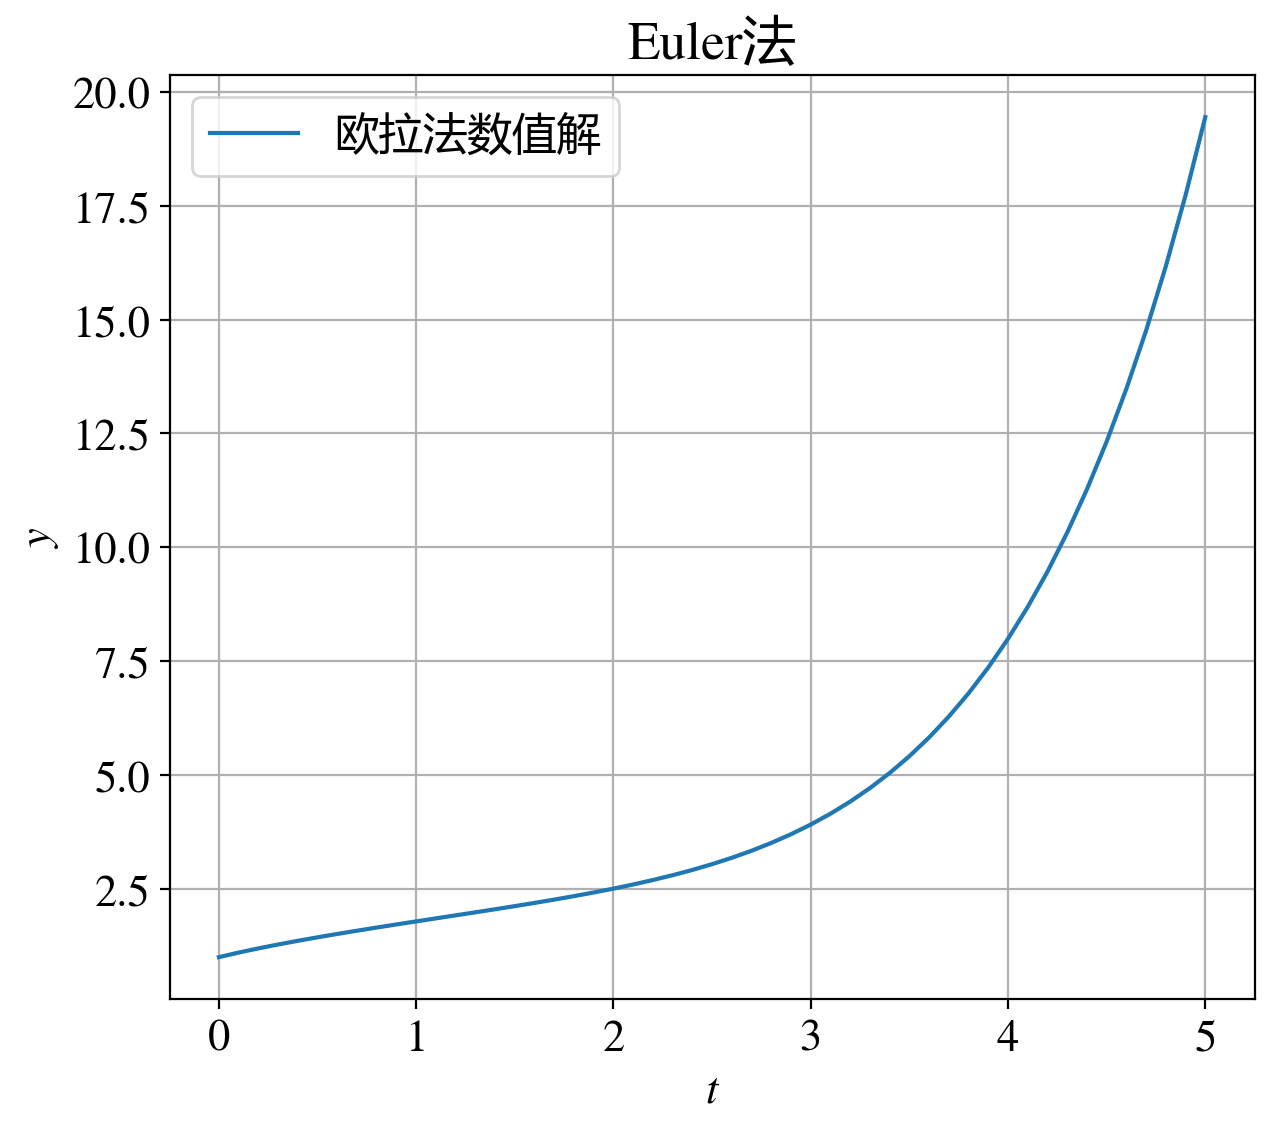

In [73]:
import numpy as np
import matplotlib.pyplot as plt


h = 0.1      # 时间步长
T = 5        # 总时间
N = int(T/h)

# 初始条件
t0 = 0.0
y0 = 1.0

# 分配数组
t_vec = np.zeros(N+1)
y_vec = np.zeros(N+1)

# 设置初值
t_vec[0] = t0
y_vec[0] = y0

# 欧拉时间推进
for n in range( N):
    # 更新位置
    t_vec[n+1] = t_vec[n] + h
    y_vec[n+1] = y_vec[n] + h * ( y_vec[n] - 2 * t_vec[n]/y_vec[n])

# 绘制
fig = plt.figure(figsize=(7, 6))
plt.plot(t_vec, y_vec, label='欧拉法数值解')
plt.xlabel('$t$')
plt.ylabel('$y$') 
plt.grid()
plt.title('Euler法')
plt.legend()
plt.show()

#### 课堂练习
$$
 \frac{d y}{d t} = 4 \cos t
$$

$y(0) = 0$

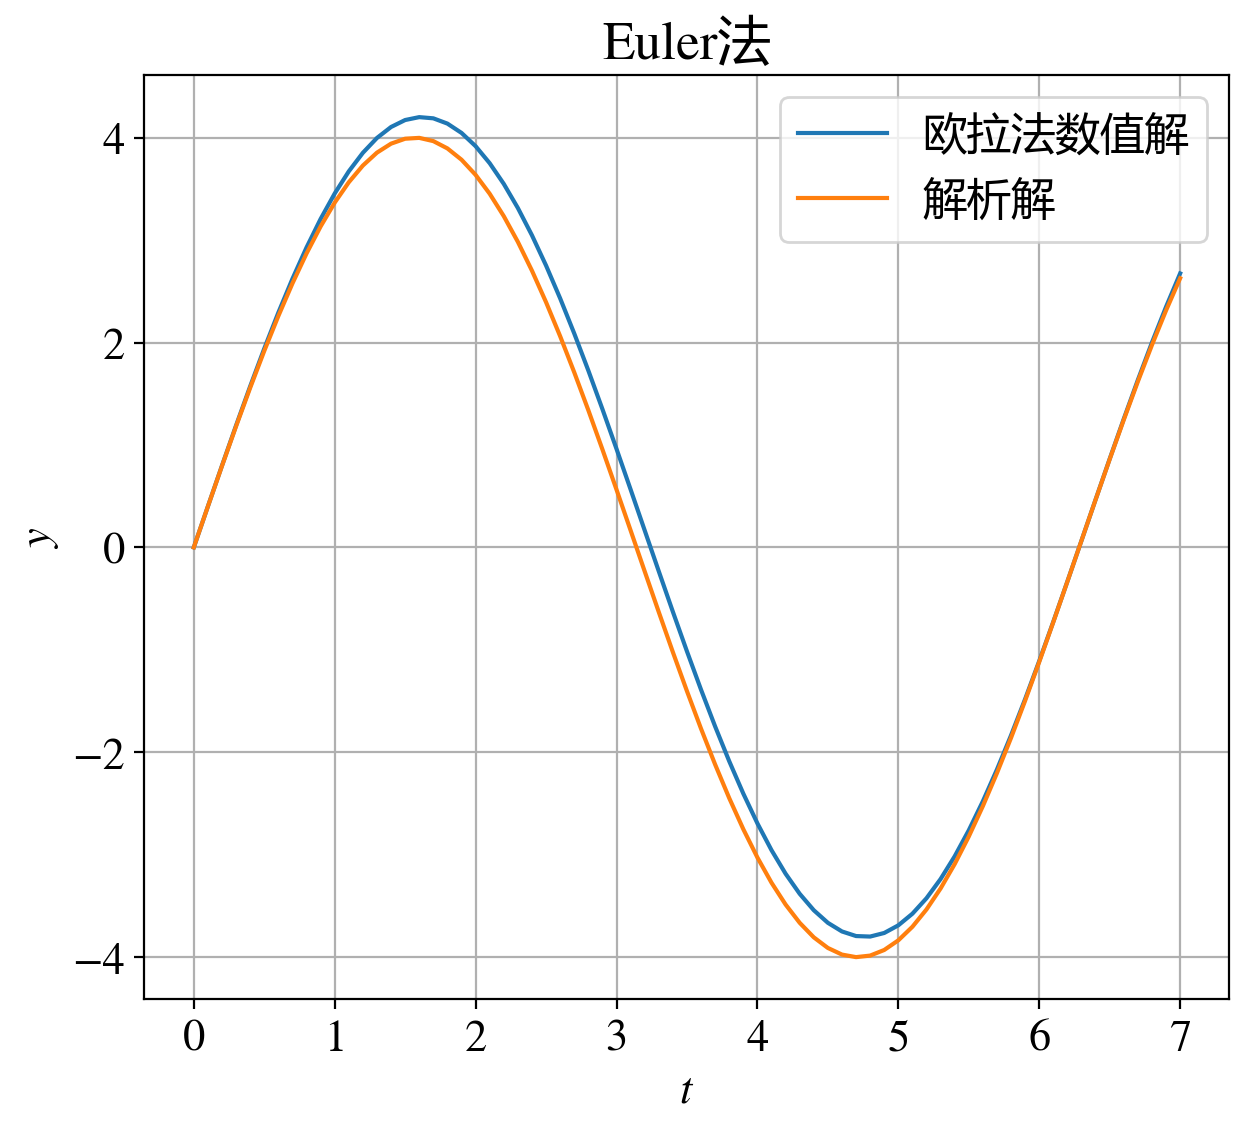

In [75]:
h = 0.1      # 时间步长
T = 7        # 总时间
N = int(T/h)

# 初始条件
t0 = 0.0
y0 = 0.0

# 分配数组
t_vec = np.zeros(N+1)
y_vec = np.zeros(N+1)

# 设置初值
t_vec[0] = t0
y_vec[0] = y0

# 欧拉时间推进
for n in range(N):
    t_vec[n+1] = t_vec[n] + h
    y_vec[n+1] = y_vec[n] + h * 4 * np.cos(t_vec[n])

# 绘制
fig = plt.figure(figsize=(7, 6))
plt.plot(t_vec, y_vec, label='欧拉法数值解')
plt.plot(t_vec, 4*np.sin(t_vec), label='解析解')

plt.xlabel('$t$')
plt.ylabel('$y$') 
plt.grid()
plt.title('Euler法')
plt.legend()
plt.show()

# Runge–Kutta 方法解常微分方程

我们要解决的问题是常微分方程：

$$
\frac{dy}{dt} = f(t,y),\qquad y(t_0) = y_0.
$$

Euler 方法的思路非常简单：

> **用“当前斜率”画一小段直线来前进**  
 $$
 y_{n+1} = y_n + h f(t_n, y_n)
 $$

但这种方式误差较大，因为只看了“起点的斜率”。

---

### **Runge–Kutta 方法的核心思想**: **“不要只看一个斜率，多看几个斜率，求一个更好的平均斜率。”**

---

#### 1. Euler 方法：只看一个斜率

在点 $(t_n, y_n)$：

$$
k_1 = f(t_n, y_n)
$$

一步前进：

$$
y_{n+1} = y_n + h k_1.
$$

→ 只参考起点，误差较大。

---

#### 2. 改进思路：看两次斜率（RK2，中点法）

首先做一次“试探”：

1. 起点斜率  
   $$
   k_1 = f(t_n, y_n)
   $$

2. 走半步（试探点，不是真走）  
   $$
   \tilde y = y_n + \frac{h}{2}k_1
   $$

3. 在中点看斜率  
   $$
   k_2 = f\left(t_n+\frac{h}{2},\; \tilde y\right)
   $$

4. 用中点斜率更新  
   $$
   y_{n+1} = y_n + h k_2.
   $$

**直观理解：**
> 看起点 + 看中点 → 斜率估计更准确。

---

#### 3. 四阶 Runge–Kutta（RK4）：看四次斜率并作加权平均

RK4 的 4 个斜率为：

$$
\begin{aligned}
k_1 &= f(t_n, y_n), \\
k_2 &= f\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_1\right), \\
k_3 &= f\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_2\right), \\
k_4 &= f\left(t_n+h,\, y_n+h k_3\right).
\end{aligned}
$$

最终更新为：

$$
\boxed{
y_{n+1} = 
y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
}
$$

**一句话解释：**
> **RK4 = 同时看“起点、中点、中点、终点”四个方向，然后求一个更靠谱的平均方向。**

---

#### 4. Euler vs Runge–Kutta：直观比较

- **Euler**：  
  只用“起点的斜率” → 很粗糙  
- **RK2**：  
  用“起点+中点的斜率” → 更稳  
- **RK4**：  
  用“起点+两次中点+终点” → 极准

就像你在山路上导航：

- Euler：只看脚下  
- RK4：往前探路四次，综合判断方向，当然更准确。

---

#### 5. RK4 的最小代码实现（Python）

In [77]:
def rk4_step(func, t, y, h):
    
    k1 = func(t, y)
    k2 = func(t + h/2, y + h*k1/2)
    k3 = func(t + h/2, y + h*k2/2)
    k4 = func(t + h,   y + h*k3)
    
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6


def RK4_solver(func, t0, y0, T, h):
    """
    用四阶 Runge-Kutta 方法求解一阶常微分方程初值问题：
        dy/dt = func(t, y),  y(t0) = y0

    参数
    ----
    func : 右端函数 f(t, y)
    t0 : 初始时间
    y0 : 初始值（可以是标量或向量）
    T : 终止时间
    h : 步长

    返回
    ----
    t : ndarray, shape (N+1,),  时间网格
    y : ndarray, 解的近似值
        - 如果 y0 是标量:  shape = (N+1,)
        - 如果 y0 是向量:  shape = (N+1, len(y0))
    """
    # 计算步数
    N = int((T - t0) / h)
    
    # 初始化数组
    t = np.zeros(N + 1)
    
    if np.isscalar(y0):
        y = np.zeros(N + 1)
    else:
        y = np.zeros((N + 1, len(y0)))

    print(y)
    # 赋初值
    t[0] = t0
    y[0] = y0
    
    # 欧拉迭代
    for n in range(N):
        t[n+1] = t[n] + h
        y[n+1] = rk4_step(func, t[n], y[n], h)

    return t, y

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


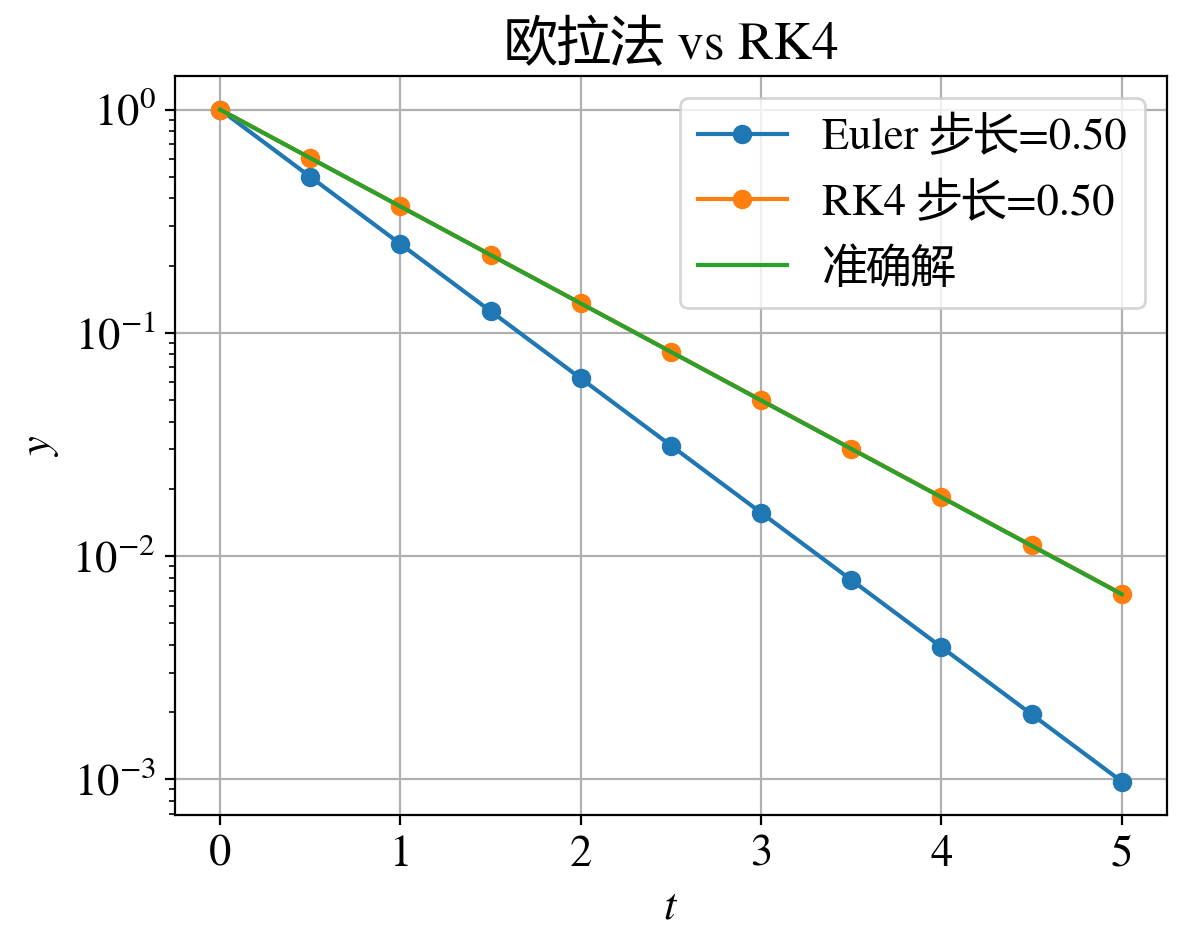

In [78]:
def f1(t, y):
    """微分方程 dy/dt = f(t, y) 的右端"""
    return -y


t0 = 0.0      # 初始时间
y0 = 1.0      # 初始值

T  = 5.0      # 终止时间

for _h in [0.5,]:
    _t, _y = Euler_solver(f1, t0, y0, T, _h)
    plt.plot(_t, _y, 'o-', label=f'Euler 步长={_h:.2f}')
    
    _t, _y = RK4_solver(f1, t0, y0, T, _h)
    plt.plot(_t, _y, 'o-', label=f'RK4 步长={_h:.2f}')

    
# 解析解用于对比
t_exact = np.linspace(t0, T, 1000)
y_exact = np.exp(-t_exact)

# 作图
plt.plot(t_exact, y_exact, label='准确解')
plt.title("欧拉法 vs RK4")
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

### 课堂练习：物理上一阶微分方程练习：放射性衰变方程

#### 1. 物理背景

某种不稳定粒子的数量 $N(t)$ 随时间减少，满足**指数衰减规律**：

$$
\frac{dN}{dt} = -\lambda N,
$$

其中：

- $N(t)$：粒子数量  
- $\lambda > 0$：衰变常数（decay constant）  

解析解为：

$$
N(t) = N_0 e^{-\lambda t}.
$$

但本练习要求 **不要使用解析解**，而是用 **Runge–Kutta 4 阶方法（RK4）** 进行数值模拟。

---

#### 2. 用于 RK4 的右端函数

$$
f(t, N) = -\lambda N
$$

这是典型的一阶 ODE，可以直接用于数值方法。

---

#### 3. 任务

1. 写出 RK4 方法的单步公式，并在 Python 中实现。  
2. 取初值：
   $$
   N(0) = 100,\quad \lambda = 0.3.
   $$
3. 在时间区间 $0 \le t \le 10$ 上求解 $N(t)$。  
4. 将数值解与解析解做对比，绘制在一张图里。  
5. 改变步长 $h = 0.5, 0.1, 0.01$，观察误差随着步长减小是否 ~$O(h^4)$ 下降（RK4 特性）。

---
#### 4. Python 模板（只需填补 rk4_step）


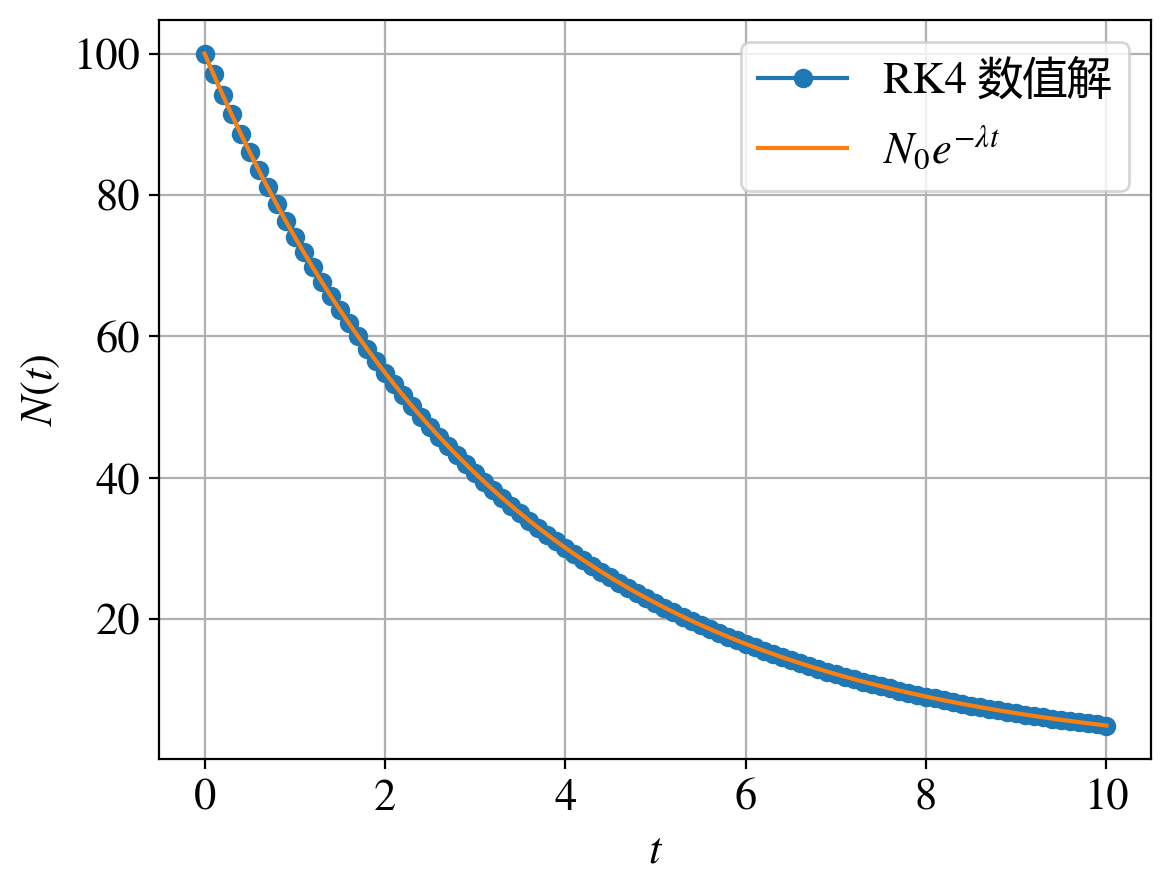

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 参数
# -----------------------------
lam = 0.3        # 衰变常数 λ
N0 = 100.0       # 初值
h = 0.1          # 步长
T = 10
Nsteps = int(T/h)

# -----------------------------
# ODE: dN/dt = -λN
# -----------------------------
def fn4(t, N):
    return -lam * N

# -----------------------------
# RK4 单步（需要补全）
# -----------------------------
def rk4_step(func, t, N, h):
    k1 = func(t, N)
    k2 = func(t + h/2, N + h*k1/2)
    k3 = func(t + h/2, N + h*k2/2)
    k4 = func(t + h, N + h*k3)
    
    return N + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# -----------------------------
# 时间推进
# -----------------------------
t = np.zeros(Nsteps+1)
N_val = np.zeros(Nsteps+1)

t[0] = 0
N_val[0] = N0

for i in range(Nsteps):
    t[i+1] = t[i] + h
    N_val[i+1] = rk4_step(fn4, t[i], N_val[i], h)

# -----------------------------
# 解析解用于对比
# -----------------------------
t_exact = np.linspace(0, T, 1000)
N_exact = N0 * np.exp(-lam * t_exact)

# -----------------------------
# 绘图
# -----------------------------
plt.plot(t, N_val, 'o-', label='RK4 数值解')
plt.plot(t_exact, N_exact, label='$N_0 e^{-\\lambda t}$')
plt.xlabel("$t$")
plt.ylabel("$N(t)$")
plt.legend()
plt.grid(True)
plt.show()

### 课堂练习

用R-K 4阶方法解
$$
 \frac{d y}{d t} = 4 \cos t
$$

$y(0) = 0$

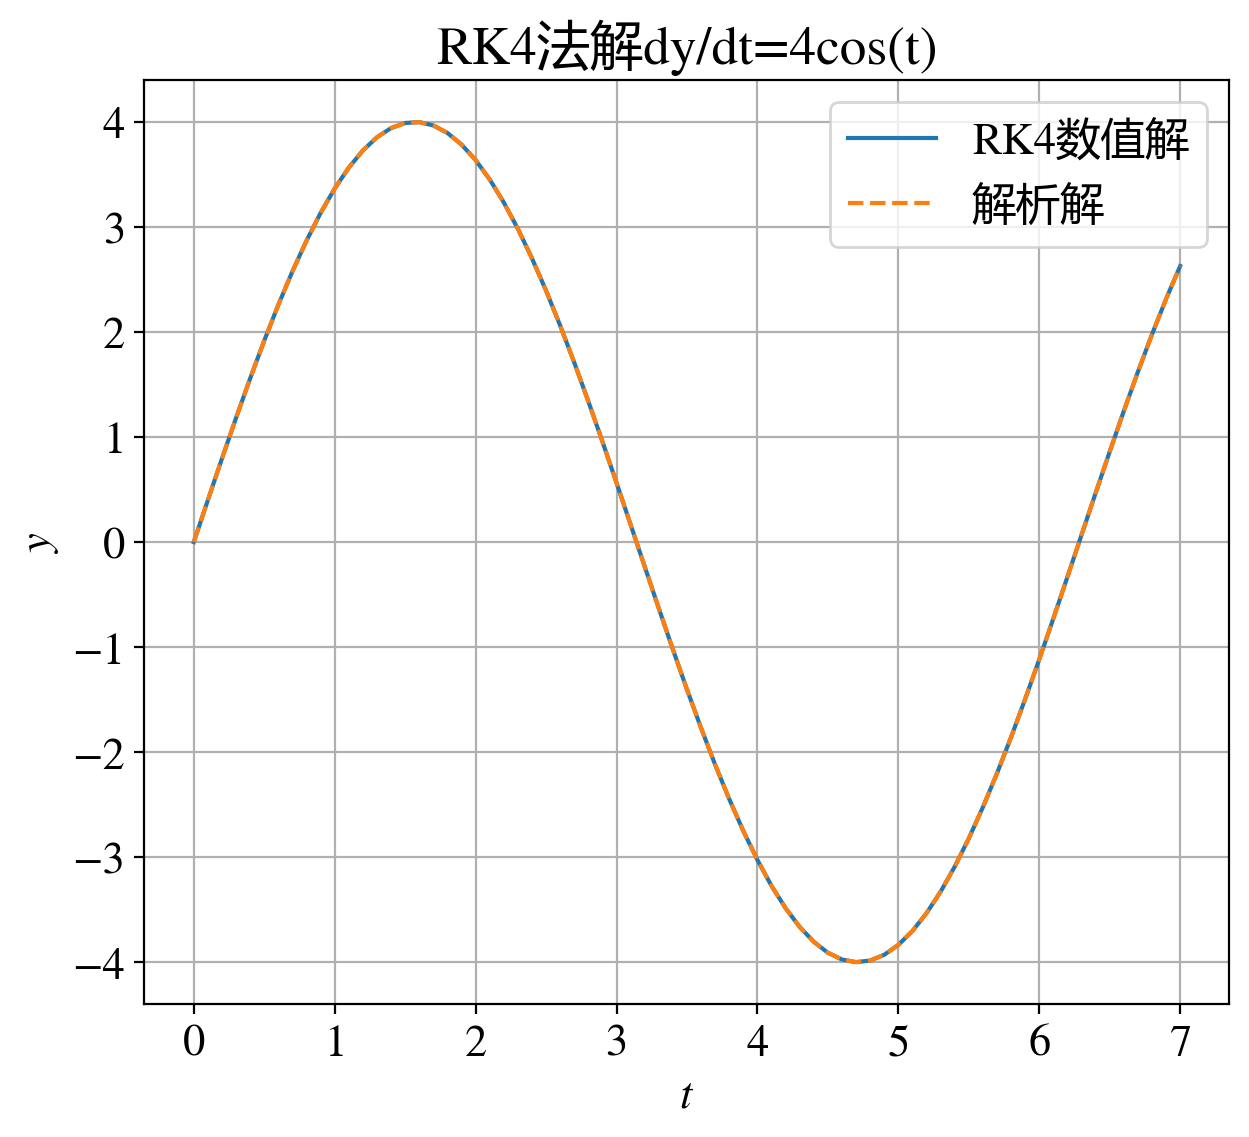

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# 定义微分方程
def f2(t, y):
    return 4 * np.cos(t)

# 复用之前的RK4函数
def rk4_step(func, t, y, h):
    k1 = func(t, y)
    k2 = func(t + h/2, y + h*k1/2)
    k3 = func(t + h/2, y + h*k2/2)
    k4 = func(t + h,   y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

def RK4_solver(func, t0, y0, T, h):
    N = int((T - t0) / h)
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    t[0] = t0
    y[0] = y0
    for n in range(N):
        t[n+1] = t[n] + h
        y[n+1] = rk4_step(func, t[n], y[n], h)
    return t, y

# 设置参数
h = 0.1
T = 7
t0 = 0.0
y0 = 0.0

# 求解
t_vec, y_vec = RK4_solver(f2, t0, y0, T, h)

# 绘图
fig = plt.figure(figsize=(7, 6))
plt.plot(t_vec, y_vec, label='RK4数值解')
plt.plot(t_vec, 4*np.sin(t_vec), '--', label='解析解')
plt.xlabel('$t$')
plt.ylabel('$y$') 
plt.grid()
plt.title('RK4法解dy/dt=4cos(t)')
plt.legend()
plt.show()

---
# 通过变量变换把高阶微分方程转换成一阶微分方程组的方法

高阶常微分方程（ODE）在数值求解时通常要先转化为**一阶微分方程组**，因为大多数数值方法（Euler、RK4、BDF、odeint 等）都只能直接处理一阶系统。

---

## 总思想（一句话）

> **把每一个高阶导数都当作一个新的变量，就能把 n 阶 ODE 转成 n 个一阶 ODE。**

例如三阶方程：

$$
y''' = f(t, y, y', y'')
$$

定义变量：

$$
y_1 = y,\qquad y_2 = y',\qquad y_3 = y''
$$

则有：

$$
\begin{cases}
y_1' = y_2,\qquad \\
y_2' = y_3,\qquad \\
y_3' = f(t, y_1, y_2, y_3)
\end{cases}
$$

这就是一个一阶微分方程组。

---

## 一般方法步骤（适用于任意 n 阶 ODE）

给定 n 阶方程：

$$
y^{(n)} = f(t, y, y', y'', \dots, y^{(n-1)})
$$

---

### **步骤 1：定义新的变量**

$$
\begin{cases}
y_1 = y,\\ 
y_2 = y',\\ 
y_3 = y'',\\ 
\vdots,\\ 
y_n = y^{(n-1)}
\end{cases}
$$

---

### **步骤 2：写出一阶方程**

$$
\begin{cases}
y_1' = y_2 \\
y_2' = y_3
\vdots \\
y_{n-1}' = y_n \\
y_n' = f(t, y_1, y_2,\dots,y_n)
\end{cases}
$$

---

### **步骤 3：写成向量形式**

令

$$
\mathbf y =
\begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{pmatrix}
$$

则系统成为：

$$
\mathbf y' =
\begin{pmatrix}
y_2 \\
y_3 \\
\vdots \\
f(t, y_1,\dots,y_n)
\end{pmatrix}
$$

这是可直接使用数值方法求解的标准 ODE 形式。

---

### 示例 1：二阶 ODE（最常见）
简谐振子：

$$
y'' + \omega^2 y = 0.
$$

定义：

$$
y_1 = y,\qquad y_2 = y'
$$

得到一阶系统：

$$
y_1' = y_2
$$
$$
y_2' = -\omega^2 y_1
$$

---

### 示例 2：三阶 ODE

例如：

$$
y''' = y + \sin t.
$$

定义：

$$
y_1 = y,\quad y_2 = y',\quad y_3 = y''
$$

得到：

$$
y_1' = y_2,\qquad
y_2' = y_3,\qquad
y_3' = y_1 + \sin t
$$

---

### 示例 3：阻尼振子（非线性也适用）

$$
y'' + c y' + k y = 0.
$$

定义：

$$
y_1 = y,\quad y_2 = y'
$$

得到：

$$
y_1' = y_2
$$
$$
y_2' = -c y_2 - k y_1
$$

---

### 示例 4：向量形式的二阶 ODE（如物理中的运动方程）

带电粒子、天体轨道、质点运动等常见二阶向量方程：

$$
\mathbf{x}'' = \mathbf{F}(t, \mathbf{x}, \mathbf{v})
$$

定义：

$$
\mathbf{v} = \mathbf{x}'
$$

得到系统：

$$
\mathbf{x}' = \mathbf{v}
$$
$$
\mathbf{v}' = \mathbf{F}(t, \mathbf{x}, \mathbf{v})
$$

最终转换成一阶系统：

$$
\frac{d}{dt} \begin{pmatrix}
\mathbf{x} \\ \mathbf{v}
\end{pmatrix} =
\begin{pmatrix}
\mathbf{v} \\ \mathbf{F}(t,\mathbf{x},\mathbf{v})
\end{pmatrix}
$$

---

## 小结

- 任意高阶 ODE 都可以转成一阶系统；
- 通过引入变量，把每个导数当作一个新变量；
- 最终写成标准形式：
  $$
  \mathbf y' = \mathbf f(t,\mathbf y)
  $$
- 所有数值求解器都能处理这种形式。

## 带电粒子在均匀磁场中的洛伦兹力运动轨迹

### 1. 物理背景：带电粒子在磁场中的运动

带电粒子（电荷 $q$，质量 $m$）在电磁场中受到 **洛伦兹力**：

$$
\mathbf{F} = q (\mathbf{E} + \mathbf{v}\times \mathbf{B})
$$

若考虑最经典的情形：

- **电场 $\mathbf{E}=0$**
- **磁场 $\mathbf{B} = (0,0,B)$** —— 沿 z 轴的均匀磁场

则运动方程为：

$$
m\frac{d\mathbf{v}}{dt}
= q (\mathbf{v} \times \mathbf{B})
$$

物理预言：  
- 粒子在 xy 平面做匀速圆周运动；  
- 沿 z 方向匀速前进；  
- 合运动轨迹为 **螺旋线（helix）**。


---

### 2.R-K方法

\begin{aligned}
k_1 &= f(t_n, y_n), \\
k_2 &= f\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_1\right), \\
k_3 &= f\left(t_n+\frac{h}{2},\, y_n+\frac{h}{2}k_2\right), \\
k_4 &= f\left(t_n+h,\, y_n+h k_3\right).
\end{aligned}
$$

最终更新为：

$$
\boxed{
y_{n+1} = 
y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
}
$$

#### 速度更新
$$
\mathbf{v}_{n+1} = \mathrm{RK4}( \mathrm{force}, t, \mathbf{v}_n, h ) ,
$$

#### 位置更新
$$
\mathbf{p}_{n+1} = \mathbf{p}_n + h \mathbf{v}_n,
$$

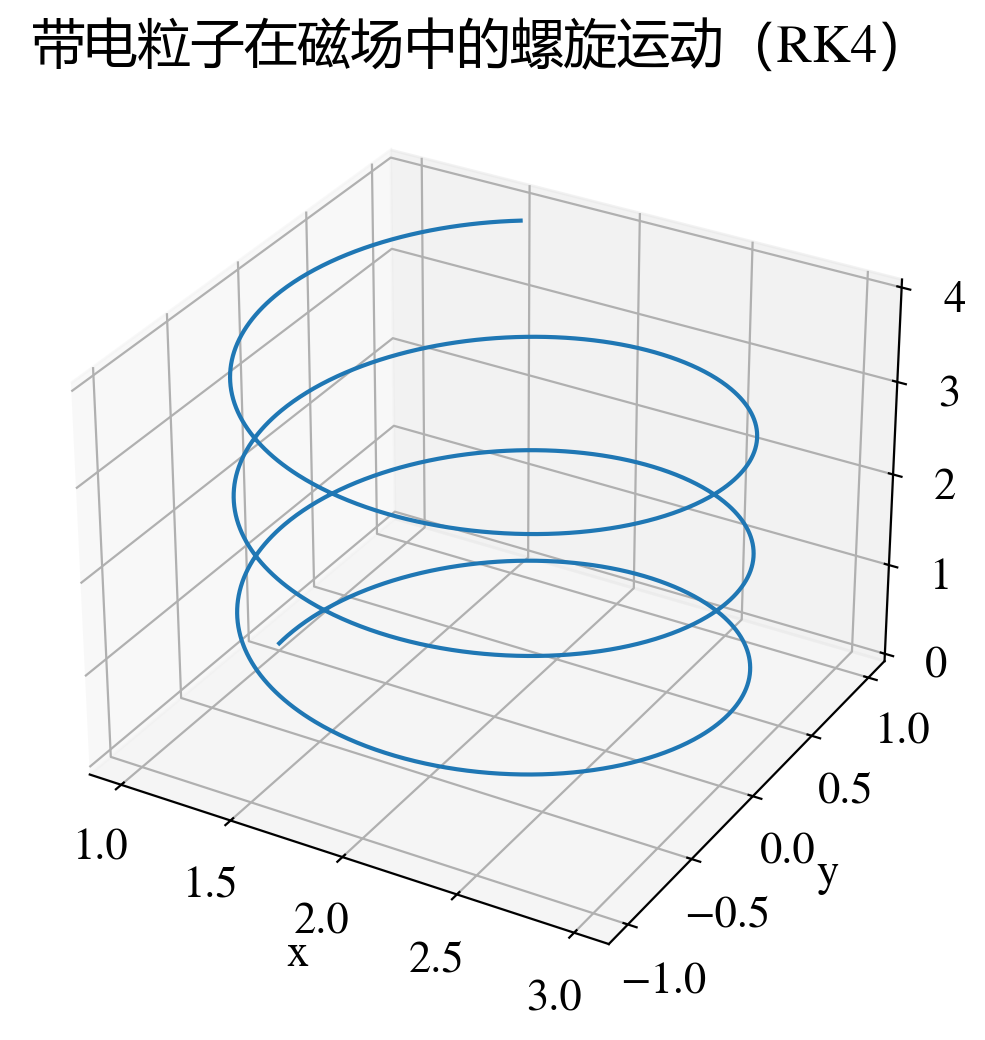

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 物理参数
# =============================
q = 1.0
m = 1.0
B = np.array([0.0, 0.0, 1.0])   # 磁场方向

# 初始条件
p0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 1.0, 0.2])  # 有 vy 和 vz → 螺旋

y0 = np.hstack((p0, v0))

# 时间设置
h = 0.01
T = 20
N = int(T/h)

# =============================
# 定义微分方程 dy/dt = f(t, y)
# =============================
def lorentz_rhs(t, y, ):
    p = y[0:3]
    v = y[3:6]

    dpdt = v
    dvdt = (q/m) * np.cross(v, B)

    return np.hstack((dpdt, dvdt))

# =============================
# RK4 单步
# =============================
def rk4_step(func, t, y, h):
    k1 = func(t,         y,            )
    k2 = func(t + h/2.0, y + h*k1/2.0, )
    k3 = func(t + h/2.0, y + h*k2/2.0, )
    k4 = func(t + h,     y + h*k3,     )

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6.0

# =============================
# 主循环：用 RK4 时间推进
# =============================
t = np.zeros(N+1)
y = np.zeros((N+1, 6))

t[0] = 0
y[0] = y0

for n in range(N):
    t[n+1] = t[n] + h
    y[n+1] = rk4_step(lorentz_rhs, t[n], y[n], h)

# 拆分出位置与速度
p = y[:, 0:3]
v = y[:, 3:6]

# =============================
# 绘图
# =============================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(p[:,0], p[:,1], p[:,2], lw=1.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("带电粒子在磁场中的螺旋运动（RK4）")

plt.show()


### 课堂练习：数值计算简谐振子运动过程

#### 一、练习目标

1. 将二阶微分方程改写为一阶方程组；
2. 使用欧拉方法数值求解简谐振子的时间演化；
4. 绘制位移 x(t)、速度 v(t) 或相空间轨迹；

---

#### 二、物理模型

无阻尼简谐振子满足方程：
$$
\frac{d^2x}{dt^2} + \omega^2 x = 0.
$$

引入速度变量：

$$
v = \frac{dx}{dt},
$$

可转化为一阶系统：

$$
\frac{dx}{dt} = v,
\qquad
\frac{dv}{dt} = -\omega^2 x.
$$

其解析解为周期 $T = 2\pi / \omega$ 的周期振动。

---

#### 三、任务内容

**任务：**

1. 用欧拉方法数值求解上述 ODE，得到 $x(t), v(t)$；
2. 绘制以下至少一张图：  
   - 区间内的位移随时间 $x(t)$  
   - 区间内的速度随时间 $v(t)$  
   - 区间内的相空间轨迹 $v$–$x$

---

#### 四、数值方案（欧拉方法）

对步长 $h$：

$$
x_{n+1} = x_n + h v_n,
\qquad
v_{n+1} = v_n - h\omega^2 x_n.
$$

#### 五、补全一下 Python 代码

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 参数 =====
omega = 2.0
h = 0.001
T_total = 10
N = int(T_total / h)

# 初值
x0 = 1.0
v0 = 0.0

# 要提取的位置区间
x_min = 0.2
x_max = 0.8

# ===== 分配数组 =====
t = np.zeros(N+1)
x = np.zeros(N+1)
v = np.zeros(N+1)

# 初值
x[0] = x0
v[0] = v0

# ===== 欧拉法推进 =====
for n in range(N):
    t[n+1] = t[n] + h
    
    # TODO: 写出 x[n+1]
    # x[n+1] = ?

    # TODO: 写出 v[n+1]
    # v[n+1] = ?

## ===== 从全部数据中筛选区间内的点 =====
#mask = (x >= x_min) & (x <= x_max)
#t_sel = t[mask]
#x_sel = x[mask]
#v_sel = v[mask]

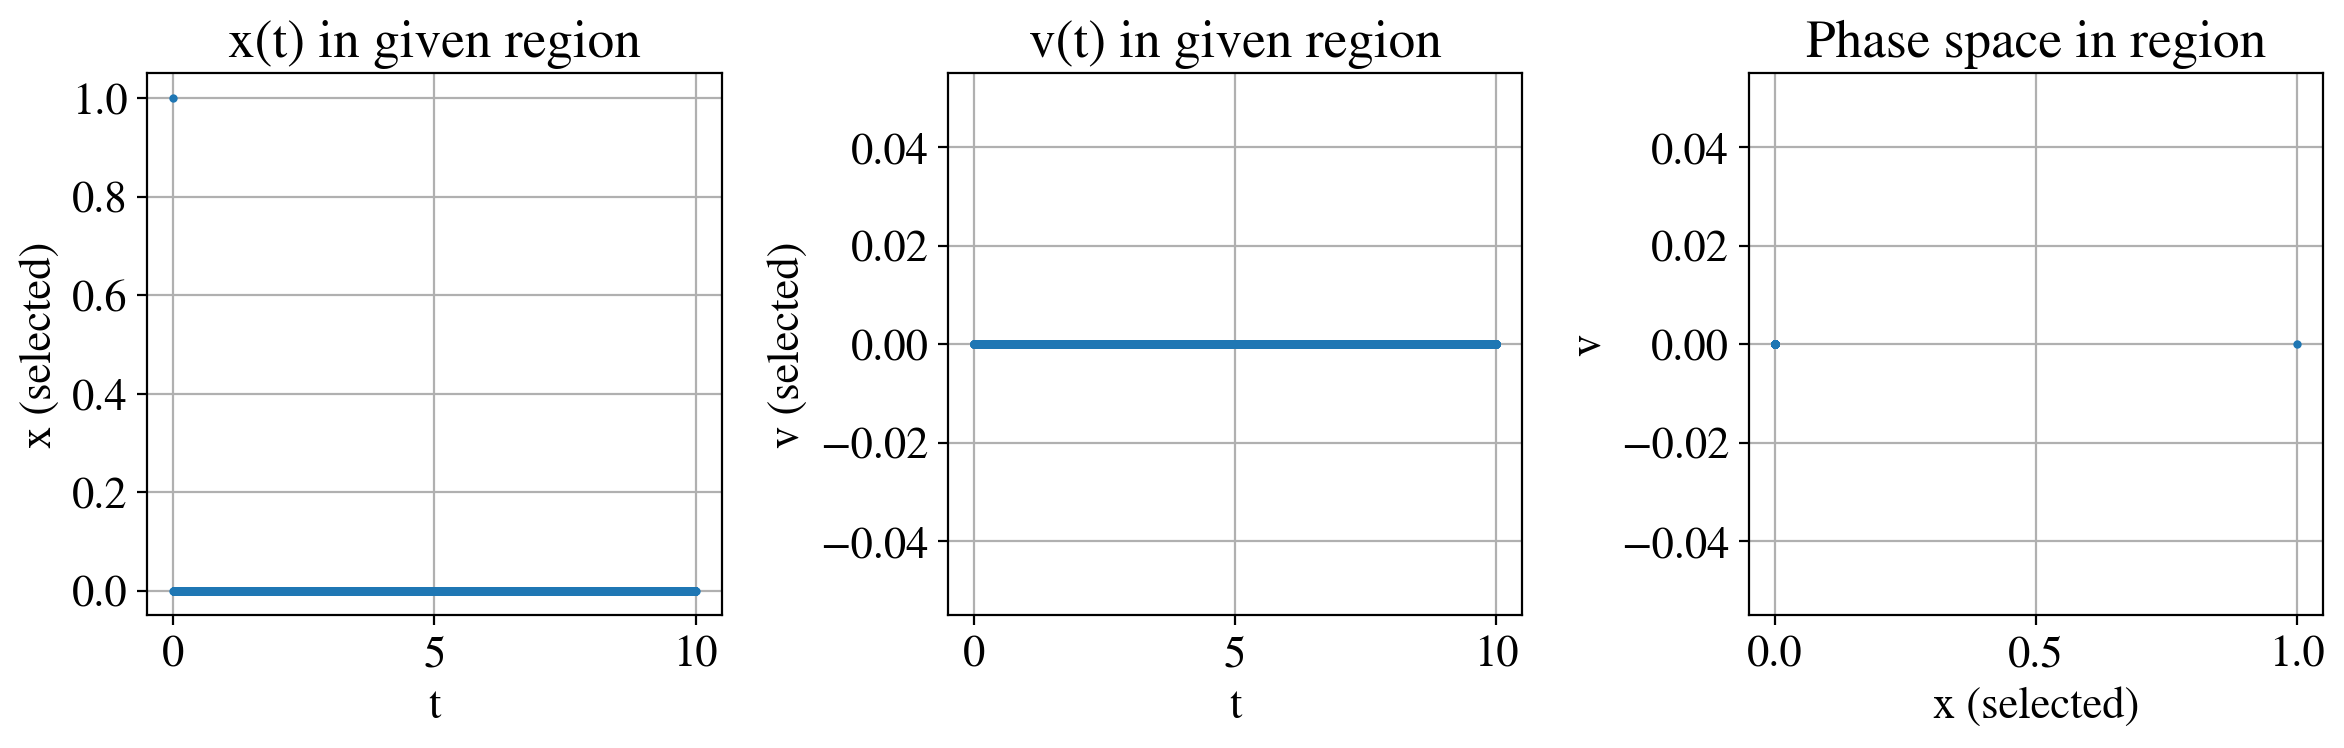

In [90]:
# ===== 绘图 =====
plt.figure(figsize=(12,4))

# 1. 位移-时间
plt.subplot(1,3,1)
plt.plot(t, x, 'o', markersize=2)
plt.xlabel("t")
plt.ylabel("x (selected)")
plt.title("x(t) in given region")
plt.grid(True)

# 2. 速度-时间
plt.subplot(1,3,2)
plt.plot(t, v, 'o', markersize=2)
plt.xlabel("t")
plt.ylabel("v (selected)")
plt.title("v(t) in given region")
plt.grid(True)

# 3. 相空间
plt.subplot(1,3,3)
plt.plot(x, v, 'o', markersize=2)
plt.xlabel("x (selected)")
plt.ylabel("v")
plt.title("Phase space in region")
plt.grid(True)

plt.tight_layout()
plt.show()

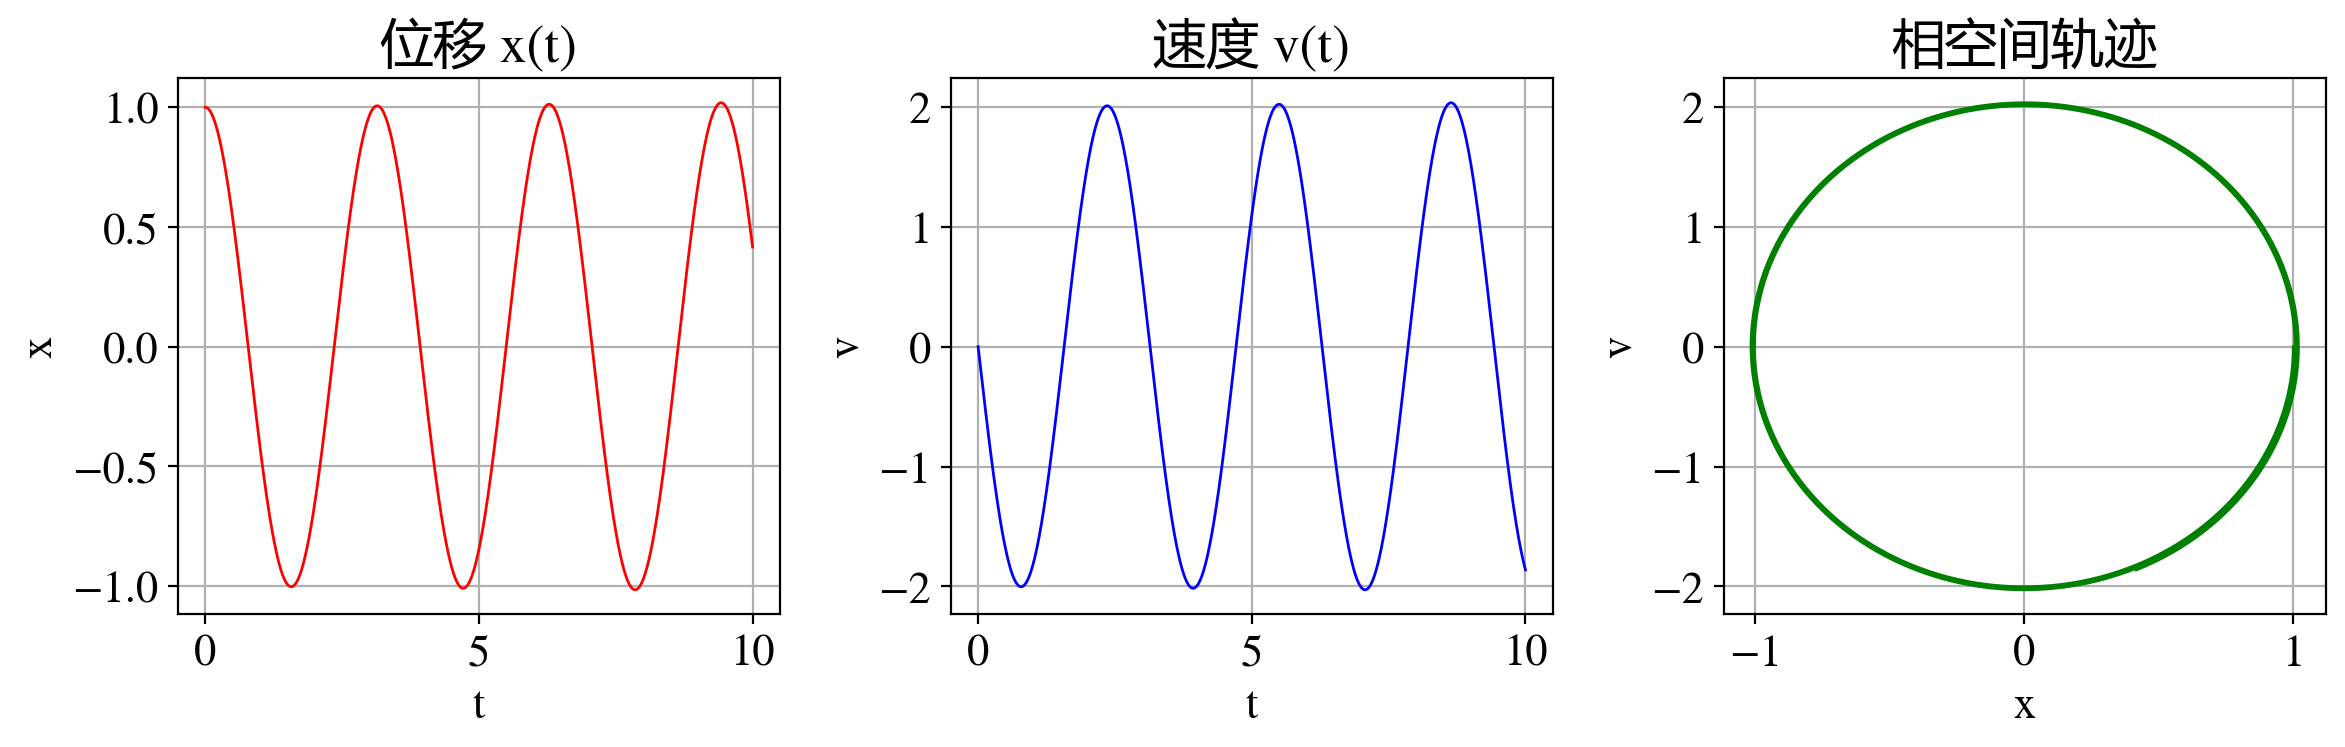

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 参数 =====
omega = 2.0    # 角频率
h = 0.001      # 步长（二阶ODE需要更小的步长）
T_total = 10   # 总时间
N = int(T_total / h)  # 步数

# 初值
x0 = 1.0       # 初始位移
v0 = 0.0       # 初始速度

# ===== 分配数组 =====
t = np.zeros(N+1)
x = np.zeros(N+1)
v = np.zeros(N+1)

# 初值
x[0] = x0
v[0] = v0

# ===== 欧拉法推进 =====
for n in range(N):
    t[n+1] = t[n] + h
    # 欧拉公式：x[n+1] = x[n] + h * v[n]（位移更新）
    x[n+1] = x[n] + h * v[n]
    # 欧拉公式：v[n+1] = v[n] + h * (-omega² x[n])（速度更新）
    v[n+1] = v[n] - h * omega**2 * x[n]

# ===== 绘图 =====
plt.figure(figsize=(12,4))

# 1. 位移-时间
plt.subplot(1,3,1)
plt.plot(t, x, 'r-', linewidth=1)
plt.xlabel("t")
plt.ylabel("x")
plt.title("位移 x(t)")
plt.grid(True)

# 2. 速度-时间
plt.subplot(1,3,2)
plt.plot(t, v, 'b-', linewidth=1)
plt.xlabel("t")
plt.ylabel("v")
plt.title("速度 v(t)")
plt.grid(True)

# 3. 相空间（x-v图，简谐振子是椭圆）
plt.subplot(1,3,3)
plt.plot(x, v, 'g-', linewidth=1)
plt.xlabel("x")
plt.ylabel("v")
plt.title("相空间轨迹")
plt.grid(True)

plt.tight_layout()
plt.show()

# 用差分方法求解常微分方程（ODE）的**边值问题（Boundary Value Problem, BVP）**

常微分方程的 **边值问题（BVP）** 是指未知函数 $y(x)$ 的值需要同时满足在 **区间两端的条件**，例如：

$$
y''(x) = f(x, y, y'), \qquad x \in [a,b]
$$
$$
y(a) = \alpha,\qquad y(b) = \beta
$$

与初值问题不同：

- **初值问题（IVP）**：起点已知 $y(a)=\alpha$、$y'(a)=v$
- **边值问题（BVP）**：两端点都给定，但通常缺少导数的初始条件

差分方法（Finite Difference Method, FDM）是最常见、最简单的 BVP 数值解法。

---

### 🌟 1. 基本思想（离散替代微分）

把区间 $[a,b]$ 等分成 $N$ 个网格点：

$$
x_0=a,\;x_1,\;\dots,\;x_N=b
$$

步长：

$$
h = \frac{b-a}{N}
$$

在每个网格点上，将微分方程：

$$
y''(x)=g(x,y)
$$

用差分公式替代：

---

### ⭐ 二阶导数的差分近似

中心差分：

$$
y''(x_i) \approx \frac{y_{i+1}-2y_i+y_{i-1}}{h^2}
$$

于是微分方程变成代数方程：

$$
\frac{y_{i+1}-2y_i+y_{i-1}}{h^2} = g(x_i, y_i)
$$

这对每个内部点 $i=1,\dots,N-1$ 成立。

---

### 🌟 2. 构建代数方程组

对每个内部点得到一个方程，配上两端边界条件：

$$
y_0 = \alpha,\qquad y_N = \beta
$$

于是有 $N-1$ 个未知数：

$$
y_1, y_2, \dots, y_{N-1}
$$

代数方程的形式：

$$
- y_{i-1} + 2y_i - y_{i+1} = h^2 g(x_i, y_i)
$$

形成一个三对角线性方程组（如果 g 与 y 线性），或非线性方程组（若 g 非线性）。

---

### 🌟 3. 典型示例

考虑方程：
$$
y''(x) = -1,\quad x \in [0,1]
$$
边界条件：
$$
y(0)=0,\quad y(1)=0
$$

解析解为：
$$
y(x) = \frac12 x(1-x)
$$

下面用差分方法逼近 $y(x)$。

---

## Python 实现
---

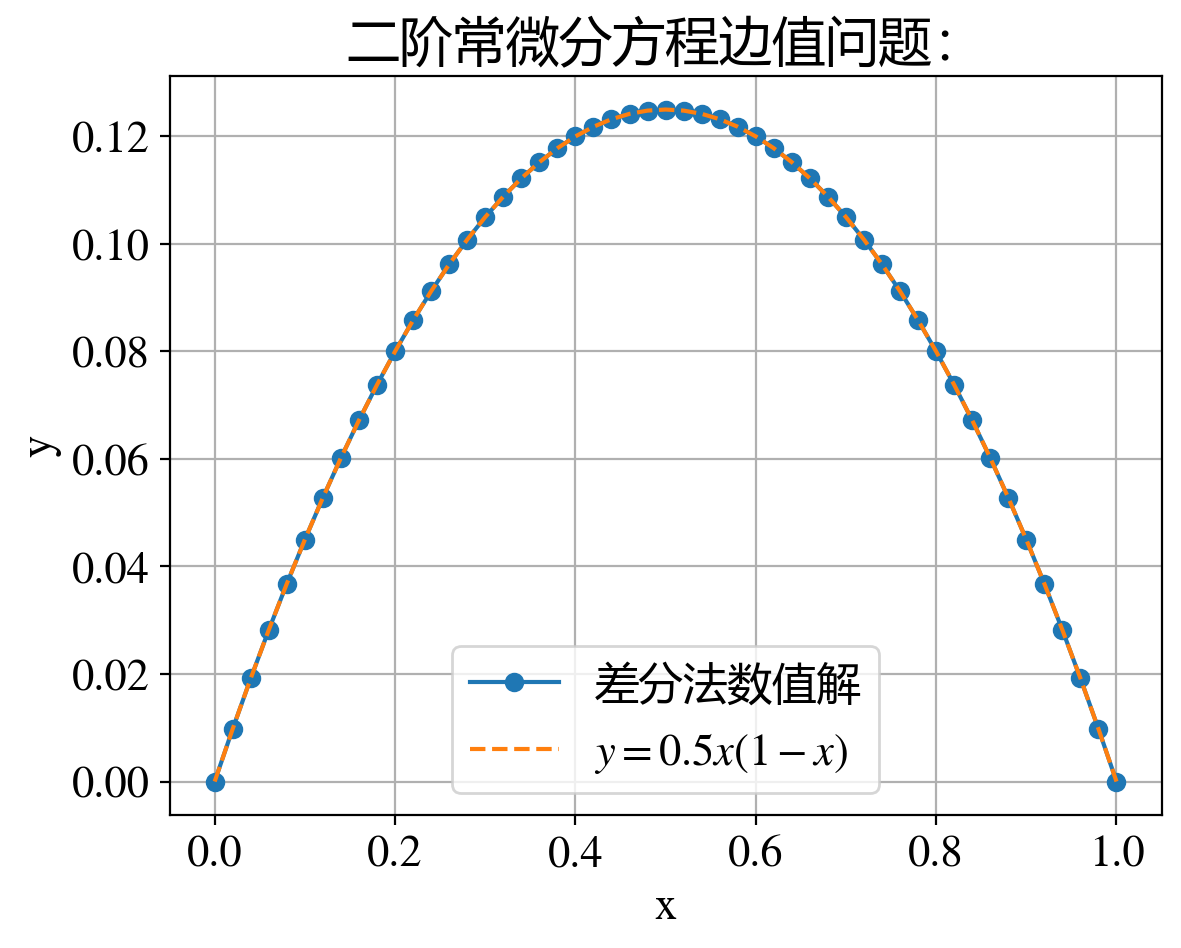

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# 区间设置
a, b = 0, 1
N = 50
h = (b - a) / N

x = np.linspace(a, b, N+1)

# 边界条件
y0 = 0
yN = 0

# 构造三对角线矩阵 A 和右端向量 b
A = np.zeros((N-1, N-1))
b_vec = np.zeros(N-1)

for i in range(1, N):
    # 构造三对角矩阵
    A[i-1, i-1] = -2
    if i-1 > 0:
        A[i-1, i-2] = 1
    if i < N-1:
        A[i-1, i] = 1

    # 右端项：h^2 * f(x) = h^2 * (-1)
    b_vec[i-1] = -h**2

# 加入边界影响
b_vec[0] -= y0
b_vec[-1] -= yN

# 求解线性系统
y_inner = np.linalg.solve(A, b_vec)

# 拼接边界点
y = np.zeros(N+1)
y[0] = y0
y[1:N] = y_inner
y[N] = yN

# 解析解
y_exact = 0.5 * x * (1 - x)

# 绘图
plt.plot(x, y, 'o-', label='差分法数值解')
plt.plot(x, y_exact, '--', label='$y=0.5 x(1-x)$')
plt.xlabel("x")
plt.ylabel("y")
plt.title("二阶常微分方程边值问题：")
plt.grid(True)
plt.legend()
plt.show()

### 示例： 为了使烟花从地面发射5秒后在距离地面上40米的高空爆炸，初始发射速度应为多大？（考虑空气阻力与速度成正比，阻力系数为$\alpha=0.01$）
### [解]：用差分法求解边值问题：
$$
    y'' = -9.8 - 0.01 y'
$$
边界条件：
$$
    y(0) = 0, \quad  y(5) = 40
$$

基本思路：
1. 在区间 [0, 5] 上划分网格：$x_0, x_1, ..., x_N$
2. 在内部节点 $x_i (i = 1,...,N-1)$ 上，用中心差分逼近 $y'$ 和 $y''$
   - $y''(x_i) ≈ (y_{i+1} - 2 y_i + y_{i-1}) / h^2 $
   - $y'(x_i) ≈ (y_{i+1} - y_{i-1}) / (2 h) $
3. 将微分方程
      $ y'' = -9.8 - 0.01 y' $
   替换为差分方程，并整理成线性代数方程组 $ A y = b $
4. 利用 `numpy.linalg.solve` 求解内部节点的 $y_i$，再加上边界 $y(0)$, $y(5)$

#### 推导差分方程

对于微分方程：

$$
y'' = -9.8 - 0.01\, y',
$$

在网格点 $x_i$ 处使用中心差分近似：

$$
y''(x_i) \approx \frac{y_{i+1} - 2y_i + y_{i-1}}{h^2},
$$
$$
y'(x_i) \approx \frac{y_{i+1} - y_{i-1}}{2h}.
$$

将它们代入微分方程得到：

$$
\frac{y_{i+1} - 2y_i + y_{i-1}}{h^2}
= -9.8 - 0.01 \cdot \frac{y_{i+1} - y_{i-1}}{2h}.
$$

---

#### 两边乘以 $h^2$

$$
y_{i+1} - 2y_i + y_{i-1}
= -9.8 h^2 - 0.01 h^2 \cdot \frac{y_{i+1} - y_{i-1}}{2h},
$$

化简第二项：

$$
y_{i+1} - 2y_i + y_{i-1}
= -9.8 h^2 - 0.01 h \frac{(y_{i+1}-y_{i-1})}{2}.
$$

---

### 整理含 $y_{i\pm1}$ 的项

将右侧涉及 $y_{i+1}, y_{i-1}$ 的项移到左边：

$$
(1 + \alpha) y_{i+1} - 2 y_i + (1 - \alpha) y_{i-1} + 9.8 h^2 = 0,
$$

其中：

$$
\alpha = \frac{0.01h}{2}.
$$

---

### 对内部节点 $i = 1, \dots, N-1$ 的最终差分格式

$$
(1 - \alpha) y_{i-1} - 2 y_i + (1 + \alpha) y_{i+1}
= - 9.8 h^2.
$$

在 $i = 1$ 和 $i = N-1$ 处，方程包含边界节点 $y_0$ 和 $y_N$，需要将它们的贡献移到右端向量 $b_{\text{vec}}$ 中。

$$
\begin{pmatrix}
-2 & 1+\alpha & 0 & \cdots & 0 \\
1-\alpha & -2 & 1+\alpha & \cdots & 0 \\
0 & 1-\alpha & -2 & \ddots & 0 \\
\vdots & \vdots & \ddots & \ddots & 1+\alpha \\
0 & 0 & 0 & 1-\alpha & -2
\end{pmatrix}
\begin{pmatrix}
y_1 \\ y_2 \\ y_3 \\ \vdots \\ y_{N-2} \\ y_{N-1}
\end{pmatrix} =
\begin{pmatrix}
-9.8 h^2 - (1-\alpha) \cdot 0 \\
-9.8 h^2 \\
-9.8 h^2 \\
\vdots \\
-9.8 h^2 \\
-9.8 h^2 - (1+\alpha) \cdot 40
\end{pmatrix}.
$$

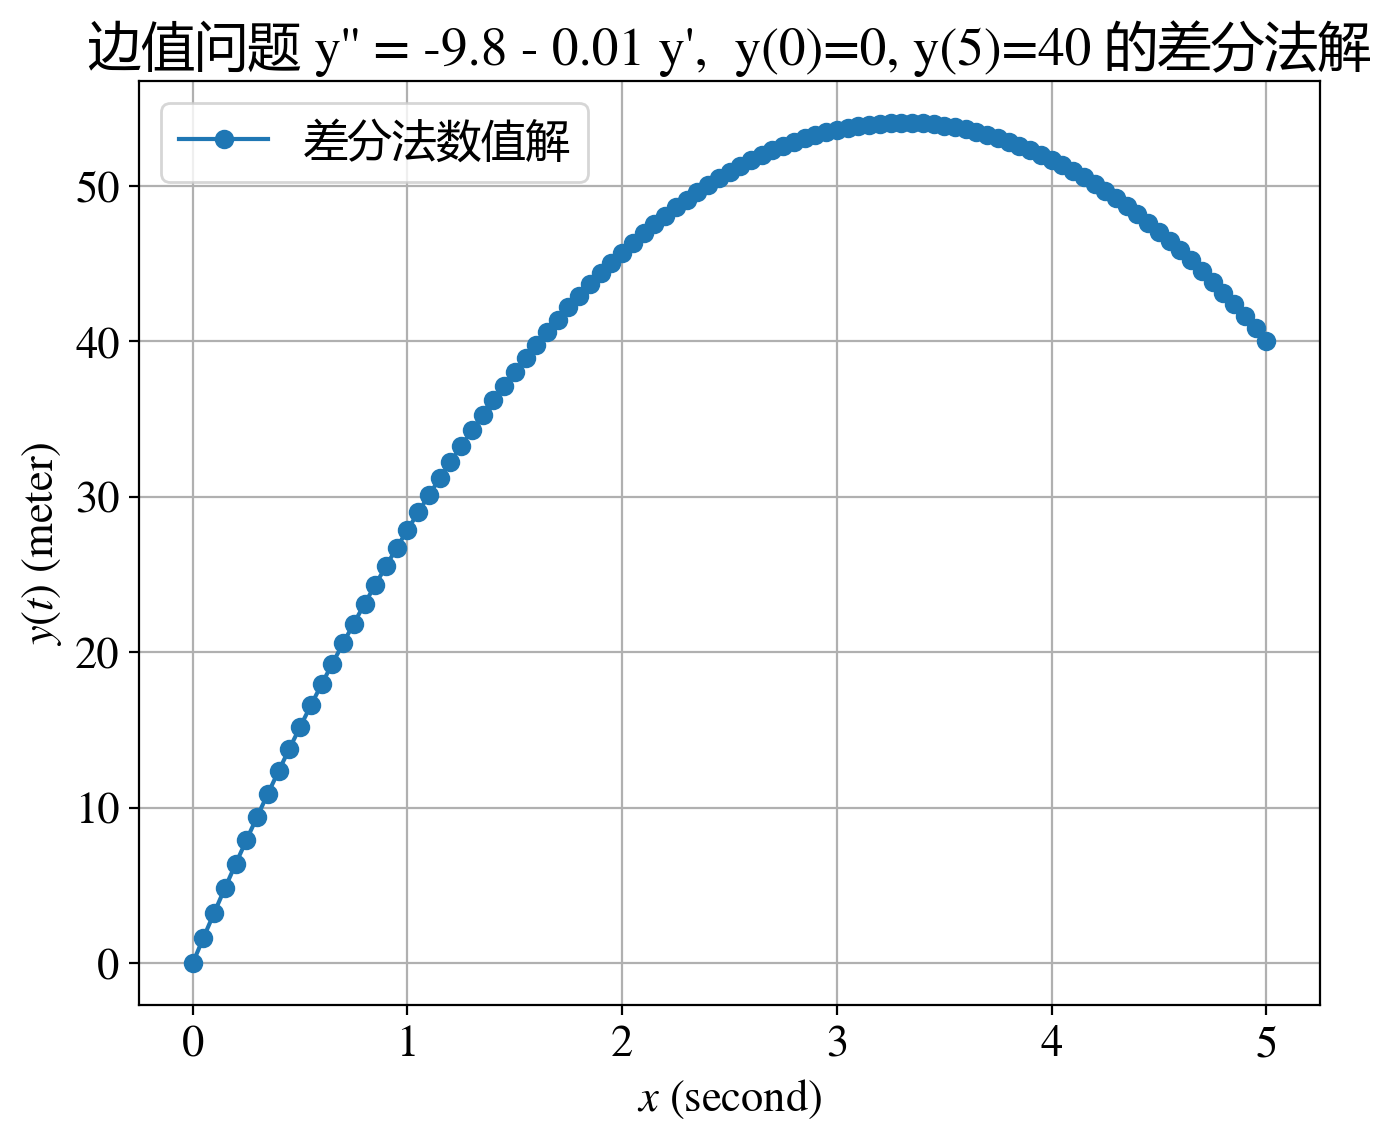

In [95]:
import numpy as np
import matplotlib.pyplot as plt


# 区间与网格
a, b = 0.0, 5.0     # x ∈ [a, b]
N = 100             # 将区间等分成 N 段，N+1 个节点
h = (b - a) / N     # 网格步长

x = np.linspace(a, b, N+1)  # 节点坐标 x_0,...,x_N

# 边界条件
y0 = 0.0   # y(0)
yN = 40.0  # y(5)

# 系数：来自一阶导数差分项中的 0.01 * y'
alpha = 0.01 * h / 2.0   # 方便记号：alpha = 0.01 * h / 2

# 我们要求解的是内部节点 y_1,...,y_{N-1}，共 N-1 个未知数
A = np.zeros((N-1, N-1))   # 系数矩阵
b_vec = np.zeros(N-1)      # 右端项向量

for i in range(1, N):   # i = 1,...,N-1 对应内部节点
    row = i - 1         # 在线性系统中的行索引 0,...,N-2

    # 三对角系数
    coeff_left  = 1.0 - alpha   # y_{i-1} 系数
    coeff_mid   = -2.0          # y_i 系数
    coeff_right = 1.0 + alpha   # y_{i+1} 系数

    # 设置主对角
    A[row, row] = coeff_mid

    # 设置左邻（注意 i>1 时存在 y_{i-1}，否则是边界 y_0）
    if i > 1:
        A[row, row - 1] = coeff_left
    else:
        # i = 1 时，y_{0} 已知，将 coeff_left * y0 移到右端
        b_vec[row] -= coeff_left * y0

    # 设置右邻（注意 i<N-1 时存在 y_{i+1}，否则是边界 y_N）
    if i < N - 1:
        A[row, row + 1] = coeff_right
    else:
        # i = N-1 时，y_N 已知，将 coeff_right * yN 移到右端
        b_vec[row] -= coeff_right * yN

    # 来自常数项 -9.8 的右端项：等式右侧是 -9.8 h^2
    b_vec[row] += -9.8 * h**2

# 现在 A * y_inner = b_vec，其中 y_inner = [y_1,...,y_{N-1}]
y_inner = np.linalg.solve(A, b_vec)

# 拼接上边界点，得到完整解 y_0,...,y_N
y = np.zeros(N+1)
y[0] = y0
y[1:N] = y_inner
y[N] = yN

# -----------------------------
# 画出数值解
# -----------------------------
plt.figure(figsize=(7, 6))
plt.plot(x, y, 'o-', label="差分法数值解")

plt.xlabel("$x$ (second)")
plt.ylabel("$y(t)$ (meter)")
plt.title("边值问题 y'' = -9.8 - 0.01 y',  y(0)=0, y(5)=40 的差分法解")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [96]:
(y[2] - y[0])/(2*h)

np.float64(32.39954113287544)

初始发射速度约为：32.65 米/秒


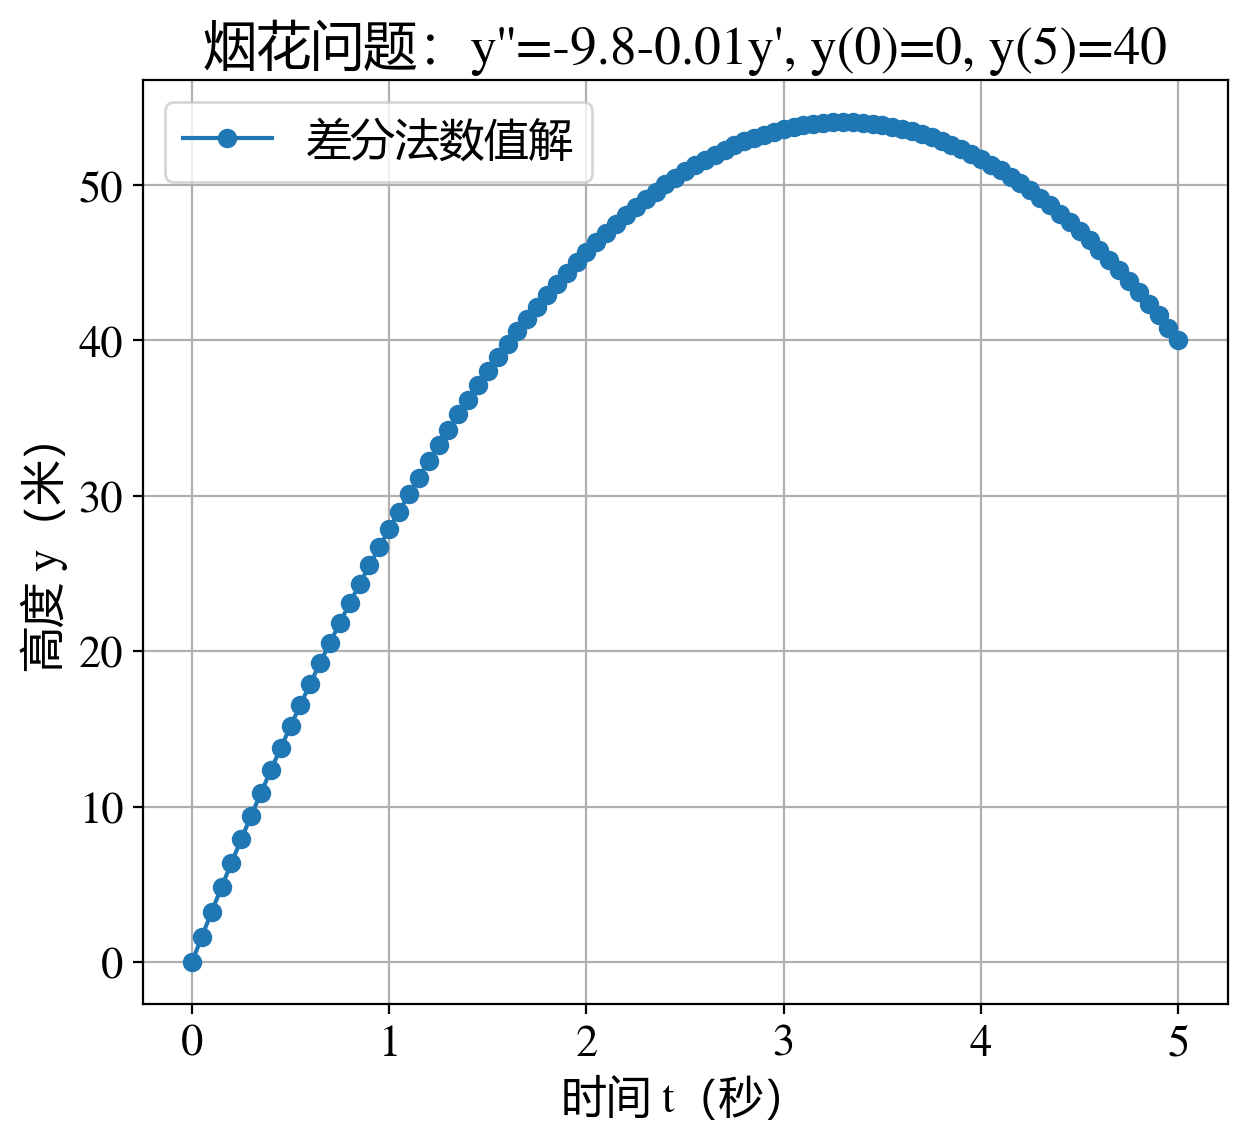

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# 区间与网格
a, b = 0.0, 5.0     # 时间区间[0,5]
N = 100             # 分成100段
h = (b - a) / N     # 步长

x = np.linspace(a, b, N+1)  # 所有时间点

# 边界条件
y0 = 0.0   # y(0)=0
yN = 40.0  # y(5)=40

# 系数：alpha = 0.01*h/2（来自一阶导数的差分）
alpha = 0.01 * h / 2.0

# 构造线性方程组的系数矩阵A和右端向量b_vec
A = np.zeros((N-1, N-1))   # N-1个内部点，对应N-1阶矩阵
b_vec = np.zeros(N-1)      # 右端向量

for i in range(1, N):   # 遍历内部点（i=1到N-1）
    row = i - 1         # 矩阵的行索引（从0开始）
    
    # 三对角系数
    coeff_left  = 1.0 - alpha   # y_{i-1}的系数
    coeff_mid   = -2.0          # y_i的系数
    coeff_right = 1.0 + alpha   # y_{i+1}的系数

    # 设置主对角线（y_i的系数）
    A[row, row] = coeff_mid

    # 处理左邻点（i>1时，y_{i-1}是内部点；i=1时，y_0是边界）
    if i > 1:
        A[row, row - 1] = coeff_left
    else:
        # i=1时，y_0已知，移到右端
        b_vec[row] -= coeff_left * y0

    # 处理右邻点（i<N-1时，y_{i+1}是内部点；i=N-1时，y_N是边界）
    if i < N - 1:
        A[row, row + 1] = coeff_right
    else:
        # i=N-1时，y_N已知，移到右端
        b_vec[row] -= coeff_right * yN

    # 右端项：-9.8*h²
    b_vec[row] += -9.8 * h**2

# 求解线性方程组
y_inner = np.linalg.solve(A, b_vec)

# 拼接边界点，得到完整解
y = np.zeros(N+1)
y[0] = y0
y[1:N] = y_inner
y[N] = yN

# 计算初始速度（用差分近似：y'(0) ≈ (y[1]-y[0])/h）
v0 = (y[1] - y[0])/h
print(f"初始发射速度约为：{v0:.2f} 米/秒")

# 绘图
plt.figure(figsize=(7, 6))
plt.plot(x, y, 'o-', label="差分法数值解")
plt.xlabel("时间 t（秒）")
plt.ylabel("高度 y（米）")
plt.title("烟花问题：y''=-9.8-0.01y', y(0)=0, y(5)=40")
plt.grid(True)
plt.legend()
plt.show()

## 混合边界条件下的常微分方程求解示例（差分法）

本例求解具有 **Dirichlet（定值）+ Neumann（导数）** 混合边界条件的二阶微分方程：

$$
y''(x) = -\sin(x), \qquad x \in [0,\pi]
$$

边界条件为：

$$
y(0) = 0 \quad\text{(Dirichlet)}
$$
$$
y'(\pi) = 1 \quad\text{(Neumann)}
$$

---

### 1. 差分离散

区间分成 $N$ 段：

$$
x_0=0, x_1, \ldots, x_{N}=\pi,\qquad h=\frac{\pi}{N}.
$$

#### 二阶导数中心差分：
$$
y''(x_i) \approx \frac{y_{i+1}-2y_i+y_{i-1}}{h^2}.
$$

因此内点的离散方程为：

$$
\frac{y_{i+1}-2y_i+y_{i-1}}{h^2} = -\sin(x_i), 
\qquad i=1,\ldots, N-1.
$$

---

### 2. 处理 Neumann 边界条件

Neumann 条件：
$$
y'(\pi)=1.
$$

使用后向差分近似：

$$
y'(x_N) \approx \frac{y_N - y_{N-1}}{h} = 1.
$$

因为 $x_N=\pi$，整理得到：

$$
y_N = y_{N-1} + h.
$$

这将在构造方程时用于替换 $y_N$。

---

### 3. 构建代数系统

对内部点 $i=1,\dots,N-1$：

$$
-y_{i-1} + 2y_i - y_{i+1} = h^2 \sin(x_i).
$$

但在最后一个节点 $i=N-1$，出现 $y_N$，我们用 Neumann 条件替换：

$$
y_N = y_{N-1} + h.
$$

代入：

$$
-y_{N-2} + 2 y_{N-1} - (y_{N-1}+h)
= h^2 \sin(x_{N-1})
$$

整理：

$$
-y_{N-2} + y_{N-1} = h^2 \sin(x_{N-1}) + h.
$$

---
$$
\begin{pmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \ddots & 0 \\
\vdots & \vdots & \ddots & \ddots & -1 \\
0 & 0 & 0 & -1 & 1
\end{pmatrix}
\begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_{N-2} \\ y_{N-1}
\end{pmatrix} =
\begin{pmatrix}
h^2\sin(x_1) \\
h^2\sin(x_2) \\
\vdots \\
h^2\sin(x_{N-2}) \\
h^2\sin(x_{N-1}) + h
\end{pmatrix}.
$$


### 4. Python 差分法实现


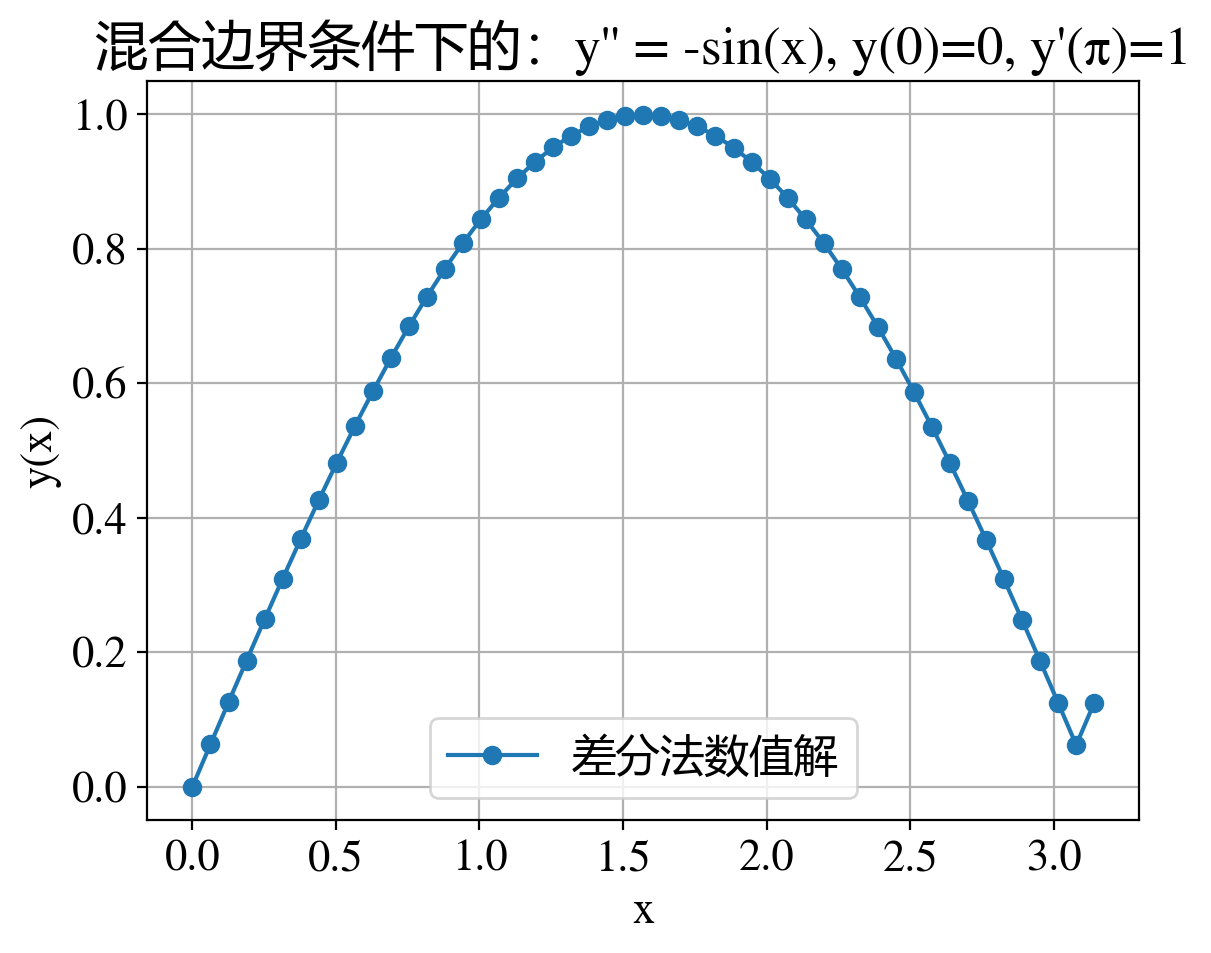

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# 区间与网格
a, b = 0, np.pi
N = 50
h = (b - a) / N

x = np.linspace(a, b, N+1)

# Dirichlet: y(0)=0
y0 = 0

# 构造 A y = b
A = np.zeros((N-1, N-1))
b_vec = np.zeros(N-1)

for i in range(1, N):
    xi = x[i]
    row = i - 1
    
    # 标准三对角形式
    A[row, row] = 2
    if i > 1:
        A[row, row-1] = -1
    if i < N-1:
        A[row, row+1] = -1
    
    # 右端项
    b_vec[row] = h**2 * np.sin(xi)

# 处理 Dirichlet 边界 y(0)=0 → 影响 i=1 的方程
# y_0 = 0 → (-1)*y_0 移到右端
b_vec[0] -= (-1)*y0

# 处理 Neumann 边界：y_N = y_{N-1} + h
# 在 i=N-1 的方程出现 -y_N
# 代入得到：-y_N = -(y_{N-1}+h)
# 其中 -y_{N-1} 合并入系数矩阵，-h 加入右端
b_vec[-1] -= h   # 加入 -(-h)

# 修改最后方程的系数（令 -y_{N} → -y_{N-1} - h）
A[-1, -1] = 1    # 原本是 2（来自 -y_{N-2}+2y_{N-1}-y_N），
                 # 代入 y_N=y_{N-1}+h 后变成 -y_{N-2}+y_{N-1}

# 求解线性系统
y_inner = np.linalg.solve(A, b_vec)

# 拼接完整解
y = np.zeros(N+1)
y[0] = y0
y[1:N] = y_inner
y[N] = y[N-1] + h   # Neumann 条件

# 绘图
plt.plot(x, y, 'o-', label="差分法数值解")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("混合边界条件下的：y'' = -sin(x), y(0)=0, y'(π)=1")
plt.grid(True)
plt.legend()
plt.show()

## 射击法（Shooting Method）求解常微分方程边值问题 BVP

射击法（Shooting Method）是一类将 **边值问题（BVP）转化为多个初值问题（IVP）** 的数值方法。

---

### 1. 问题背景

典型的二阶常微分方程边值问题形式为：

$$
y''(x) = f(x, y, y'), \qquad x \in [a,b]
$$

边界条件：

$$
y(a) = \alpha, \qquad y(b) = \beta.
$$

BVP 的难点：  
- **初始斜率 $y'(a)$ 未知**，不能直接用 Runge–Kutta 或 Euler。

射击法的核心思想是：

> **猜一个初始斜率，用 IVP 求到末端，看是否满足边界条件。如果不满足就调整斜率，直到命中目标。**

就像“开枪击中目标”，所以称为 *shooting*。

---

### 2. 射击法的基本思想

令未知初始斜率为：

$$
s = y'(a)
$$

对于任意 $s$，我们可以解初值问题：

$$
\begin{cases}
y'' = f(x,y,y'), \\
y(a)=\alpha, \\
y'(a)=s.
\end{cases}
$$

经过数值积分（比如 RK4），我们得到右端点的值：

$$
y(b; s)
$$

我们的目标是找到正确的 $s$，使得：

$$
y(b; s) = \beta.
$$

这就变成了一个 **求根问题**：

$$
F(s) = y(b; s) - \beta = 0.
$$

可以用：

- 二分法（Bisection）
- 割线法（Secant）
- Newton 法（若可计算导数）

来求解。

---

### 3. 射击法的步骤总结

1. **将 BVP 转为 IVP**, 设定：
   - $y(a)=\alpha$
   - 猜测初始斜率 $s$
2. **用 RK4（或其他 ODE solver）从 a 积分到 b**
3. **检查结果是否满足边界条件 $y(b)=\beta$**  
4. **调整斜率 $s$**，重复步骤 2–3  
5. 当误差足够小时停止。

---

### 4. 图形直观解释

若初始斜率猜低了 → 解曲线在右端点低于目标  
若初始斜率猜高了 → 解曲线在右端点高于目标  

不断调整初始斜率，就像调节枪口角度，直到击中目标点。

---

### 5. 例子：  
#### 求解方程：

$$
y'' = -y,\qquad y(0)=0,\qquad y(\pi/2)=1
$$

我们将未知斜率记为：

$$
s = y'(0)
$$

每次设定初值：

$$
y(0)=0, \quad y'(0)=s
$$

用 RK4 解到 $x=\pi/2$，计算：

$$
F(s) = y(\pi/2) - 1
$$

找到满足 $F(s)=0$ 的 $s$。

解析解为：

$$
y = \sin(x) \quad \Rightarrow \quad y'(0)=1.
$$

---

### 6. Python 示例代码模板

In [101]:

import numpy as np

# ODE: y'' = f(x,y,y')
def f(x, y, yp):
    return -y    # 示例

def rk4_step(x, y, yp, h):
    # 转成一阶系统：
    # y' = yp
    # yp' = f(x, y, yp)
    def g(x, Y):
        return np.array([Y[1], f(x, Y[0], Y[1])])

    Y = np.array([y, yp])

    k1 = g(x,         Y)
    k2 = g(x + h/2.0, Y + h*k1/2.0)
    k3 = g(x + h/2.0, Y + h*k2/2.0)
    k4 = g(x + h,     Y + h*k3)

    return Y + h*(k1 + 2*k2 + 2*k3 + k4)/6.0

def solve_ivp(s, N=200):
    a, b = 0, np.pi/2
    h = (b - a) / N
    x = a
    y, yp = 0, s      # 初值：y(a)=0, y'(a)=s

    for _ in range(N):
        y, yp = rk4_step(x, y, yp, h)
        x += h
    return y          # 返回 y(b; s)

def shooting():
    s0, s1 = 0.0, 2.0   # 两个猜测
    y0 = solve_ivp(s0)
    y1 = solve_ivp(s1)

    for _ in range(20):
        s2 = s1 - (y1 - 1) * (s1 - s0) / (y1 - y0)  # 割线法
        y2 = solve_ivp(s2)
        
        if abs(y2 - 1) < 1e-6:
            return s2
            
        s0, s1 = s1, s2
        y0, y1 = y1, y2

s_solution = shooting()
print("y'(0) =", s_solution)


y'(0) = 1.000000000000326


为使烟花从地面发射5秒后在距离地面上40米的高空爆炸，初始发射速度应为多大？（考虑空气阻力与速度成正比，阻力系数为$\alpha=0.01$）
$$
    y'' = -9.8 - 0.01 y'
$$
边界条件：
$$
    y(0) = 0, \quad  y(5) = 40
$$

In [103]:

a, b = 0, 5

# ODE: y'' = f(x,y,y')
def acc(t, pos, vel):
    return -9.8 - 0.001 * vel

def rk4_step(t, pos, vel, step):
    # 转成一阶系统：
    # y' = yp
    # yp' = f(x, y, yp)
    def g(x, pos, vel):
        return vel, acc(t, pos, vel)

    #Y = np.array([pos, vel])

    k1_vel, k1_acc = g(t,            pos,                   vel                  )
    k2_vel, k2_acc = g(t + step/2.0, pos + step*k1_vel/2.0, vel + step*k1_acc/2.0)
    k3_vel, k3_acc = g(t + step/2.0, pos + step*k2_vel/2.0, vel + step*k2_acc/2.0)
    k4_vel, k4_acc = g(t + step,     pos + step*k3_vel    , vel + step*k3_acc    )

    pos_new = pos + step*(k1_vel + 2*k2_vel + 2*k3_vel + k4_vel)/6.0
    vel_new = vel + step*(k1_acc + 2*k2_acc + 2*k3_acc + k4_acc)/6.0

    return pos_new, vel_new

def solve_ivp(v0, N=200):
    
    h = (b - a) / N
    t = a
    pos, vel = 0, v0      # 初值：y(a)=0, y(a)=s

    for _ in range(N):
        pos, vel = rk4_step(t, pos, vel, h)
        t += h
        
    return pos          # 返回 y(b; s)

def shooting():
    yN = 40 ## 终点的条件
    s0, s1 = 20.0, 40.0   # 两个猜测
    y0 = solve_ivp(s0)
    y1 = solve_ivp(s1)

    for _ in range(20):
        s2 = s1 - (y1 - yN) * (s1 - s0) / (y1 - y0)  # 割线法
        y2 = solve_ivp(s2)
        
        if abs(y2 - yN) < 1e-6:
            return s2
            
        s0, s1 = s1, s2
        y0, y1 = y1, y2

s_solution = shooting()
print("y'(0) =", s_solution)


y'(0) = 32.54043332481945


#### 课堂练习
打靶法求解
$$
y'' + y = \sqrt{t+1}
$$
边界条件$y(0)=1$, $y'(1)=3$


找到的初始斜率s=y'(0)=5.1814
验证：y'(1)=3.0000（目标是3）


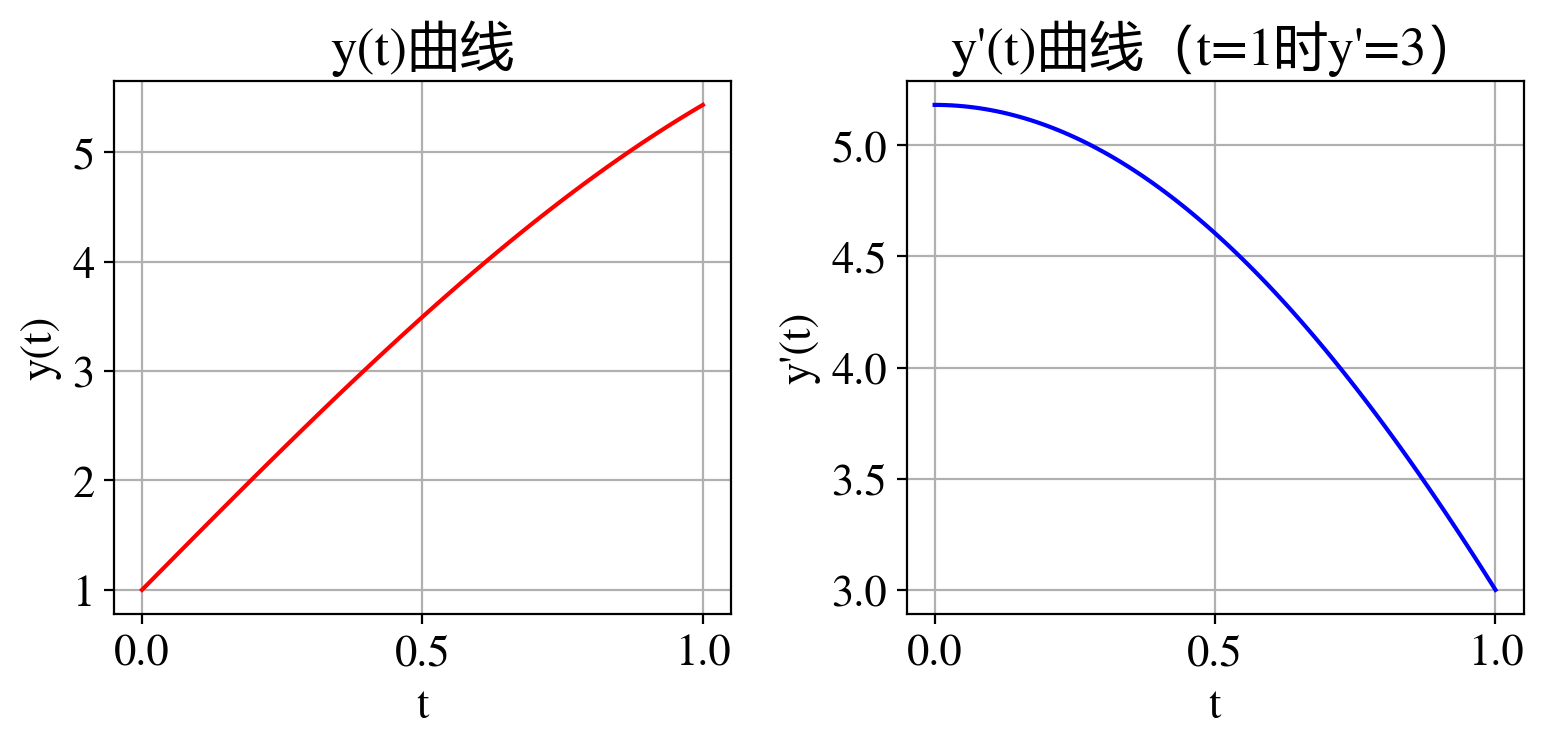

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# 第一步：将二阶ODE转一阶方程组
# 原方程：y'' = -y + sqrt(t+1)
# 定义：y1 = y, y2 = y' → 方程组：
# y1' = y2
# y2' = -y1 + sqrt(t+1)
def fun(t, Y):
    y1, y2 = Y
    return [y2, -y1 + np.sqrt(t+1)]

# 第二步：RK4求解初值问题（给定初始斜率s=y'(0)）
def solve_ivp_shooting(s, t0=0, T=1, h=0.01):
    """
    求解初值问题：y(0)=1, y'(0)=s，返回y(1)和y'(1)
    """
    N = int((T - t0)/h)
    t = np.zeros(N+1)
    y1 = np.zeros(N+1)  # y(t)
    y2 = np.zeros(N+1)  # y'(t)
    
    # 初值
    t[0] = t0
    y1[0] = 1.0  # y(0)=1
    y2[0] = s    # 猜测的初始斜率
    
    # RK4循环
    for n in range(N):
        t_n = t[n]
        y1_n = y1[n]
        y2_n = y2[n]
        
        # 计算k1-k4（向量形式）
        k1_1, k1_2 = fun(t_n, [y1_n, y2_n])
        k2_1, k2_2 = fun(t_n + h/2, [y1_n + h*k1_1/2, y2_n + h*k1_2/2])
        k3_1, k3_2 = fun(t_n + h/2, [y1_n + h*k2_1/2, y2_n + h*k2_2/2])
        k4_1, k4_2 = fun(t_n + h, [y1_n + h*k3_1, y2_n + h*k3_2])
        
        # 更新
        t[n+1] = t_n + h
        y1[n+1] = y1_n + h*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)/6
        y2[n+1] = y2_n + h*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)/6
    
    return y1[-1], y2[-1]  # 返回t=1时的y和y'

# 第三步：割线法找正确的初始斜率s
def shooting_method(target_yp=3, s0=2, s1=4, tol=1e-6, max_iter=20):
    """
    射击法：找到s使得y'(1)=3
    - target_yp: 目标y'(1)=3
    - s0, s1: 初始猜测的两个斜率
    """
    # 计算初始两个猜测的结果
    y1_0, yp_0 = solve_ivp_shooting(s0)
    y1_1, yp_1 = solve_ivp_shooting(s1)
    
    for _ in range(max_iter):
        # 割线法更新s
        s2 = s1 - (yp_1 - target_yp) * (s1 - s0)/(yp_1 - yp_0)
        y1_2, yp_2 = solve_ivp_shooting(s2)
        
        # 检查误差
        if abs(yp_2 - target_yp) < tol:
            return s2, y1_2, yp_2
        
        # 更新猜测值
        s0, s1 = s1, s2
        yp_0, yp_1 = yp_1, yp_2
    
    raise ValueError("迭代次数不足，未找到解")

# 第四步：执行射击法
s_sol, y1_sol, yp_sol = shooting_method()
print(f"找到的初始斜率s=y'(0)={s_sol:.4f}")
print(f"验证：y'(1)={yp_sol:.4f}（目标是3）")

# 第五步：绘制解曲线
h = 0.01
t0=0
T=1
N = int((T-t0)/h)
t = np.linspace(t0, T, N+1)
y1 = np.zeros(N+1)
y2 = np.zeros(N+1)
y1[0] = 1.0
y2[0] = s_sol

# 重新求解并存储所有点
for n in range(N):
    t_n = t[n]
    y1_n = y1[n]
    y2_n = y2[n]
    k1_1, k1_2 = fun(t_n, [y1_n, y2_n])
    k2_1, k2_2 = fun(t_n + h/2, [y1_n + h*k1_1/2, y2_n + h*k1_2/2])
    k3_1, k3_2 = fun(t_n + h/2, [y1_n + h*k2_1/2, y2_n + h*k2_2/2])
    k4_1, k4_2 = fun(t_n + h, [y1_n + h*k3_1, y2_n + h*k3_2])
    y1[n+1] = y1_n + h*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)/6
    y2[n+1] = y2_n + h*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)/6

# 绘图
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(t, y1, 'r-')
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("y(t)曲线")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, y2, 'b-')
plt.xlabel("t")
plt.ylabel("y'(t)")
plt.title("y'(t)曲线（t=1时y'=3）")
plt.grid(True)
plt.tight_layout()
plt.show()

## 本征值问题（Eigenvalue Problems）

本征值问题是在物理学中极为重要的问题，即在一定边界条件下求解满足一定本征值和对应的本征函数。例如量子力学中描述一维无限深势阱的薛定谔方程：

$$
\frac{d^2\phi}{dx^2} = -k^2 \phi, \qquad \phi(a) = \phi(b) = 0.
\tag{5.3.10}
$$

我们在区间 $$[a, b]$$ 使用中心差分格式将微分方程离散化。区间等分为 $$n+1$$ 段，网格点

$$
x_i = a + (i-1)h, \qquad h = \frac{b-a}{n+1},\qquad i=1,\dots,n.
$$

二阶导数使用中心差分：

$$
\phi''(x_i) \approx \frac{\phi_{i+1} - 2\phi_i + \phi_{i-1}}{h^2}.
$$

将其代入方程 (5.3.10)：

$$
\frac{\phi_{i+1} - 2\phi_i + \phi_{i-1}}{h^2}
= -k^2 \phi_i, \qquad i=2,\dots,n.
$$

整理得到差分方程：

$$
-\phi_{i-1} + 2\phi_i - \phi_{i+1} = k^2 h^2 \phi_i.
$$

利用边界条件 $$\phi_0 = \phi_{n+1} = 0$$，并令本征值

$$
\lambda = k^2,
$$

即可得到如下矩阵本征值问题：

$$
\frac{1}{h^2}
\begin{pmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \ddots & 0 \\
\vdots & \vdots & \ddots & \ddots & -1 \\
0 & 0 & 0 & -1 & 2
\end{pmatrix}
\begin{pmatrix}
\phi_1 \\ \phi_2 \\ \vdots \\ \phi_{n-1} \\ \phi_n
\end{pmatrix} =
\lambda
\begin{pmatrix}
\phi_1 \\ \phi_2 \\ \vdots \\ \phi_{n-1} \\ \phi_n
\end{pmatrix}.
$$

矩阵中的 $$\lambda=k^2$$ 为本征值，向量

$$
\phi = (\phi_1, \phi_2, \dots, \phi_n)^T
$$

为离散的本征函数。


前 5 个本征值 λₙ = kₙ² 为：
n=1, λ = 9.830236, k = 3.135321
n=2, λ = 39.320848, k = 6.270634
n=3, λ = 88.471545, k = 9.405931
n=4, λ = 157.281844, k = 12.541206
n=5, λ = 245.751070, k = 15.676450


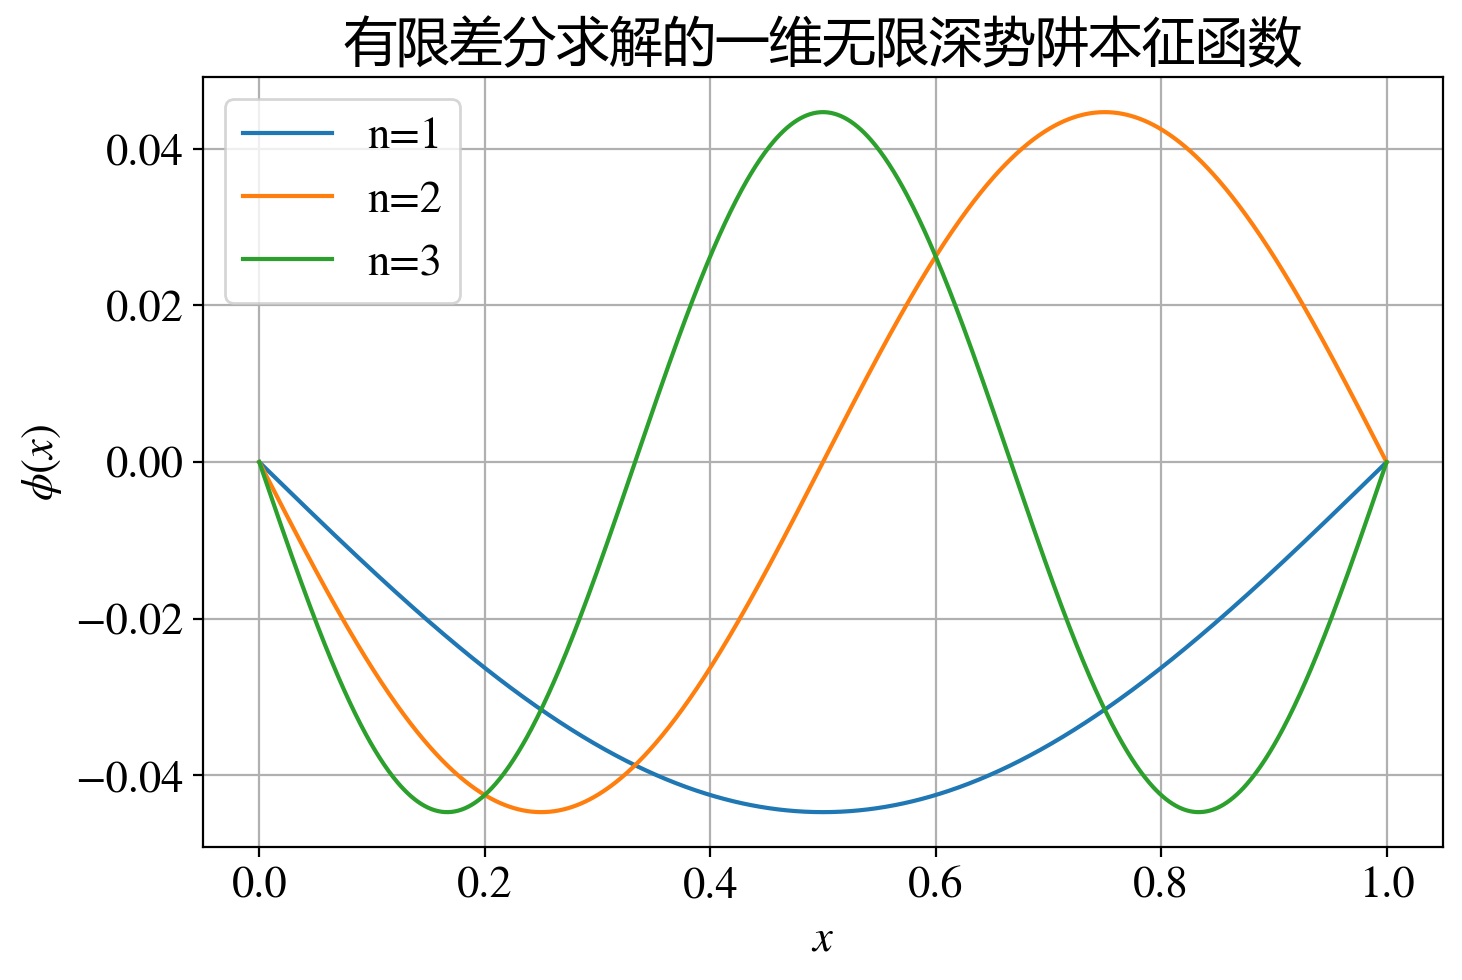

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# 区间 [a, b]，无限深势阱典型为 [0, 1]
a, b = 0, 1

# 网格数（内部点数）
n = 1001
x = np.linspace(a, b, n)
h = x[1] - x[0]

# 构造三对角矩阵 A
diag = 2 * np.ones(n)
off  = -1 * np.ones(n-1)

A = (np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)) / h**2

# 求本征值与本征向量
eigvals, eigvecs = np.linalg.eig(A)

# 对本征值排序
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("前 5 个本征值 λₙ = kₙ² 为：")
for i in range(5):
    print(f"n={i+1}, λ = {eigvals[i]:.6f}, k = {np.sqrt(eigvals[i]):.6f}")

# 绘制前几个本征函数
x = np.linspace(a, b, n+2)
plt.figure(figsize=(8,5))

for i in range(3):
    phi = np.zeros(n+2)
    phi[1:-1] = eigvecs[:,i]   # 插入边界 φ(0)=φ(1)=0
    plt.plot(x, phi, label=f"n={i+1}")

plt.title("有限差分求解的一维无限深势阱本征函数")
plt.xlabel(r"$x$")
plt.ylabel(r"$\phi (x)$")
plt.grid(True)
plt.legend()
plt.show()


## Python 中常用的 ODE 数值求解函数 `solve_ivp`
用于求解一阶系统：

# SciPy 中 solve_ivp 的常用参数详解

`solve_ivp` 是 SciPy 中最推荐使用的常微分方程求解函数，功能强大且接口清晰。

其函数原型为：
```python
solve_ivp(fun, t_span, y0, method='RK45', t_eval=None,
          dense_output=False, events=None, 
          rtol=1e-3, atol=1e-6, args=None, **options)
```
1. `fun`: 微分方程函数
$$
\frac{dy}{dt} = f(t, y)
$$
变量 $y$ 可以是标量，也可以是向量对应多变量系统/二阶微分方程。

---

2. `t_span`: 时间积分区间
```python
t_span = [t0, tf]
```
例如：
```python
t_span = [0, 10]
```
即从 $t=0$ 积分到 $t=10$。

---

3. `y0`: 初值

初值维度应与 ODE 系统一致：
```python
y0 = [1.0]        # 一阶方程
y0 = [0.0, 1.0]   # 二阶方程改写为一阶系统
```

---
4. `method`: 数值求解方法

支持多种算法（RK45、RK23、Radau、BDF、LSODA 等）。

| method  | 类型             | 特点                |
| ------- | -------------- | ----------------- |
| `RK45`  | 显式 Runge–Kutta | 默认算法，适合大多数非刚性 ODE |
| `RK23`  | 更低阶 RK         | 对误差更敏感问题          |
| `Radau` | 隐式             | 适合刚性 ODE          |
| `BDF`   | 向后差分           | 刚性问题专用            |
| `LSODA` | 自动切换刚性/非刚性     | 稳定可靠              |

---

5. `t_eval`: 指定输出点

若希望求解器在固定时间网格上输出结果（如绘图）：

```python
t_eval = np.linspace(0, 5, 200)
solve_ivp(fun, [0, 5], y0, t_eval=t_eval)
```

否则默认只返回自适应步长的节点。

---

6. `dense_output`: 连续解输出

当设为 `True` 时，求解器返回可插值的连续解：

```python
sol = solve_ivp(fun, [0,5], y0, dense_output=True)
y_at_23 = sol.sol(2.3)   # 在任意时间点求解
```

适用于事件定位、后处理等任务。

---

7. `events`: 事件检测

事件函数满足条件
$$
\text{event}(t, y) = 0.
$$

示例：检测 $y(t)=0$ （如物体落地）

```python
def hit_ground(t, y):
    return y[0]

hit_ground.terminal = True     # 触发事件后停止积分
hit_ground.direction = -1      # 仅检测从正到负穿越
```

使用方式：

```python
sol = solve_ivp(fun, [0,10], y0, events=hit_ground)
```

---

8. 精度控制：`rtol` 与 `atol`

误差控制公式为：

$$
|y_{\text{num}} - y_{\text{exact}}|
\le \text{atol} + \text{rtol} \cdot |y|.
$$

默认值：

$$
\text{rtol} = 10^{-3}, \qquad \text{atol} = 10^{-6}.
$$

高精度示例：

```python
solve_ivp(fun, [0,5], y0, rtol=1e-8, atol=1e-10)
```

---

9. `args`: 传递额外参数

示例：

```python
def fun(t, y, a, b):
    return a*y + b

solve_ivp(fun, [0,5], y0, args=(2.0, -1.0))
```

| 参数             | 作用           |
| -------------- | ------------ |
| `fun`          | 定义 ODE       |
| `t_span`       | 积分区间         |
| `y0`           | 初值           |
| `method`       | 数值算法         |
| `t_eval`       | 希望输出的时间点     |
| `dense_output` | 返回可插值解       |
| `events`       | 事件检测（撞击、越界等） |
| `rtol, atol`   | 精度控制         |
| `vectorized`   | 启用向量化计算      |
| `args`         | 传递额外参数       |


### 示例求解 
$$
y' = -2y
$$

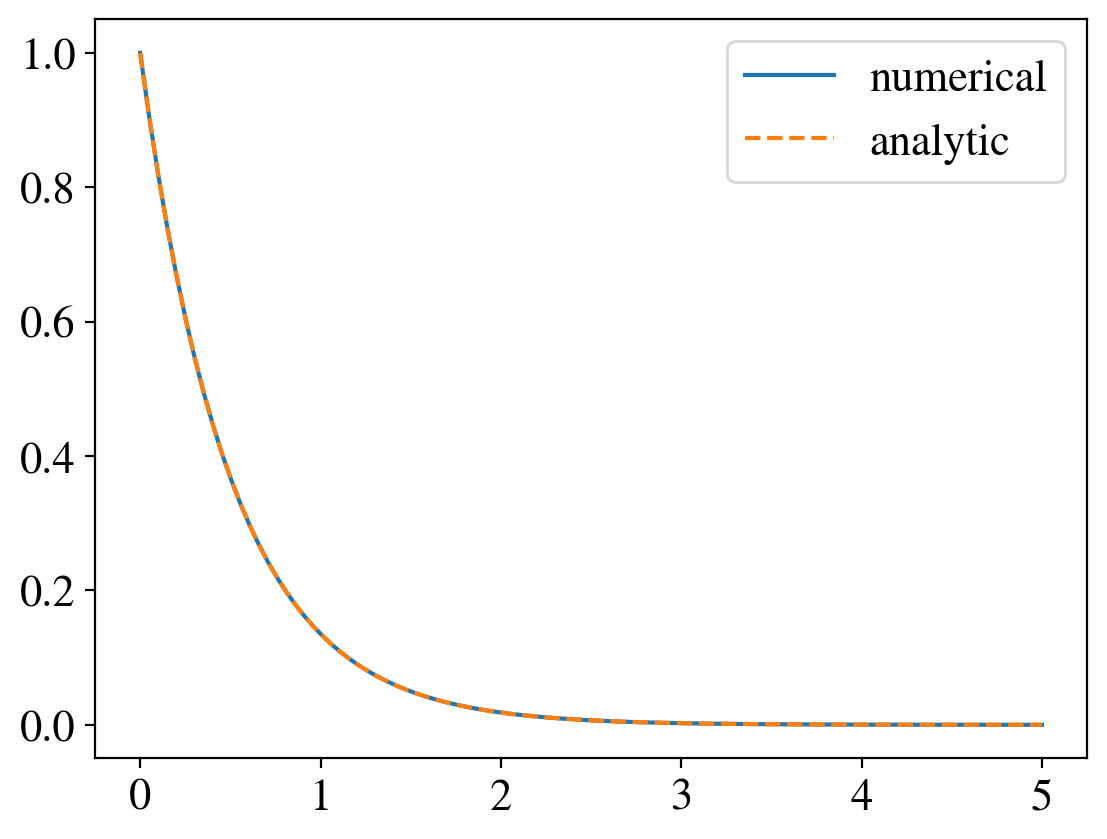

In [109]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# y' = -2y
def f(t, y):
    return -2*y

t_eval = np.linspace(0, 5, 100)

sol = solve_ivp(
    f,
    [0, 5],
    [1.0],
    method="RK45",
    t_eval=t_eval,
    rtol=1e-7,
    atol=1e-9,
    dense_output=True
)

plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(t_eval, np.exp(-2*t_eval), "--", label="analytic")
plt.legend()
plt.show()


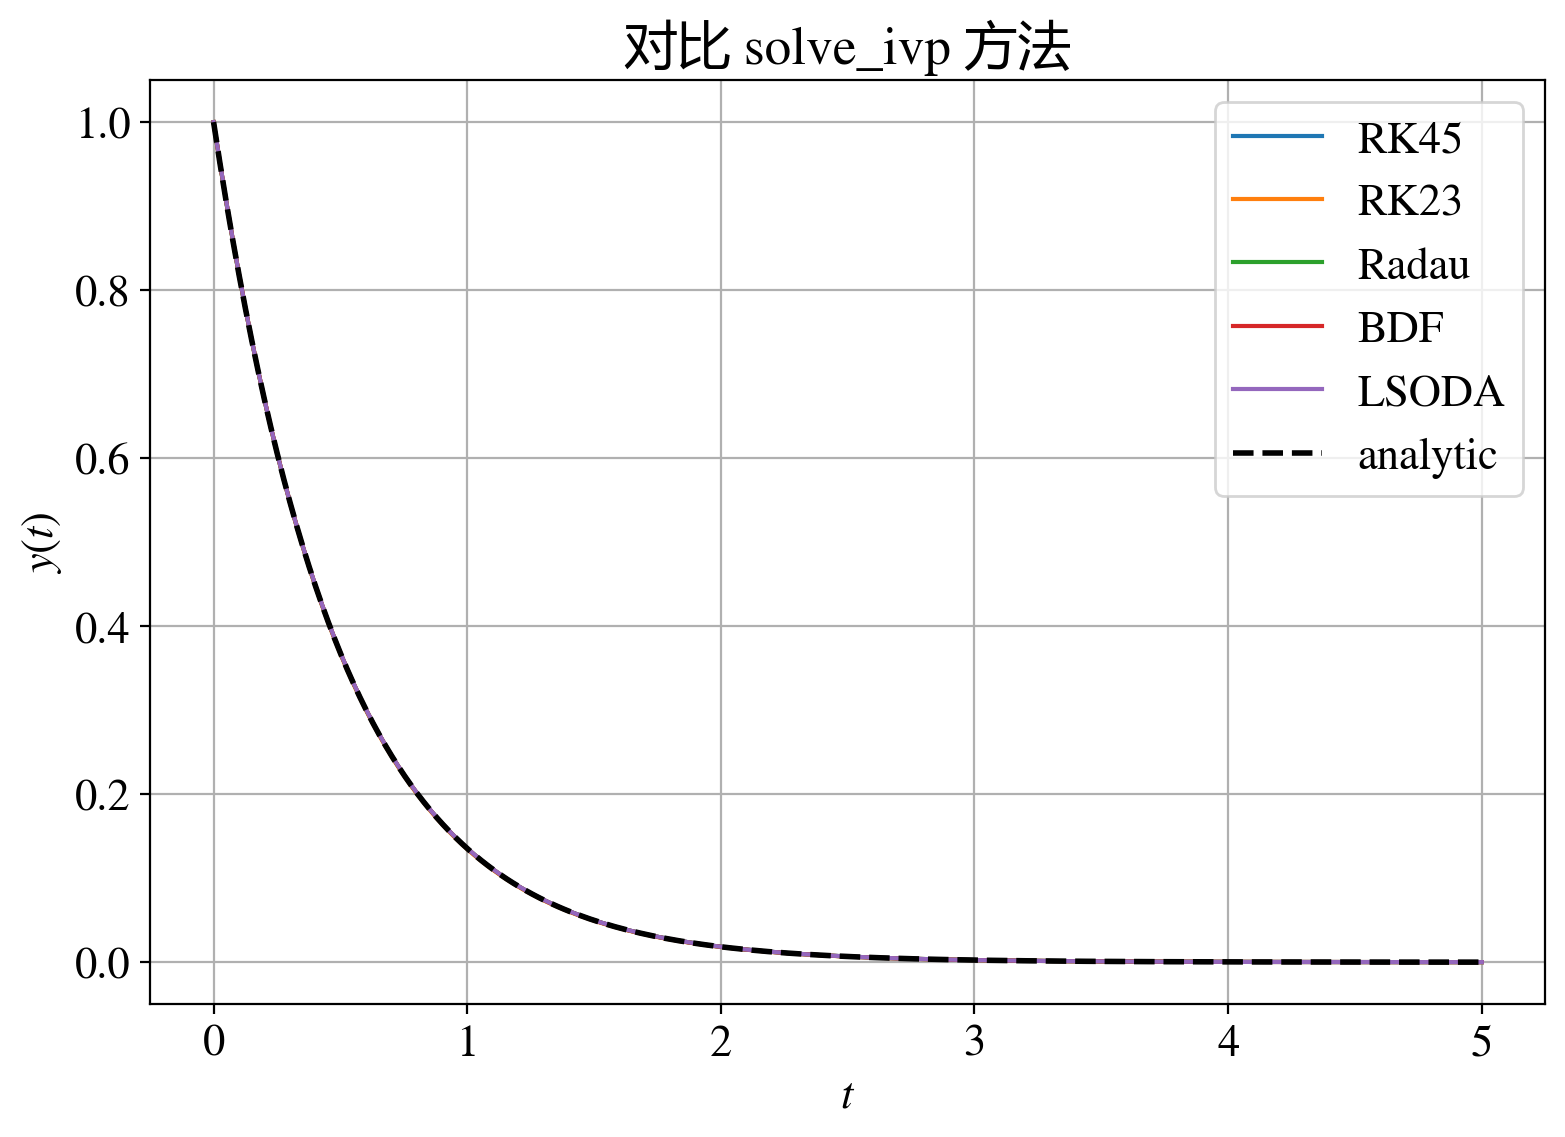

In [110]:
import matplotlib.pyplot as plt

t_eval = np.linspace(0, 5, 200)
methods = ["RK45", "RK23", "Radau", "BDF", "LSODA"]
solutions = {}

for m in methods:
    sol = solve_ivp(f, [0, 5], [1.0], method=m, t_eval=t_eval)
    solutions[m] = sol.y[0]

plt.figure(figsize=(9,6))

for m in methods:
    plt.plot(t_eval, solutions[m], label=m)

plt.plot(t_eval, np.exp(-2*t_eval), 'k--', label="analytic", linewidth=2)

plt.legend()
plt.xlabel("$t$")
plt.ylabel("$y(t)$")
plt.title("对比 solve_ivp 方法")
plt.grid(True)
plt.show()


## 用 solve_ivp 求解二阶常微分方程示例

本例演示如何将二阶微分方程转化为一阶系统，并使用 `solve_ivp` 求解。

---

### 1. 二阶微分方程

考虑阻尼谐振子的二阶 ODE：

$$
y'' + 0.2 y' + y = 0,
$$

初始条件：

$$
y(0)=1, \qquad y'(0)=0.
$$

---

### 2. 将二阶方程转换为一阶系统

引入变量：

$$
y_1 = y, \qquad y_2 = y'.
$$

则系统变为：

$$
\begin{cases}
y_1' = y_2,\\
y_2' = -0.2 y_2 - y_1.
\end{cases}
$$

用向量形式写为：

$$
\mathbf{y}'(t) = 
\begin{pmatrix}
y_1' \\ y_2'
\end{pmatrix} =
\begin{pmatrix}
y_2 \\ -0.2 y_2 - y_1
\end{pmatrix}.
$$

初值向量为：

$$
\mathbf{y}(0) =
\begin{pmatrix}
1 \\ 0
\end{pmatrix}.
$$

---

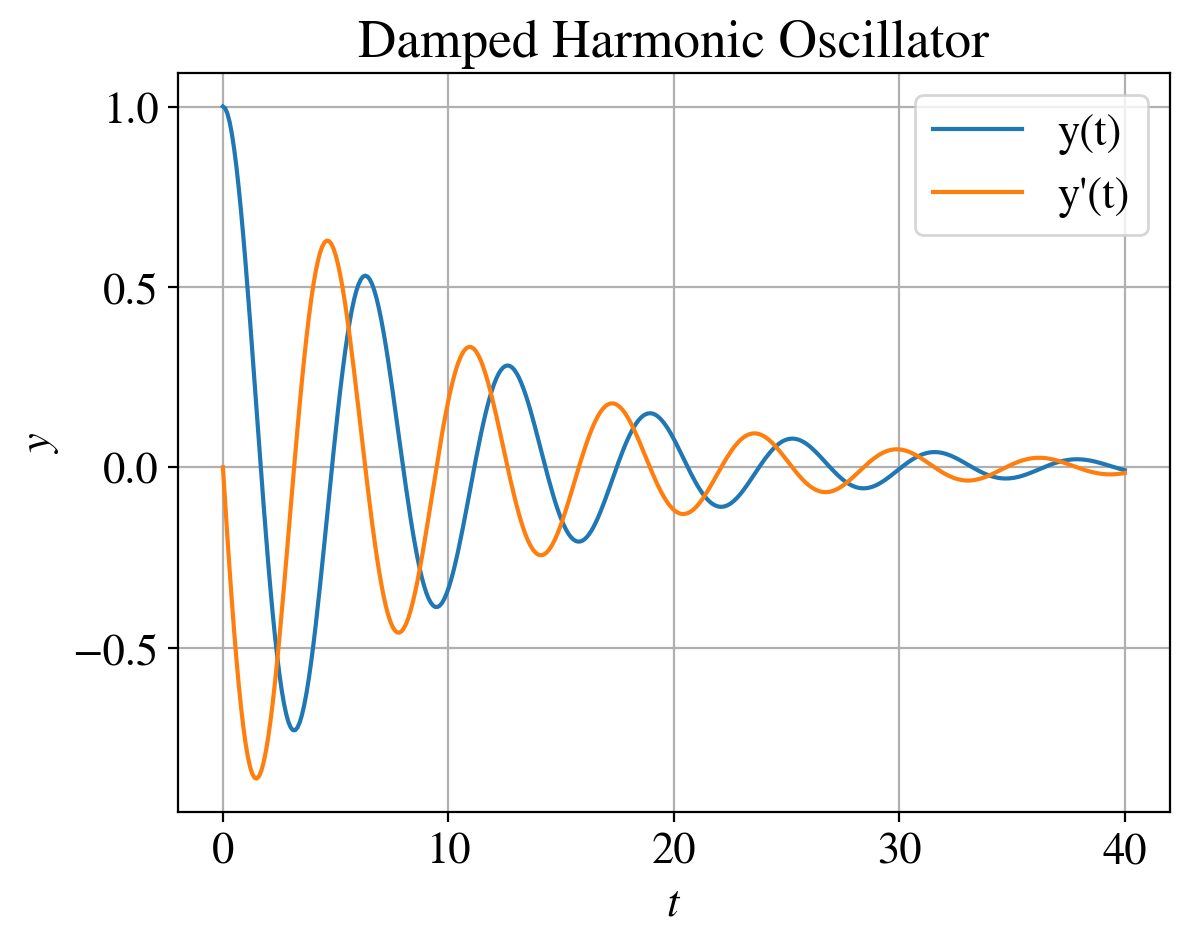

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 二阶微分方程 y'' + 0.2 y' + y = 0
# 转换成一阶系统：
# y1' = y2
# y2' = -0.2*y2 - y1

def fun(t, Y):
    y1, y2 = Y
    return [y2, -0.2*y2 - y1]

# 时间区间
t_span = [0, 40]
t_eval = np.linspace(0, 40, 400)

# 初值 y(0)=1, y'(0)=0
y0 = [1, 0]

# 求解微分方程
sol = solve_ivp(fun, t_span, y0, t_eval=t_eval, method="RK45")

# 绘制结果
plt.plot(sol.t, sol.y[0], label="y(t)")
plt.plot(sol.t, sol.y[1], label="y'(t)")
plt.xlabel(r"$t$")
plt.ylabel(r"$y$")
plt.title("Damped Harmonic Oscillator")
plt.grid(True)
plt.legend()
plt.show()

## `solve_bvp` 解边值问题

`scipy.integrate.solve_bvp` 用于求解**常微分方程边值问题（BVP）**，与 `solve_ivp` 求解初值问题不同。

---

### 📌 一、问题形式

`solve_bvp` 求解的微分方程一般形如：

$$
y'(x) = f(x, y), \quad x \in [a, b],
$$

边值条件为：

$$
g(y(a), y(b)) = 0.
$$

---

### 📌 二、函数结构

`solve_bvp(fun, bc, x, y, p=None, S=None, max_nodes=100000, tol=1e-3)`

常用参数：

- `fun(x, y)`：微分方程，返回 $y'$  
- `bc(ya, yb)`：边界条件函数  
- `x`：初始网格  
- `y`：初始猜测的解，形状为 `(n_equations, x.size)`  
- 返回 `sol` 对象，可通过 `sol(x_eval)` 插值求值

```python
def bc(ya, yb):
    return np.array([...])
```
- `ya` 是 $y$ 在左边界的值，例如 `ya[0] = y(a)`，`ya[1] = y'(a)`
- `yb` 是 $y$ 在右边界的值, 例如 `yb[0] = y(b)`，`yb[1] = y'(b)`
---

### 📌 三、示例：求解二阶常微分方程  

求解边值问题：

$$
y''(x) = -\pi^2 y(x), \qquad x\in[0,1],
$$

边界条件：

$$
y(0)=0,\qquad y(1)=0.
$$

其解析解为：

$$
y(x)=C \sin(\pi x).
$$

---

### 📌 四、转为一阶系统

令：

$$
y_1 = y, \qquad y_2 = y',
$$

则：

$$
\begin{aligned}
y_1' &= y_2, \\
y_2' &= -\pi^2 y_1.
\end{aligned}
$$

---

### 📌 五、Python 代码

Success = True


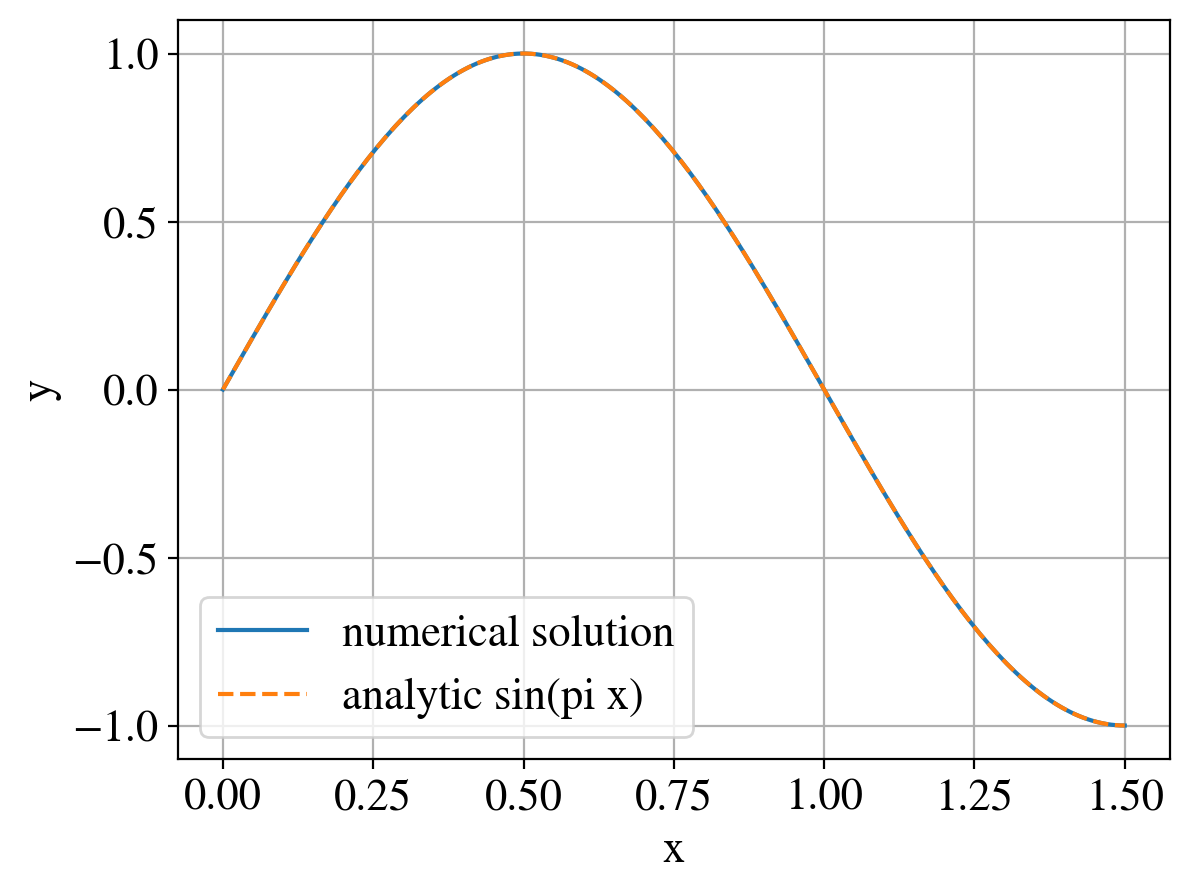

In [114]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# ----------------------------
# 1. 定义微分方程 y' = f(x,y)
# ----------------------------
def fun(t, y):
    return np.vstack((y[1], -np.pi**2 * y[0]))

# ----------------------------
# 2. 定义边界条件
#    y(0)=0, y(1.5)=-1
# ----------------------------
def bc(ya, yb):
    return np.array([ya[0], 
                     yb[0] + 1 ])

# ----------------------------
# 3. 创建初始网格与解的猜测
# ----------------------------
t = np.linspace(0, 1.5, 10)
y = np.ones((2, t.size))   # 初始猜测（全 0）

# ----------------------------
# 4. 求解 BVP
# ----------------------------
sol = solve_bvp(fun, bc, t, y)

# 检查是否成功
print("Success =", sol.success)

# ----------------------------
# 5. 插值与绘图
# ----------------------------
x_new = np.linspace(0, 1.5, 200)
y_new = sol.sol(x_new)[0]

plt.plot(x_new, y_new, label="numerical solution")
plt.plot(x_new, np.sin(np.pi * x_new), '--', label="analytic sin(pi x)")
plt.legend()
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Success = True
Message = The algorithm converged to the desired accuracy.


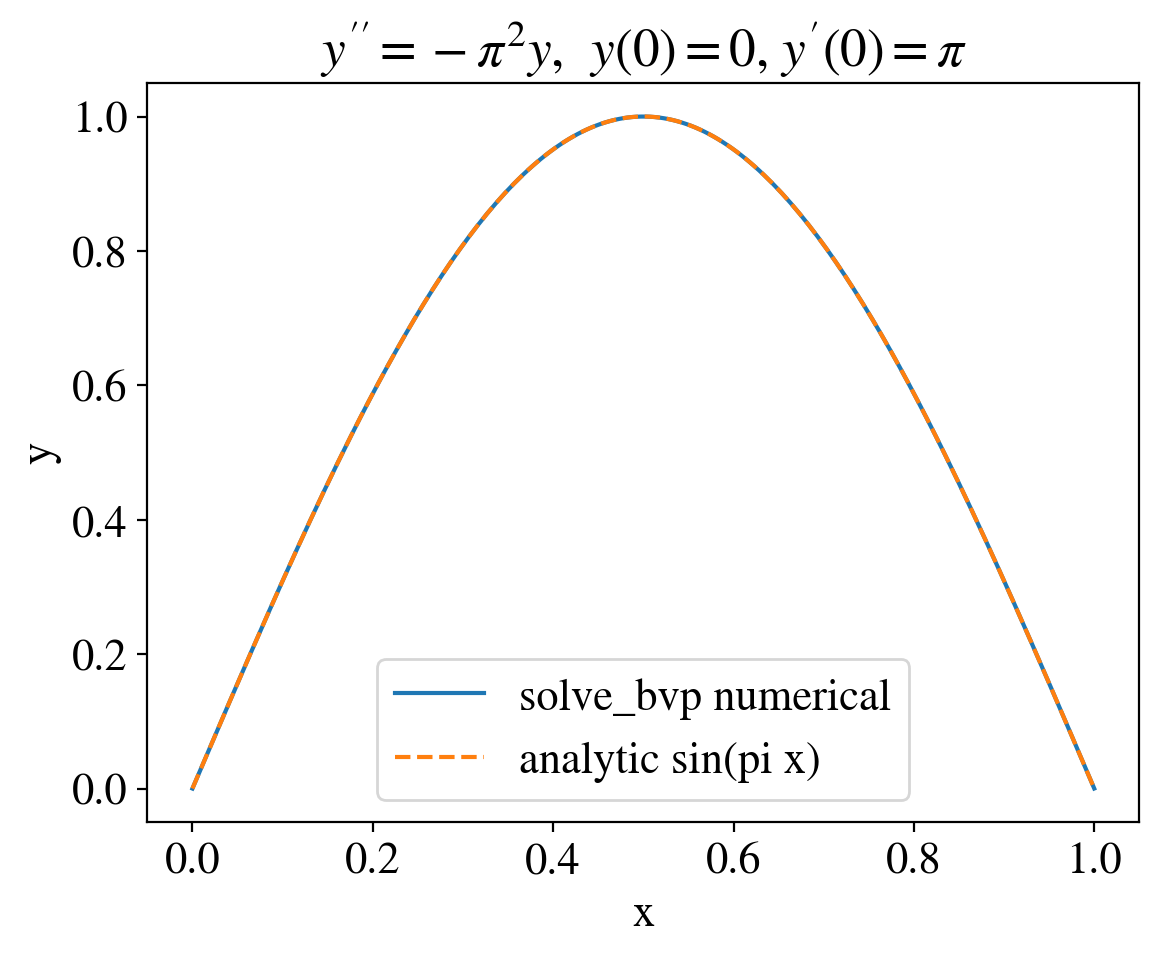

In [115]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# --------------------------------
# 1. 定义微分方程 y' = f(x, y)
#    y1 = y, y2 = y'
#    y1' = y2
#    y2' = -pi^2 * y1
# --------------------------------
def fun(x, y):
    return np.vstack((y[1], -np.pi**2 * y[0]))

# --------------------------------
# 2. 定义边界条件
#    y(0) = 0  → ya[0] = 0
#    y'(0) = pi → ya[1] = pi
# --------------------------------
def bc(ya, yb):
    return np.array([
        ya[0],        # y(0) = 0
        ya[1] - np.pi # y'(0) = pi
    ])

# --------------------------------
# 3. 初始网格 & 初始猜测
# --------------------------------
x = np.linspace(0, 1, 10)
# 初始猜测不要全 0，给一点非零形状会更稳
y_guess = np.zeros((2, x.size))
y_guess[0] = np.sin(np.pi * x)      # 猜测 y
y_guess[1] = np.pi * np.cos(np.pi * x)  # 猜测 y'

# --------------------------------
# 4. 求解 BVP
# --------------------------------
sol = solve_bvp(fun, bc, x, y_guess)

print("Success =", sol.success)
print("Message =", sol.message)

# --------------------------------
# 5. 插值与绘图（注意用 sol.sol）
# --------------------------------
x_new = np.linspace(0, 1, 200)
y_new = sol.sol(x_new)[0]

plt.plot(x_new, y_new, label="solve_bvp numerical")
plt.plot(x_new, np.sin(np.pi * x_new), '--', label="analytic sin(pi x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$y'' = -\pi^2 y$,  $y(0)=0$, $y'(0)= \pi$")
plt.show()


## 课堂练习：把刚才的烟花题目改造成用 `solve_bvp` 求解

为了使烟花从地面发射5秒后在距离地面上40米的高空爆炸，初始发射速度应为多大？（考虑空气阻力与速度成正比，阻力系数为$\alpha=0.01$）
$$
    y'' = -9.8 - 0.01 y'
$$
边界条件：
$$
    y(0) = 0, \quad  y(5) = 40
$$


初始发射速度：32.91 米/秒


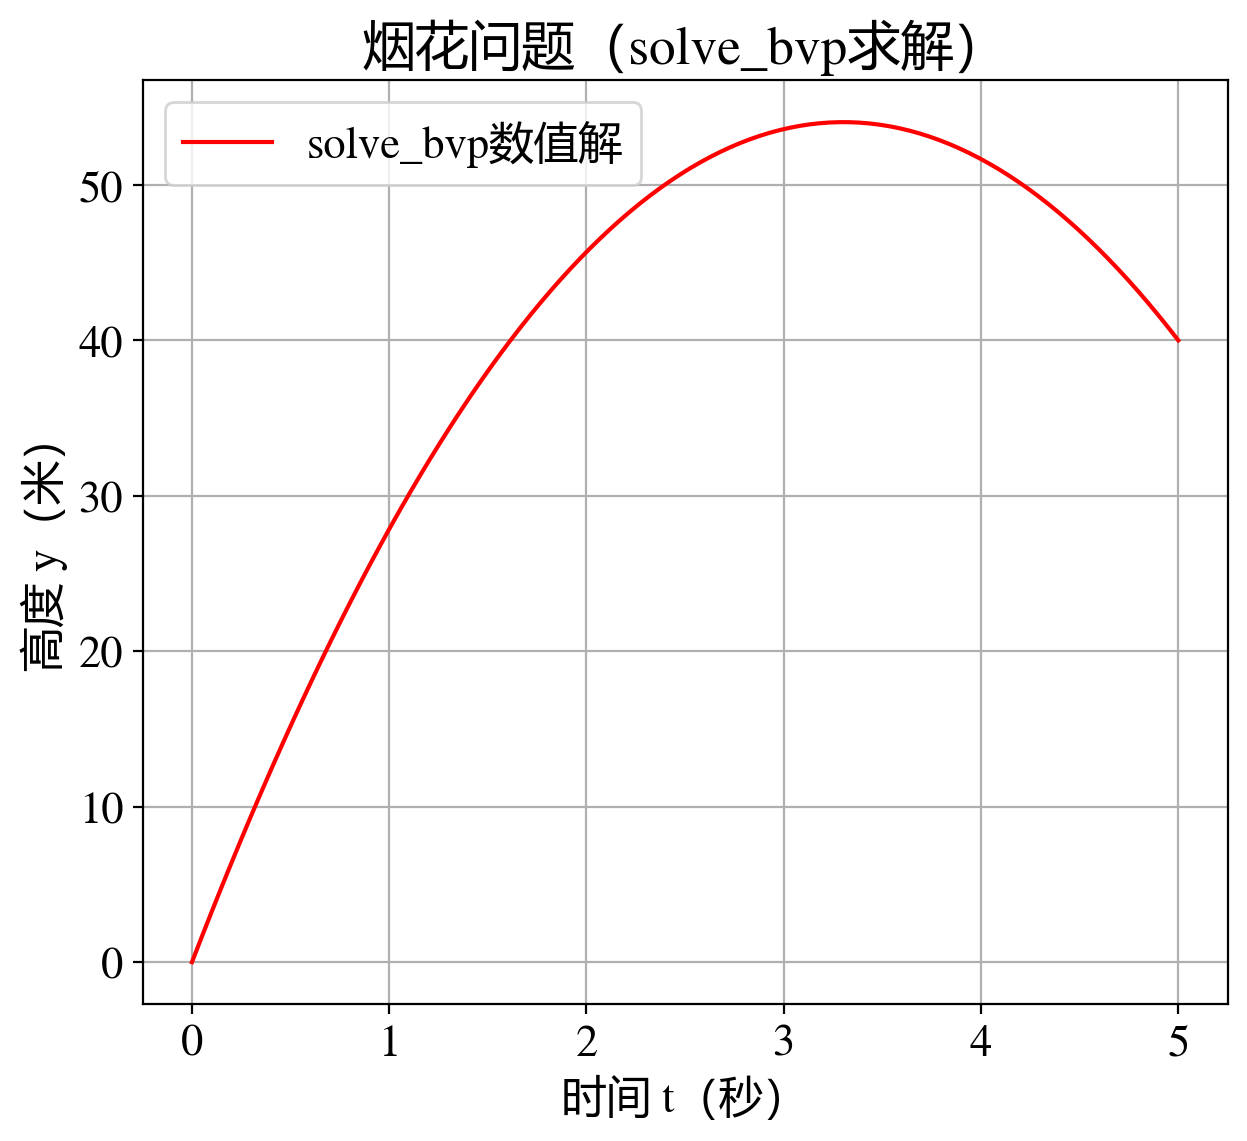

In [117]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# 第一步：将二阶ODE转一阶方程组
# 原方程：y'' = -9.8 - 0.01y'
# 定义Y = [y, y'] → Y' = [y', -9.8 - 0.01y']
def fun(x, Y):
    y, yp = Y  # Y[0]=y, Y[1]=y'
    return np.vstack((yp, -9.8 - 0.01*yp))

# 第二步：定义边界条件
# 边界条件：y(0)=0, y(5)=40
def bc(Ya, Yb):
    # Ya: 左边界（x=0）的Y值；Yb: 右边界（x=5）的Y值
    return np.array([Ya[0] - 0,  # y(0)=0
                     Yb[0] - 40]) # y(5)=40

# 第三步：初始网格和初始猜测
x = np.linspace(0, 5, 10)  # 初始网格（10个点）
y_guess = np.ones((2, x.size))  # 初始猜测（Y=[1,1]）
y_guess[0] = 8*x  # 更合理的初始猜测（线性增长）

# 第四步：求解BVP
sol = solve_bvp(fun, bc, x, y_guess)

# 第五步：插值并绘图
x_new = np.linspace(0, 5, 100)  # 更密的网格
y_new = sol.sol(x_new)[0]       # y(t)
yp_new = sol.sol(x_new)[1]      # y'(t)

# 输出初始速度
v0 = yp_new[0]
print(f"初始发射速度：{v0:.2f} 米/秒")

# 绘图
plt.figure(figsize=(7, 6))
plt.plot(x_new, y_new, 'r-', label="solve_bvp数值解")
plt.xlabel("时间 t（秒）")
plt.ylabel("高度 y（米）")
plt.title("烟花问题（solve_bvp求解）")
plt.grid(True)
plt.legend()
plt.show()

# 课后作业：

1. 采用欧拉方法求初值问题
$$
\begin{cases}
y' = y - 2x/y, \quad 0 < x < 1, \\
y(0) = 1.
\end{cases}
$$


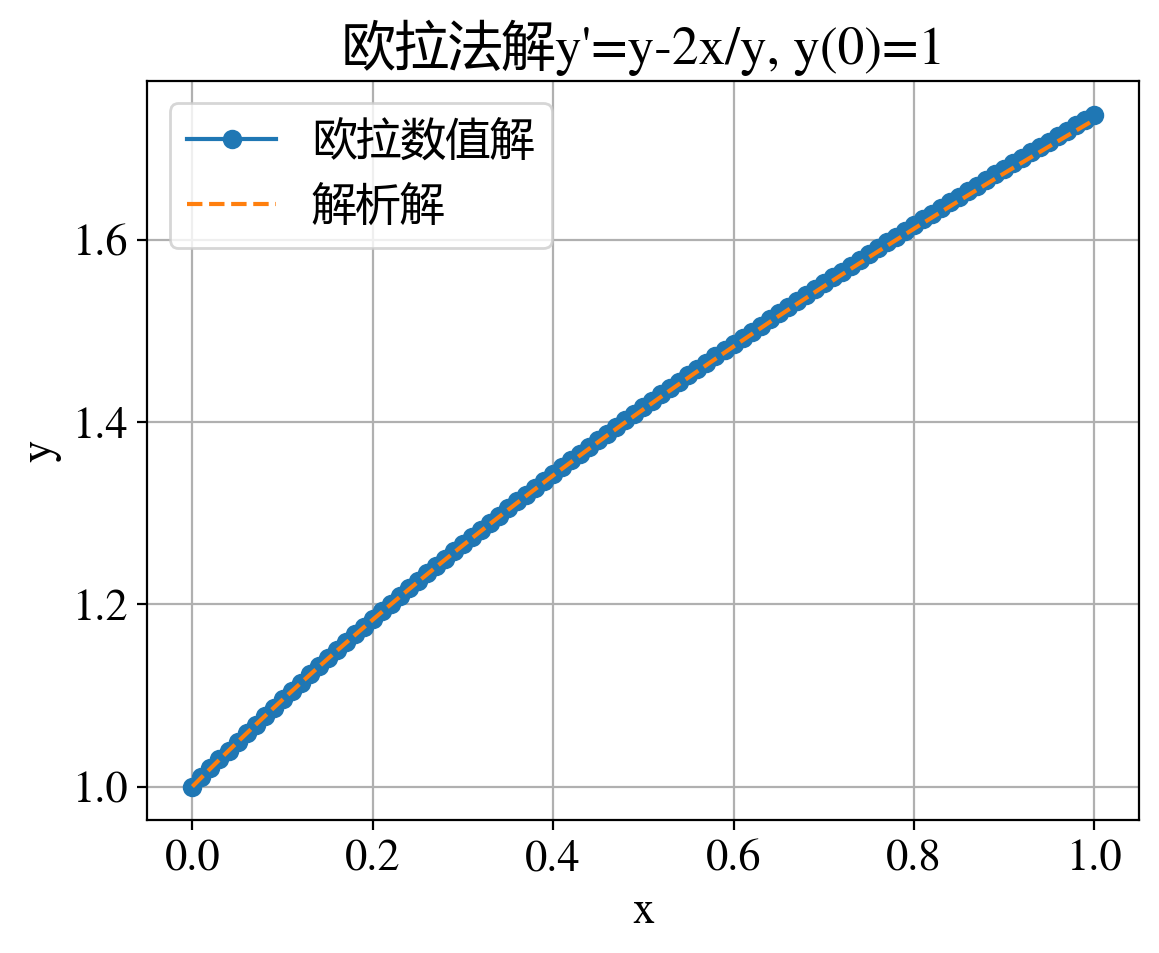

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# 定义微分方程
def f(t, y):
    return y - 2*t/y

# 欧拉求解器
def Euler_solver(func, t0, y0, T, h):
    N = int((T - t0)/h)
    t = np.zeros(N+1)
    y = np.zeros(N+1)
    t[0] = t0
    y[0] = y0
    for n in range(N):
        t[n+1] = t[n] + h
        y[n+1] = y[n] + h * func(t[n], y[n])
    return t, y

# 设置参数
t0 = 0.0
y0 = 1.0
T = 1.0
h = 0.01

# 求解
t, y = Euler_solver(f, t0, y0, T, h)

# 解析解（y=√(1+2x)）
y_exact = np.sqrt(1 + 2*t)

# 绘图
plt.plot(t, y, 'o-', label='欧拉数值解')
plt.plot(t, y_exact, '--', label='解析解')
plt.xlabel('x')
plt.ylabel('y')
plt.title('欧拉法解y\'=y-2x/y, y(0)=1')
plt.grid(True)
plt.legend()
plt.show()


2. 采用 RK4 编程求解下列常微分方程初值问题：
   $$
   \begin{cases}
   y' = 1 + y^2 + x^3, \\
   y(0) = 0.
   \end{cases}
   $$



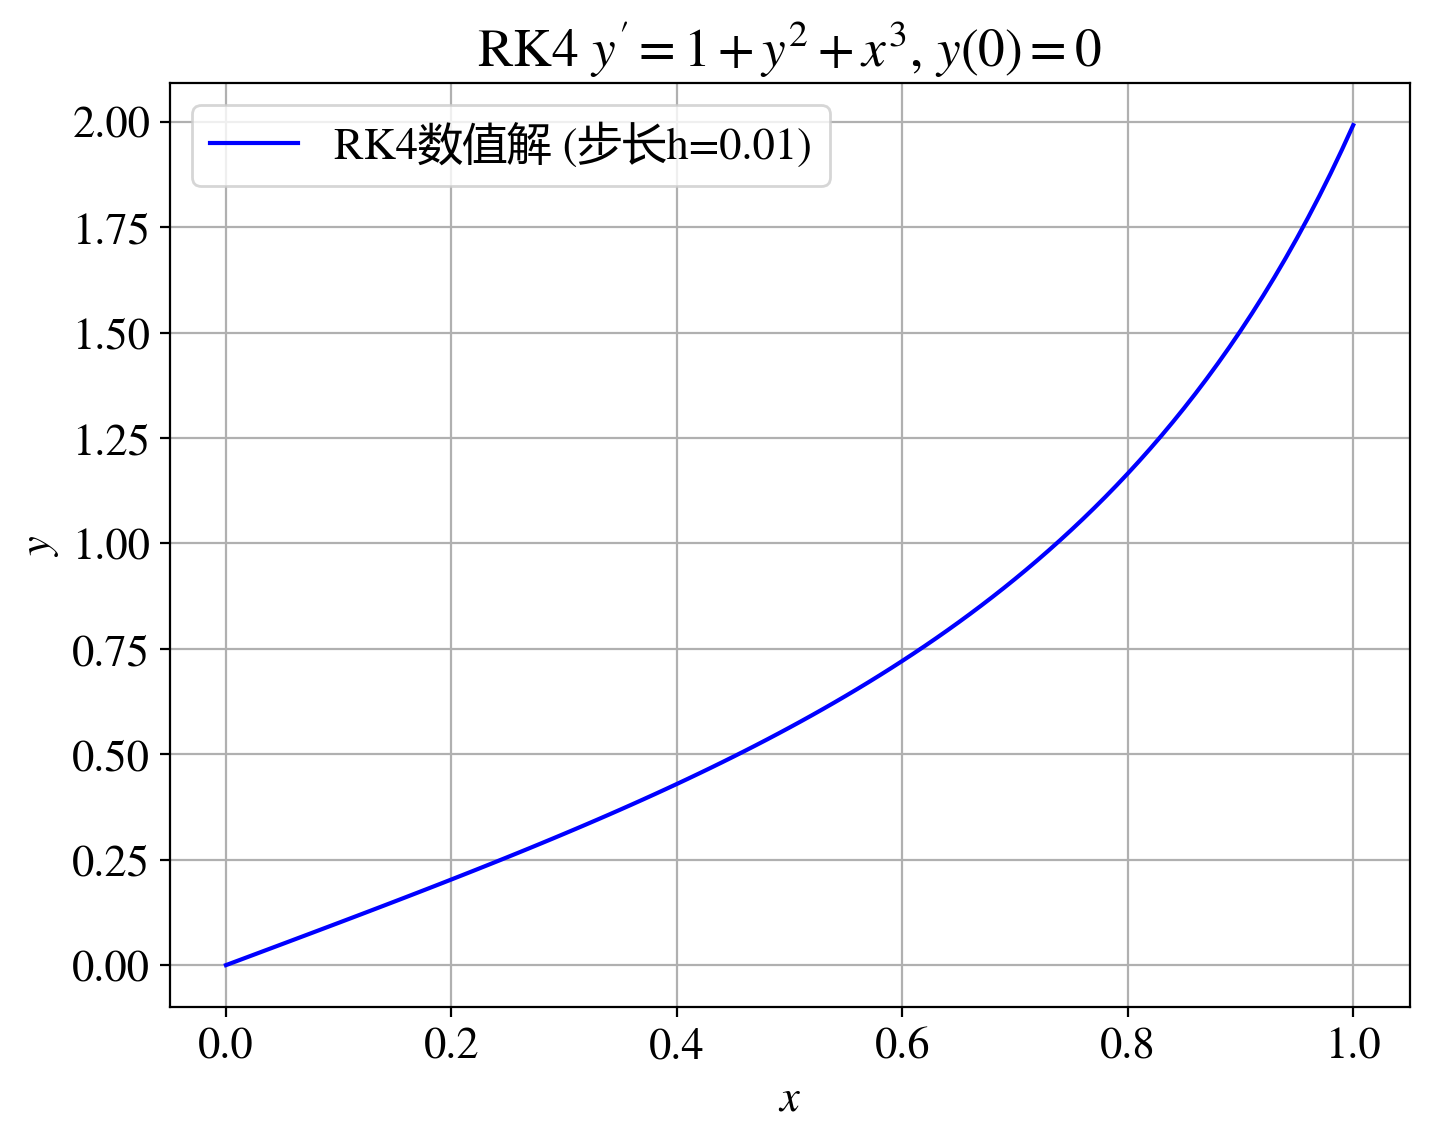

部分求解结果：
x = 0.00, y = 0.000000
x = 0.10, y = 0.100360
x = 0.20, y = 0.203115
x = 0.30, y = 0.311425
x = 0.40, y = 0.429566
x = 0.50, y = 0.563432
x = 0.60, y = 0.721369
x = 0.70, y = 0.915704
x = 0.80, y = 1.165719
x = 0.90, y = 1.504011
x = 1.00, y = 1.991792


In [137]:
import numpy as np
import matplotlib.pyplot as plt

# 定义微分方程的右端函数 f(x, y) = 1 + y² + x³
def f(x, y):
    return 1 + y**2 + x**3

# 定义RK4单步计算函数
def rk4_step(func, x, y, h):
    """
    单步RK4计算
    参数：
    func: 微分方程右端函数 f(x,y)
    x: 当前x值
    y: 当前y值
    h: 步长
    返回：
    下一步的y值
    """
    k1 = func(x, y)
    k2 = func(x + h/2, y + h*k1/2)
    k3 = func(x + h/2, y + h*k2/2)
    k4 = func(x + h,   y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# 定义RK4求解器（批量求解区间内所有点）
def RK4_solver(func, x0, y0, X, h):
    """
    RK4求解一阶常微分方程初值问题
    参数：
    func: 微分方程右端函数 f(x,y)
    x0: 初始x值
    y0: 初始y值
    X: 终止x值
    h: 步长
    返回：
    x_list: 所有x节点数组
    y_list: 对应y的数值解数组
    """
    # 计算步数
    N = int((X - x0) / h)
    # 初始化数组
    x_list = np.zeros(N + 1)
    y_list = np.zeros(N + 1)
    # 赋初值
    x_list[0] = x0
    y_list[0] = y0
    
    # 迭代计算
    for n in range(N):
        x_list[n+1] = x_list[n] + h
        y_list[n+1] = rk4_step(func, x_list[n], y_list[n], h)
    
    return x_list, y_list

# ===================== 求解参数设置 =====================
x0 = 0.0    # 初始x
y0 = 0.0    # 初始y
X = 1.0     # 求解终止x（可根据需要调整，比如求解0到1区间）
h = 0.01    # 步长（步长越小精度越高）

# ===================== 执行求解 =====================
x_vals, y_vals = RK4_solver(f, x0, y0, X, h)

# ===================== 绘图展示 =====================
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, 'b-', label='RK4数值解 (步长h=0.01)')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('RK4 $y\' = 1 + y^2 + x^3$, $y(0)=0$')
plt.grid(True)
plt.legend()
plt.show()

# 输出部分结果（方便验证）
print("部分求解结果：")
for i in range(0, len(x_vals), 10):  # 每10个点输出一次
    print(f"x = {x_vals[i]:.2f}, y = {y_vals[i]:.6f}")


3. 采用 RK4 求解下列常微分方程初值问题：

   $$
   \begin{cases}
   y'' = -y , \\
   y(\pi)=0, \\
   y'(\pi) = 3.
   \end{cases}
   $$


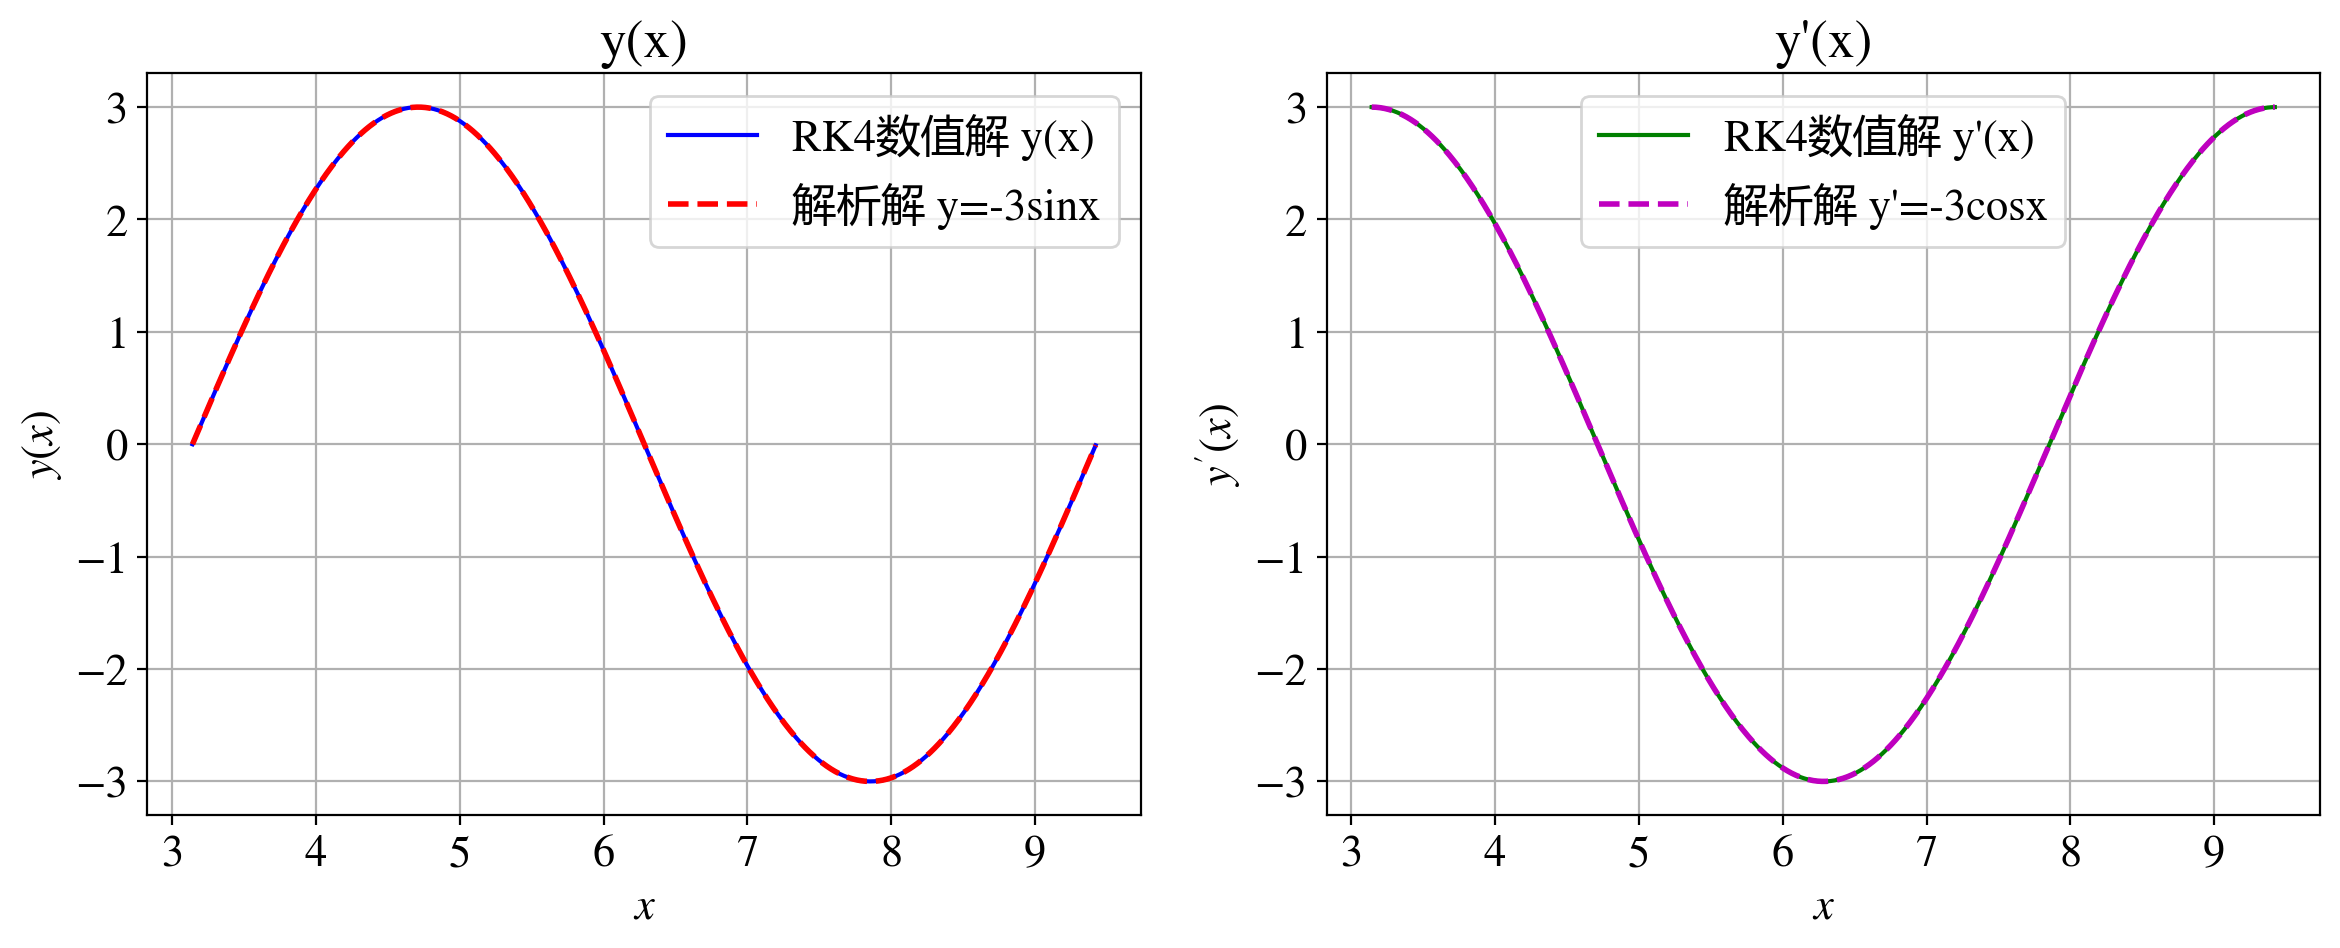

部分求解结果（x, 数值解y(x), 解析解y(x)）：
x = 3.1416, 数值解y = 0.000000, 解析解y = -0.000000, 误差 = 0.00000000
x = 3.6416, 数值解y = 1.438277, 解析解y = 1.438277, 误差 = 0.00000000
x = 4.1416, 数值解y = 2.524413, 解析解y = 2.524413, 误差 = 0.00000000
x = 4.6416, 数值解y = 2.992485, 解析解y = 2.992485, 误差 = 0.00000000
x = 5.1416, 数值解y = 2.727892, 解析解y = 2.727892, 误差 = 0.00000000


In [149]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. 定义一阶方程组的右端函数 =====================
# 二阶ODE: y'' = -y
# 转换为一阶系统：令 y1 = y, y2 = y'
# 则 y1' = y2,  y2' = -y1
def f(x, Y):
    """
    输入：
    x: 当前自变量值
    Y: 状态向量 [y1, y2]，其中 y1=y, y2=y'
    返回：
    [y1', y2'] 即 [y2, -y1]
    """
    y1, y2 = Y
    return np.array([y2, -y1])

# ===================== 2. 定义RK4单步计算函数（适配向量） =====================
def rk4_step(func, x, Y, h):
    """
    单步RK4计算（支持向量形式的状态）
    参数：
    func: 一阶方程组的右端函数
    x: 当前x值
    Y: 当前状态向量 [y1, y2]
    h: 步长
    返回：
    下一步的状态向量 Y_new
    """
    k1 = func(x, Y)
    k2 = func(x + h/2, Y + h*k1/2)
    k3 = func(x + h/2, Y + h*k2/2)
    k4 = func(x + h,   Y + h*k3)
    Y_new = Y + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return Y_new

# ===================== 3. 定义RK4求解器（适配方程组） =====================
def RK4_solver(func, x0, Y0, X, h):
    """
    RK4求解一阶常微分方程组初值问题
    参数：
    func: 一阶方程组右端函数
    x0: 初始x值
    Y0: 初始状态向量 [y10, y20]
    X: 终止x值
    h: 步长
    返回：
    x_list: 所有x节点数组
    Y_list: 状态向量数组（每行对应一个x，列对应y1/y2）
    """
    # 计算总步数
    N = int((X - x0) / h)
    # 初始化数组（Y_list.shape = (N+1, 2)，存储y1和y2）
    x_list = np.zeros(N + 1)
    Y_list = np.zeros((N + 1, len(Y0)))
    
    # 赋初值
    x_list[0] = x0
    Y_list[0] = Y0
    
    # 迭代计算
    for n in range(N):
        x_list[n+1] = x_list[n] + h
        Y_list[n+1] = rk4_step(func, x_list[n], Y_list[n], h)
    
    return x_list, Y_list

# ===================== 4. 求解参数设置 =====================
x0 = np.pi          # 初始x值（题目给定的初始点π）
Y0 = np.array([0, 3])# 初始状态 [y1(π), y2(π)] = [y(π), y'(π)] = [0, 3]
X = np.pi + 2*np.pi # 求解终止x（从π到π+2π，覆盖一个完整周期）
h = 0.01            # 步长（越小精度越高）

# ===================== 5. 执行求解 =====================
x_vals, Y_vals = RK4_solver(f, x0, Y0, X, h)
y1_vals = Y_vals[:, 0]  # 提取y1 = y(x)的数值解
y2_vals = Y_vals[:, 1]  # 提取y2 = y'(x)的数值解

# ===================== 6. 解析解（用于验证） =====================
# 二阶ODE y''=-y的通解：y = C1*cosx + C2*sinx
# 代入初始条件 y(π)=0 → -C1 = 0 → C1=0
# y' = -C1*sinx + C2*cosx，代入y'(π)=3 → -C2 = 3 → C2=-3
# 最终解析解：y = -3*sinx
y_exact = -3 * np.sin(x_vals)
y_prime_exact = -3 * np.cos(x_vals)  # y'的解析解

# ===================== 7. 绘图对比 =====================
plt.figure(figsize=(12, 5))

# 子图1：y(x)的数值解 vs 解析解
plt.subplot(1, 2, 1)
plt.plot(x_vals, y1_vals, 'b-', label='RK4数值解 y(x)', linewidth=1.5)
plt.plot(x_vals, y_exact, 'r--', label='解析解 y=-3sinx', linewidth=2)
plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.title('y(x)')
plt.grid(True)
plt.legend()

# 子图2：y'(x)的数值解 vs 解析解
plt.subplot(1, 2, 2)
plt.plot(x_vals, y2_vals, 'g-', label='RK4数值解 y\'(x)', linewidth=1.5)
plt.plot(x_vals, y_prime_exact, 'm--', label='解析解 y\'=-3cosx', linewidth=2)
plt.xlabel('$x$')
plt.ylabel('$y\'(x)$')
plt.title('y\'(x)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 输出部分结果验证
print("部分求解结果（x, 数值解y(x), 解析解y(x)）：")
sample_indices = [0, 50, 100, 150, 200]  # 选取几个点验证
for i in sample_indices:
    x = x_vals[i]
    y_num = y1_vals[i]
    y_ana = y_exact[i]
    print(f"x = {x:.4f}, 数值解y = {y_num:.6f}, 解析解y = {y_ana:.6f}, 误差 = {abs(y_num-y_ana):.8f}")


4. 数值求解微分方程：

$$
\begin{cases}
u''(x) + q(x)u(x) = x,\quad 0 < x < 1, \\
u(0)=0,\\ 
u(1)=0,
\end{cases}
$$

其中

$$
q(x) =
\begin{cases}
1 + x, & x < 0.5,\\
1, & x > 0.5.
\end{cases}
$$



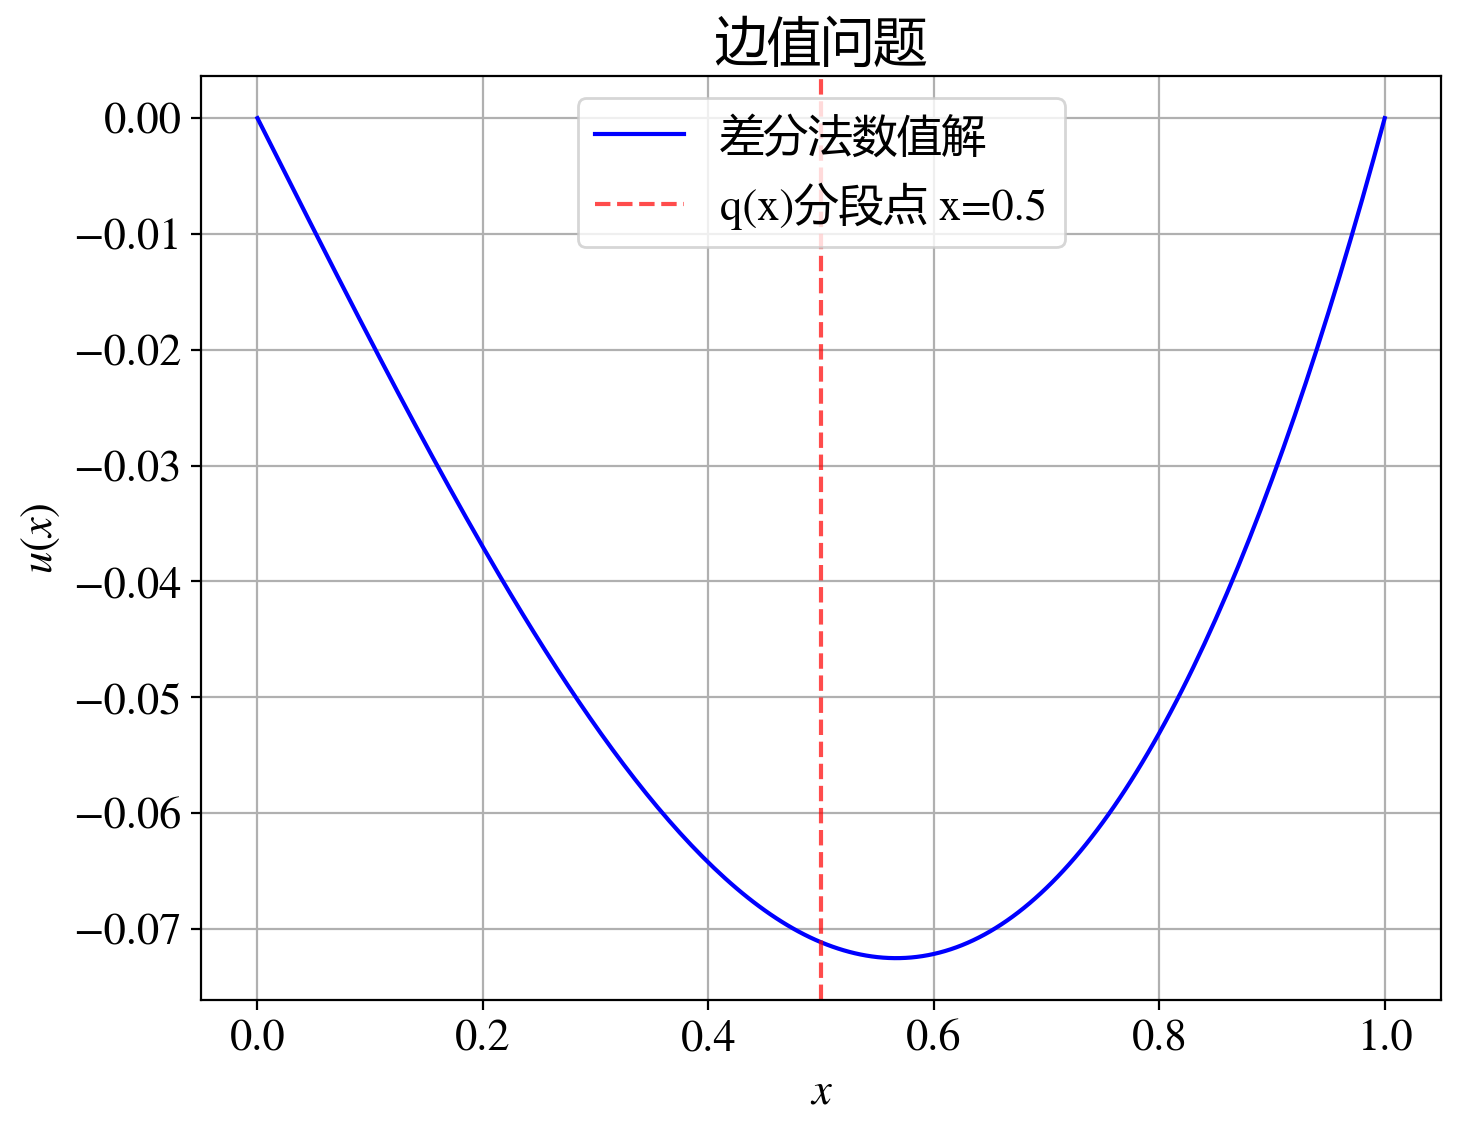

关键位置的u(x)值：
x=0.0 (边界)：u = 0.000000
x=0.25      ：u = -0.045138
x=0.5 (分段点)：u = -0.071152
x=0.75      ：u = -0.060781
x=1.0 (边界)：u = 0.000000


In [154]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. 定义分段函数 q(x) =====================
def q(x):
    """
    分段函数 q(x)：
    - x < 0.5 时，q(x) = 1 + x
    - x > 0.5 时，q(x) = 1
    - x = 0.5 时，取任意一侧均可（这里取1 + x）
    """
    if x <= 0.5:
        return 1 + x
    else:
        return 1

# 向量化q函数（方便批量计算网格点的q值）
q_vec = np.vectorize(q)

# ===================== 2. 差分法求解设置 =====================
# 离散化区间 [0, 1]
a, b = 0.0, 1.0
N = 200  # 网格数（将区间分为N段，共N+1个网格点，N越大精度越高）
h = (b - a) / N  # 步长
x = np.linspace(a, b, N+1)  # 网格点 x_0, x_1, ..., x_N

# 边界条件
u0 = 0.0  # u(0) = 0
uN = 0.0  # u(1) = 0

# ===================== 3. 构建三对角矩阵 A 和右端向量 b =====================
# 内部点数量：N-1 个（i=1 到 i=N-1）
A = np.zeros((N-1, N-1))  # 系数矩阵（三对角）
b_vec = np.zeros(N-1)     # 右端向量

for i in range(1, N):  # i 对应网格点 x_i（内部点），行索引为 i-1
    xi = x[i]
    qi = q(xi)  # 当前点的q值
    
    # 微分方程离散化：(u_{i+1}-2u_i+u_{i-1})/h² + q(xi)u_i = xi
    # 整理得：u_{i-1} - [2 - h²*q(xi)]u_i + u_{i+1} = h²*xi
    # 对应矩阵元素：主对角线为 -(2 - h²*qi)，上下次对角线为 1
    
    # 主对角线元素 A[i-1, i-1]
    A[i-1, i-1] = -(2 - h**2 * qi)
    
    # 下对角线（i>1 时，对应 u_{i-1}）
    if i > 1:
        A[i-1, i-2] = 1.0
    
    # 上对角线（i<N-1 时，对应 u_{i+1}）
    if i < N-1:
        A[i-1, i+1-1] = 1.0  # i+1的行索引是 i（因为行索引从0开始）
    
    # 右端向量：h² * xi
    b_vec[i-1] = h**2 * xi

# ===================== 4. 求解线性方程组 A * u_inner = b_vec =====================
u_inner = np.linalg.solve(A, b_vec)  # 内部点的u值

# 拼接边界条件，得到完整的u(x)
u = np.zeros(N+1)
u[0] = u0          # 左边界 u(0)=0
u[1:N] = u_inner   # 内部点
u[N] = uN          # 右边界 u(1)=0

# ===================== 5. 结果可视化 =====================
plt.figure(figsize=(8, 6))
plt.plot(x, u, 'b-', linewidth=1.5, label='差分法数值解')
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='q(x)分段点 x=0.5')
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title('边值问题')
plt.grid(True)
plt.legend()
plt.show()

# 输出关键位置的解（验证）
print("关键位置的u(x)值：")
print(f"x=0.0 (边界)：u = {u[0]:.6f}")
print(f"x=0.25      ：u = {u[int(0.25/h)]:.6f}")
print(f"x=0.5 (分段点)：u = {u[int(0.5/h)]:.6f}")
print(f"x=0.75      ：u = {u[int(0.75/h)]:.6f}")
print(f"x=1.0 (边界)：u = {u[-1]:.6f}")

5. 数值求解微分方程：

$$
\begin{cases}
u'' = -\pi^2(u+1)/4, \\
u(0)=0,\\
u(1)=1.
\end{cases}
$$

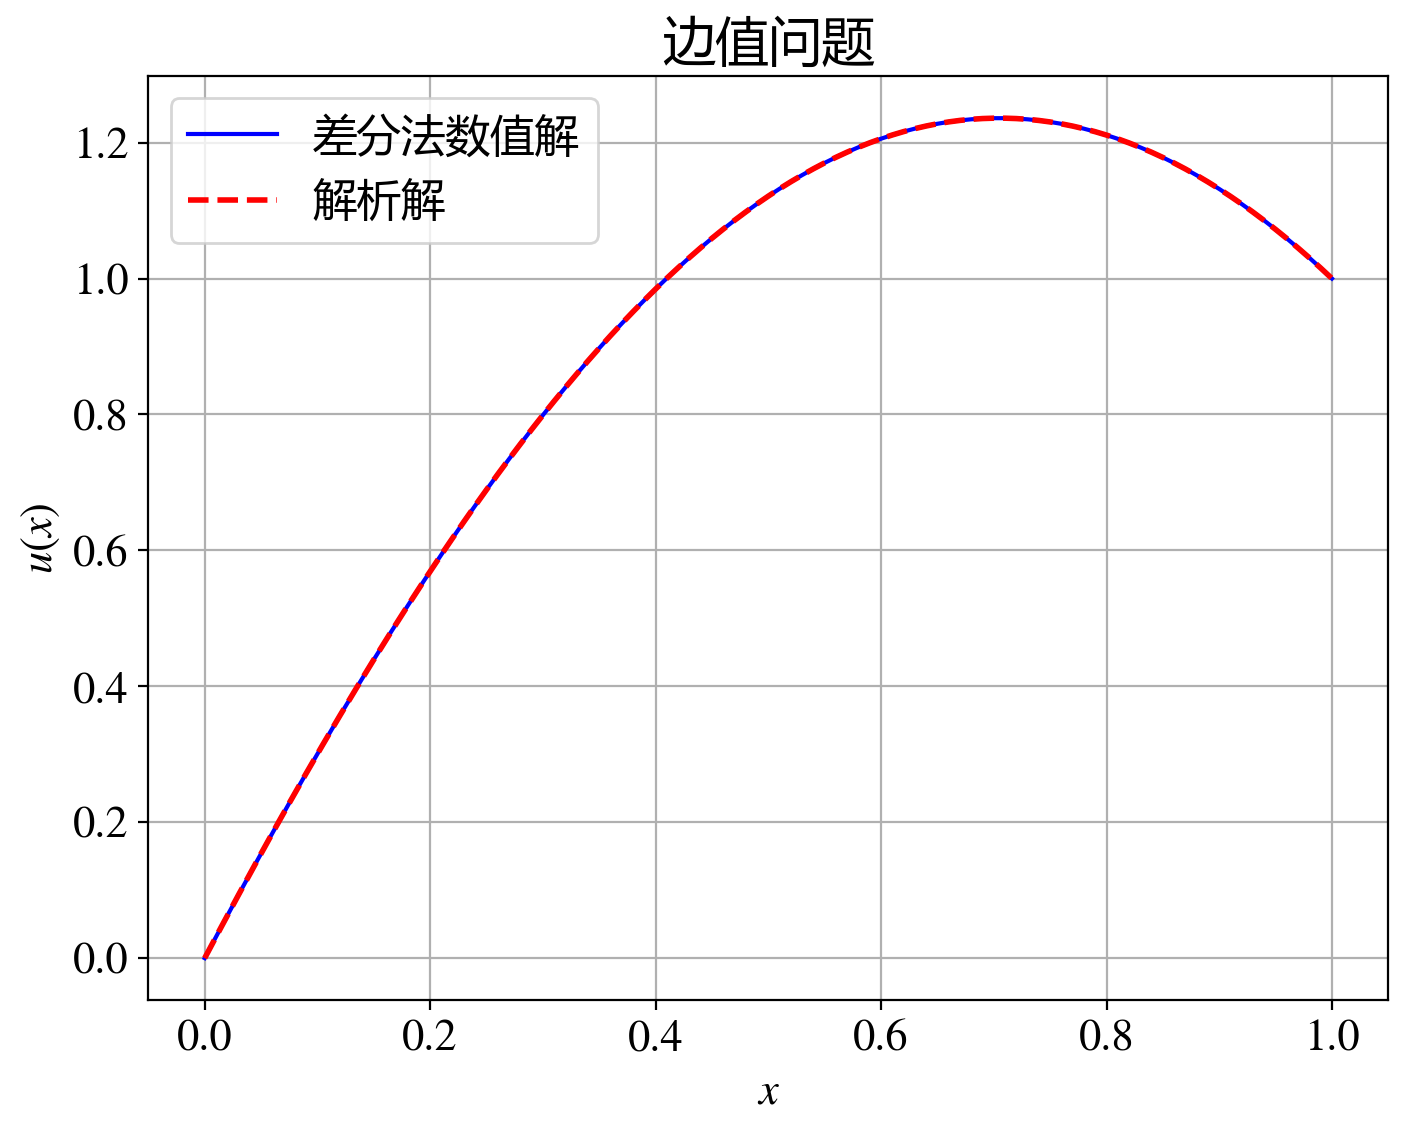

关键位置的求解结果对比：
x=0.00 | 数值解=0.000000 | 解析解=0.000000 | 误差=0.00000000
x=0.25 | 数值解=0.689249 | 解析解=0.689246 | 误差=0.00000302
x=0.50 | 数值解=1.121325 | 解析解=1.121320 | 误差=0.00000428
x=0.75 | 数值解=1.230446 | 解析解=1.230442 | 误差=0.00000325
x=1.00 | 数值解=1.000000 | 解析解=1.000000 | 误差=0.00000000


In [167]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. 求解参数设置 =====================
# 离散化区间 [0, 1]
a, b = 0.0, 1.0
N = 200  # 网格数（将区间分为N段，共N+1个网格点，N越大精度越高）
h = (b - a) / N  # 步长
x = np.linspace(a, b, N+1)  # 网格点 x_0, x_1, ..., x_N

# 边界条件
u0 = 0.0  # u(0) = 0
uN = 1.0  # u(1) = 1

# 常数项：π²/4
pi_sq_div4 = (np.pi ** 2) / 4

# ===================== 2. 构建三对角矩阵 A 和右端向量 b =====================
# 内部点数量：N-1 个（i=1 到 i=N-1）
A = np.zeros((N-1, N-1))  # 系数矩阵（三对角）
b_vec = np.zeros(N-1)     # 右端向量

for i in range(1, N):  # i 对应网格点 x_i（内部点），行索引为 i-1
    # 微分方程离散化推导：
    # 原方程：u'' = -π²(u+1)/4
    # 中心差分：u''(x_i) ≈ (u_{i+1}-2u_i+u_{i-1})/h²
    # 代入得：(u_{i+1}-2u_i+u_{i-1})/h² = -π²(u_i + 1)/4
    # 整理：u_{i-1} - [2 - h²π²/4]u_i + u_{i+1} = -h²π²/4
    
    # 主对角线元素：-(2 - h²π²/4)
    A[i-1, i-1] = -(2 - h**2 * pi_sq_div4)
    
    # 下对角线（i>1 时，对应 u_{i-1}）
    if i > 1:
        A[i-1, i-2] = 1.0
    
    # 上对角线（i<N-1 时，对应 u_{i+1}）
    if i < N-1:
        A[i-1, i+1-1] = 1.0  # i+1的行索引是 i（行索引从0开始）
    
    # 右端向量基础项：-h²π²/4
    b_vec[i-1] = - h**2 * pi_sq_div4

# 处理边界条件的影响：
# 1. 左边界 u0=0（i=1 时，u_{0} 项的系数为1，移到右端）
b_vec[0] -= 1.0 * u0  # 原方程中 i=1 时的 u_{0} 项：1*u0 → 移到右端为 -1*u0

# 2. 右边界 uN=1（i=N-1 时，u_{N} 项的系数为1，移到右端）
b_vec[-1] -= 1.0 * uN  # 原方程中 i=N-1 时的 u_{N} 项：1*uN → 移到右端为 -1*uN

# ===================== 3. 求解线性方程组 A * u_inner = b_vec =====================
u_inner = np.linalg.solve(A, b_vec)  # 内部点的u值

# 拼接边界条件，得到完整的u(x)
u = np.zeros(N+1)
u[0] = u0          # 左边界 u(0)=0
u[1:N] = u_inner   # 内部点
u[N] = uN          # 右边界 u(1)=1

# ===================== 4. 解析解（用于验证） =====================
# 原方程的解析解推导：
# 齐次解：C1*cos(πx/2) + C2*sin(πx/2)
# 特解：-1
# 通解：u = cos(πx/2) + 2sin(πx/2) - 1（代入边界条件求得C1=1, C2=2）
u_exact = np.cos(np.pi * x / 2) + 2 * np.sin(np.pi * x / 2) - 1

# ===================== 5. 结果可视化 =====================
plt.figure(figsize=(8, 6))
plt.plot(x, u, 'b-', linewidth=1.5, label='差分法数值解')
plt.plot(x, u_exact, 'r--', linewidth=2, label='解析解')
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title('边值问题')
plt.grid(True)
plt.legend()
plt.show()

# ===================== 6. 验证结果（输出关键位置值） =====================
print("关键位置的求解结果对比：")
# 选取x=0, 0.25, 0.5, 0.75, 1.0的点
sample_x = [0.0, 0.25, 0.5, 0.75, 1.0]
for xi in sample_x:
    idx = int(xi / h)  # 对应网格点索引
    u_num = u[idx]
    u_ana = np.cos(np.pi * xi / 2) + 2 * np.sin(np.pi * xi / 2) - 1
    print(f"x={xi:.2f} | 数值解={u_num:.6f} | 解析解={u_ana:.6f} | 误差={abs(u_num-u_ana):.8f}")

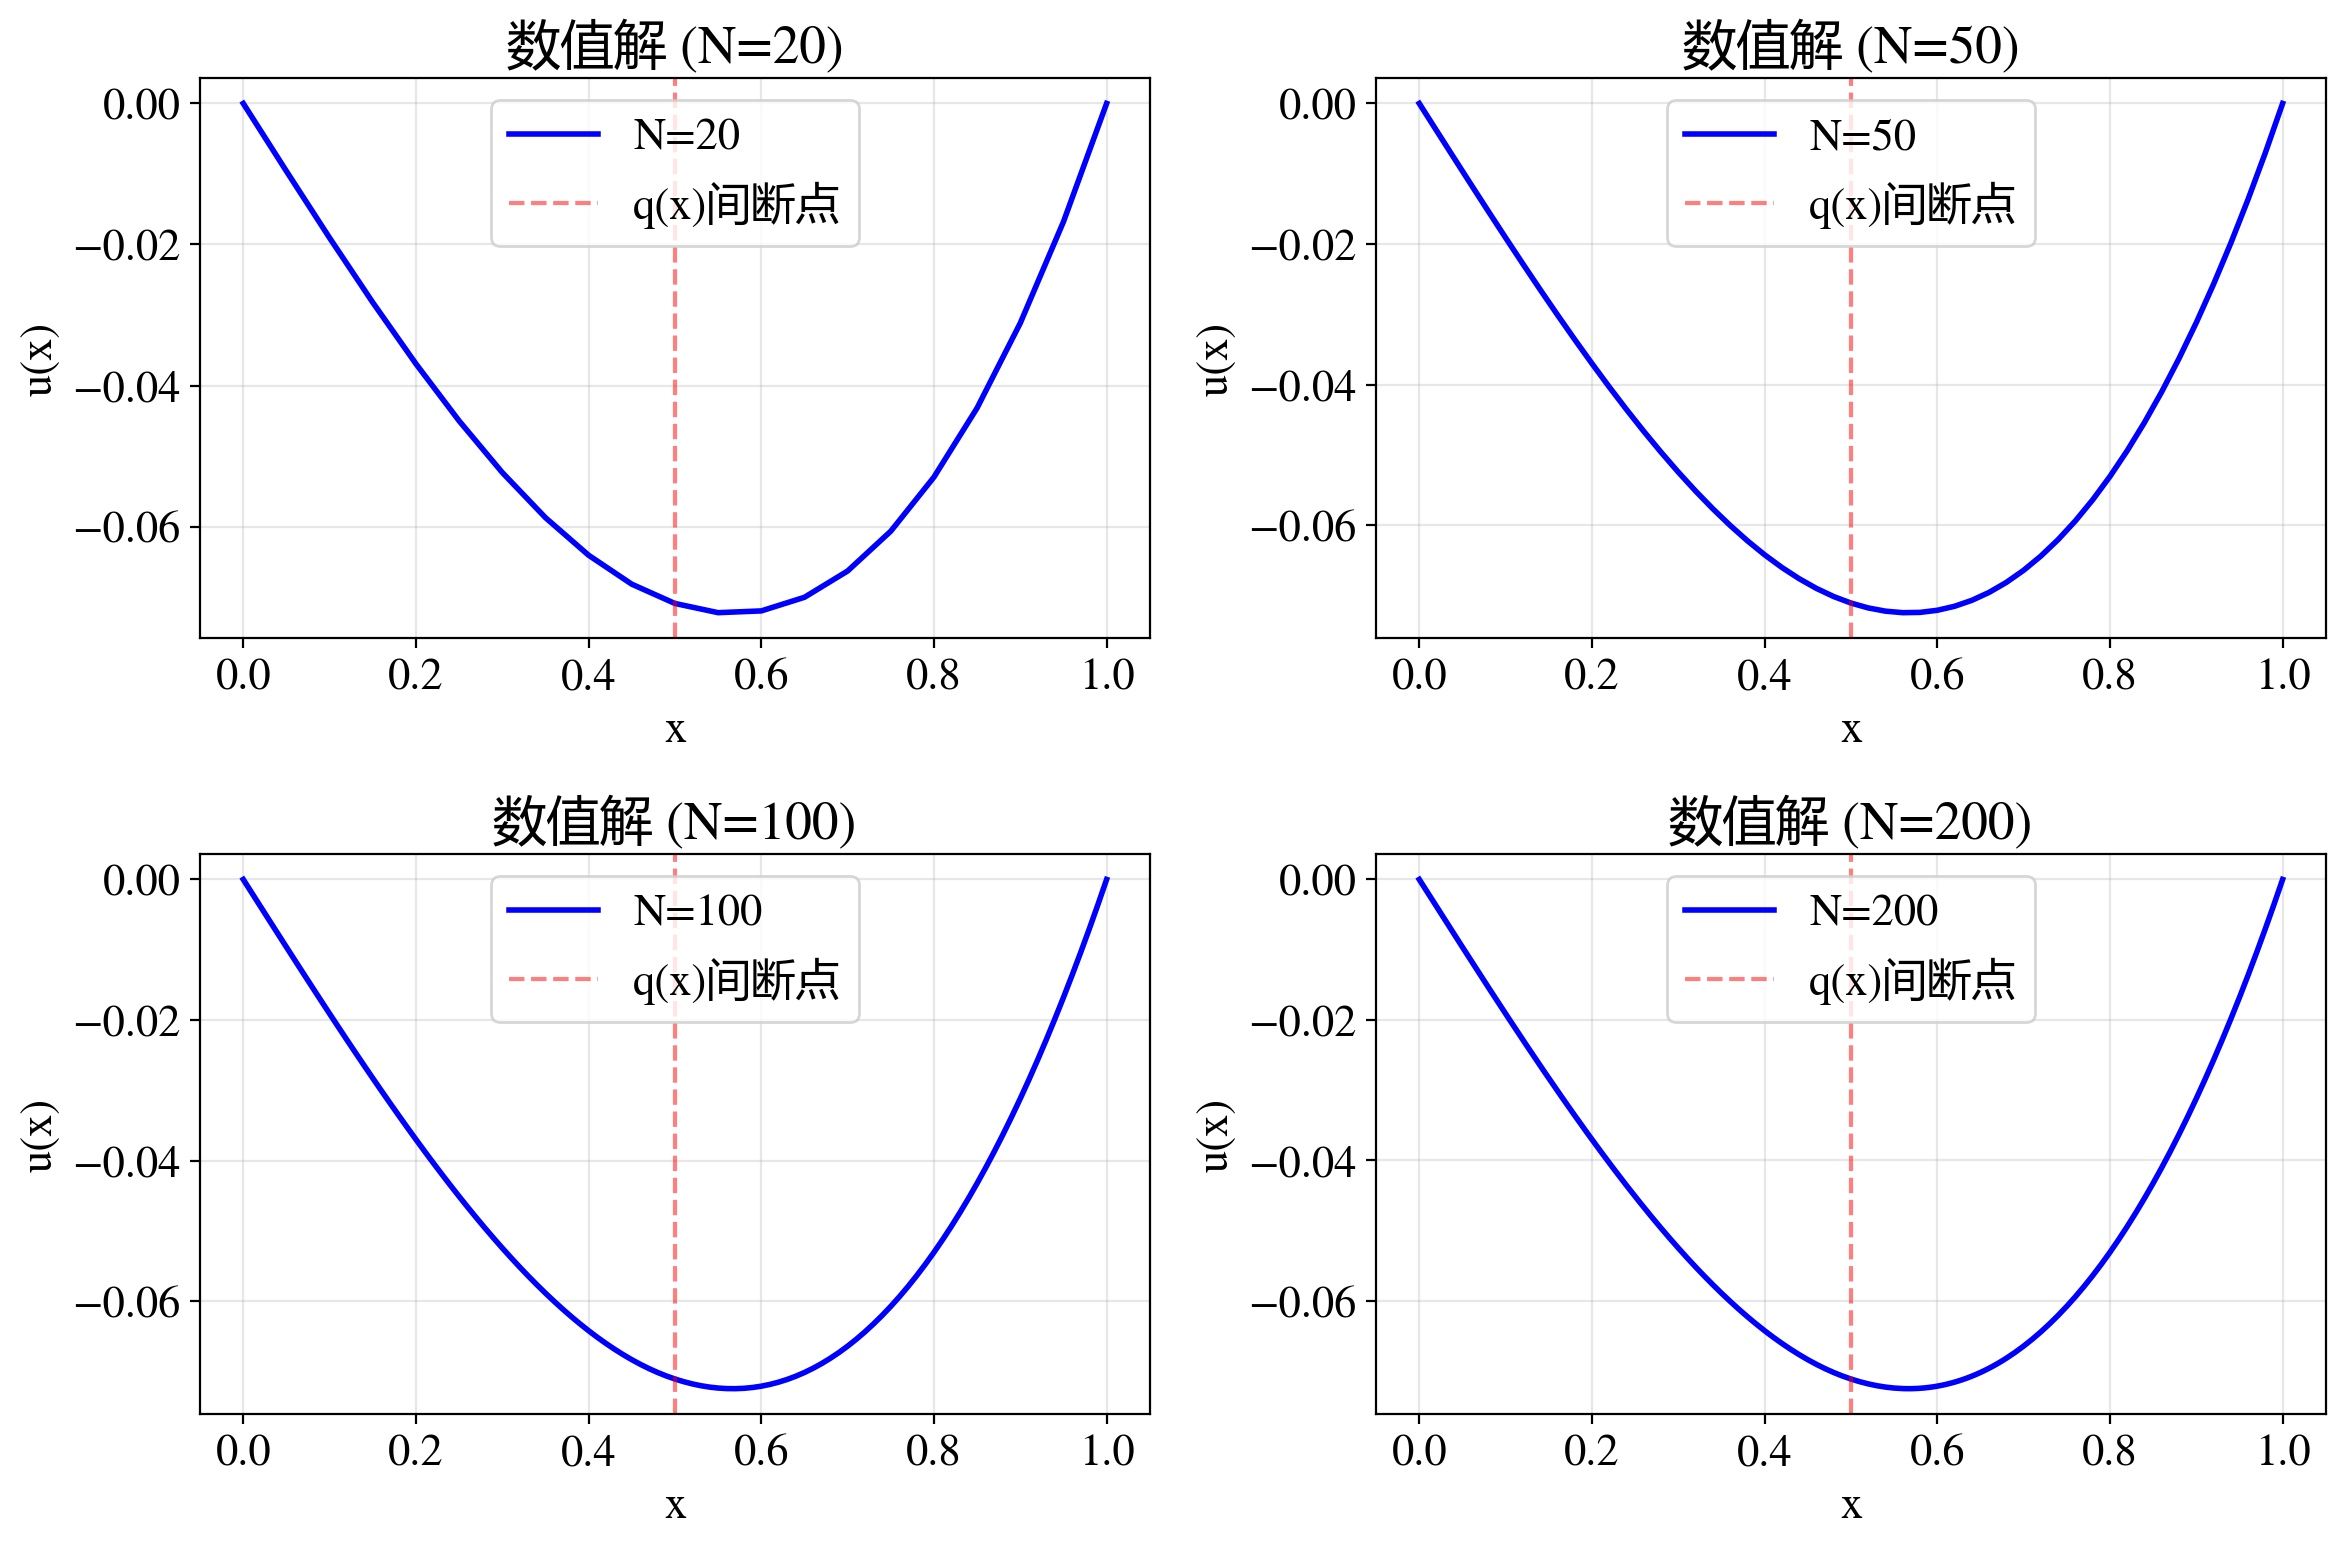

不同网格密度下在关键点的解值:
x			N=20		N=50		N=100		N=200
----------------------------------------------------------------------
0.25		-0.045011		-0.043512		-0.045100		-0.045112
0.50		-0.070906		-0.071032		-0.071078		-0.071102
0.75		-0.060660		-0.062010		-0.060743		-0.060756


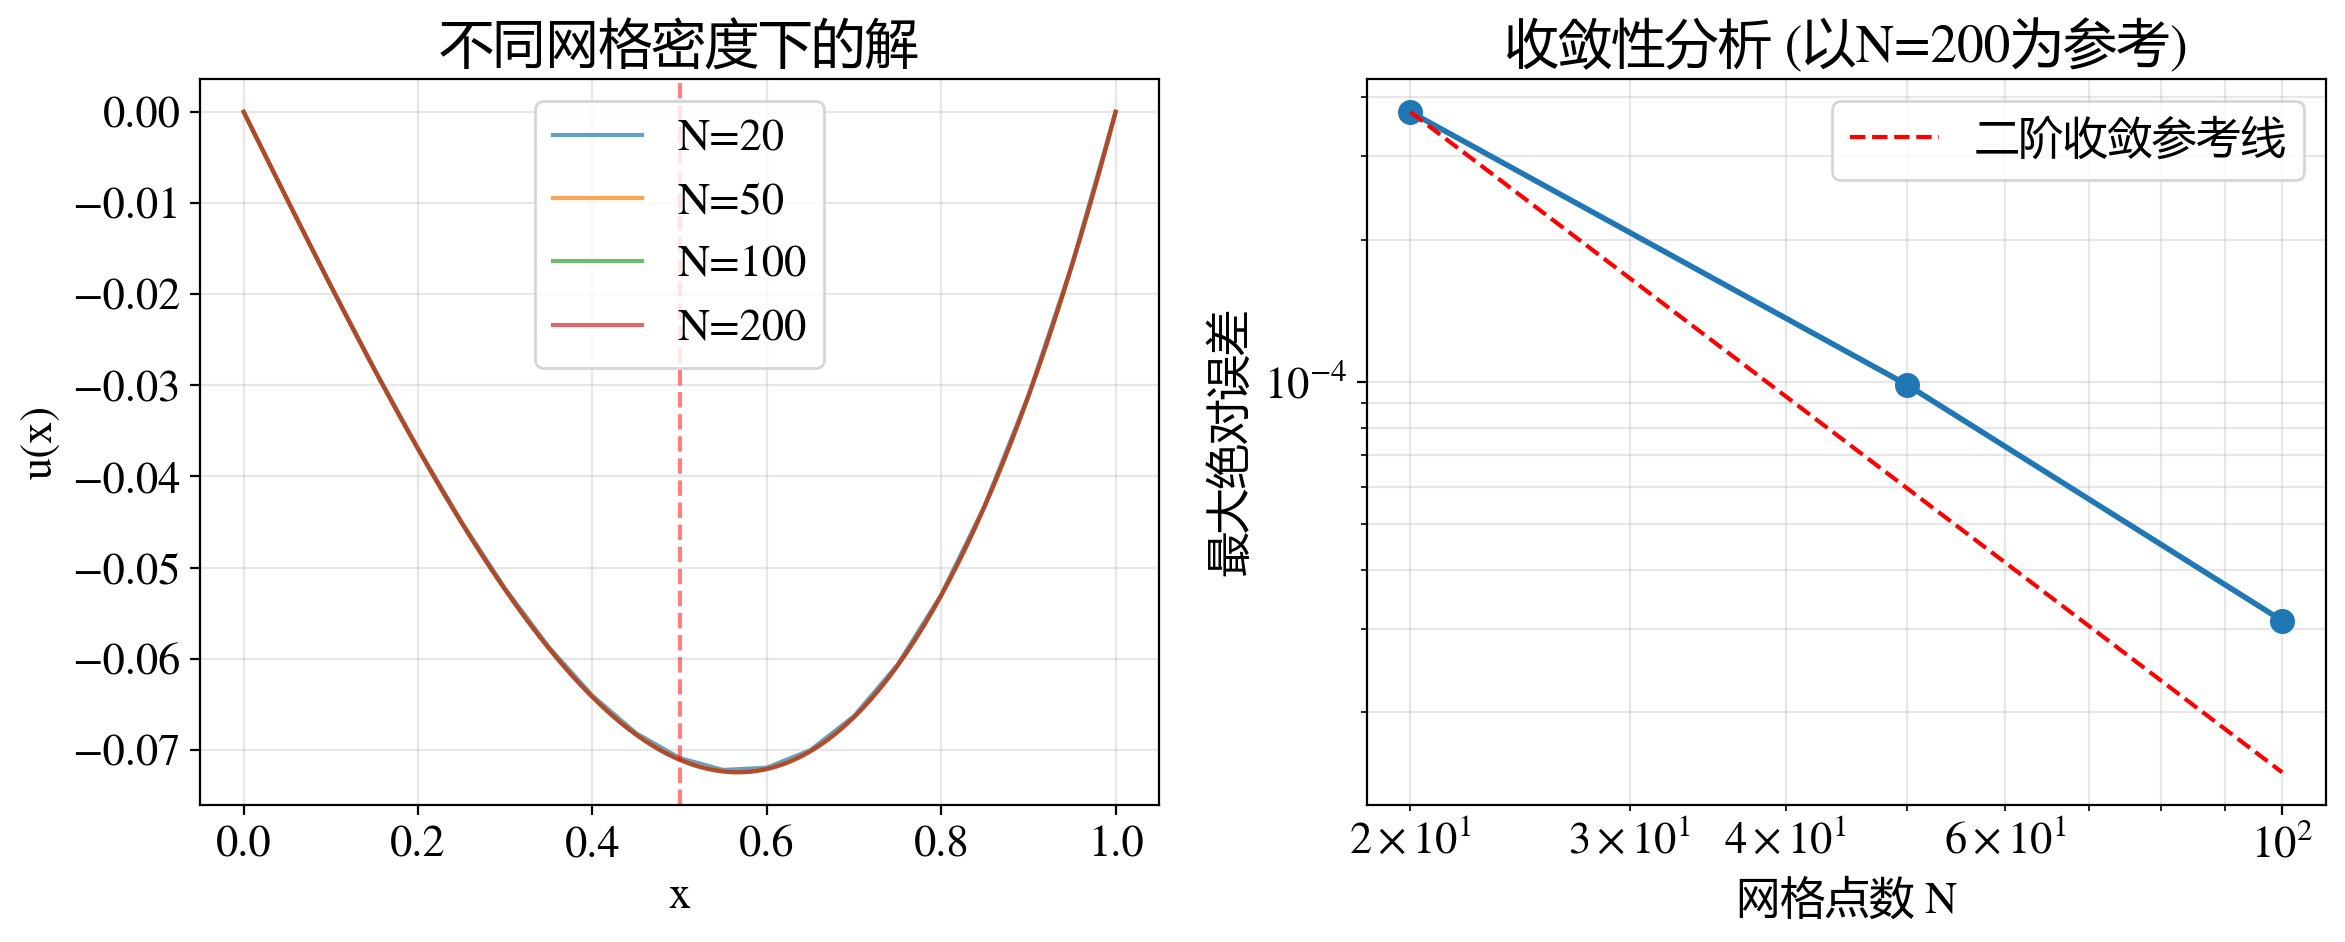


在x=0.5附近的解值:
x		u(x)
------------------------------
0.4500		-0.068350
0.4550		-0.068690
0.4600		-0.069015
0.4650		-0.069327
0.4700		-0.069624
0.4750		-0.069907
0.4800		-0.070176
0.4850		-0.070429
0.4900		-0.070669
0.4950		-0.070893
0.5000		-0.071102
0.5050		-0.071297
0.5100		-0.071478
0.5150		-0.071644
0.5200		-0.071795
0.5250		-0.071932
0.5300		-0.072054
0.5350		-0.072160
0.5400		-0.072252
0.5450		-0.072328
0.5500		-0.072389

在x=0.5处的导数近似（中心差分）:
u'(0.5) ≈ -0.040430


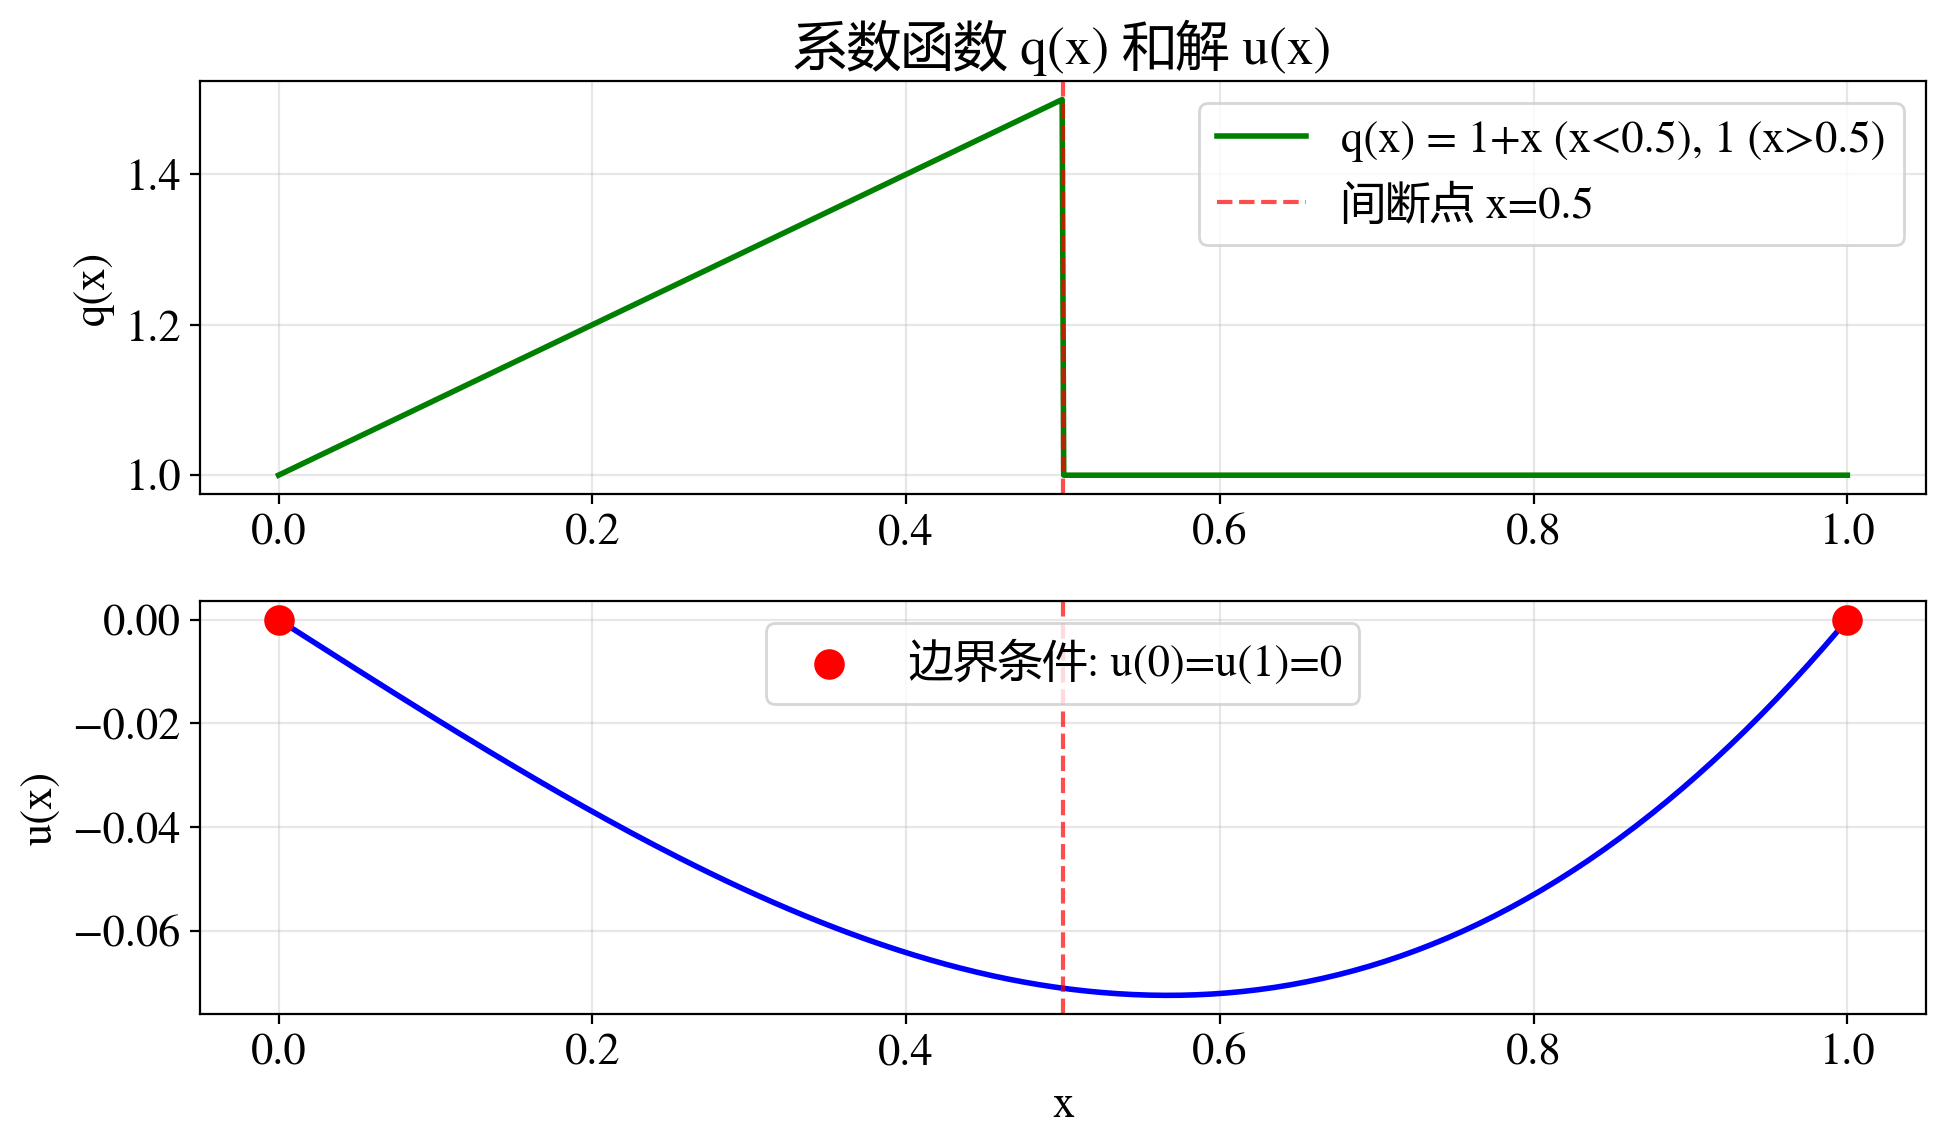


数值验证：检查残差
最大残差: 2.491978e-05
平均绝对残差: 1.712585e-07


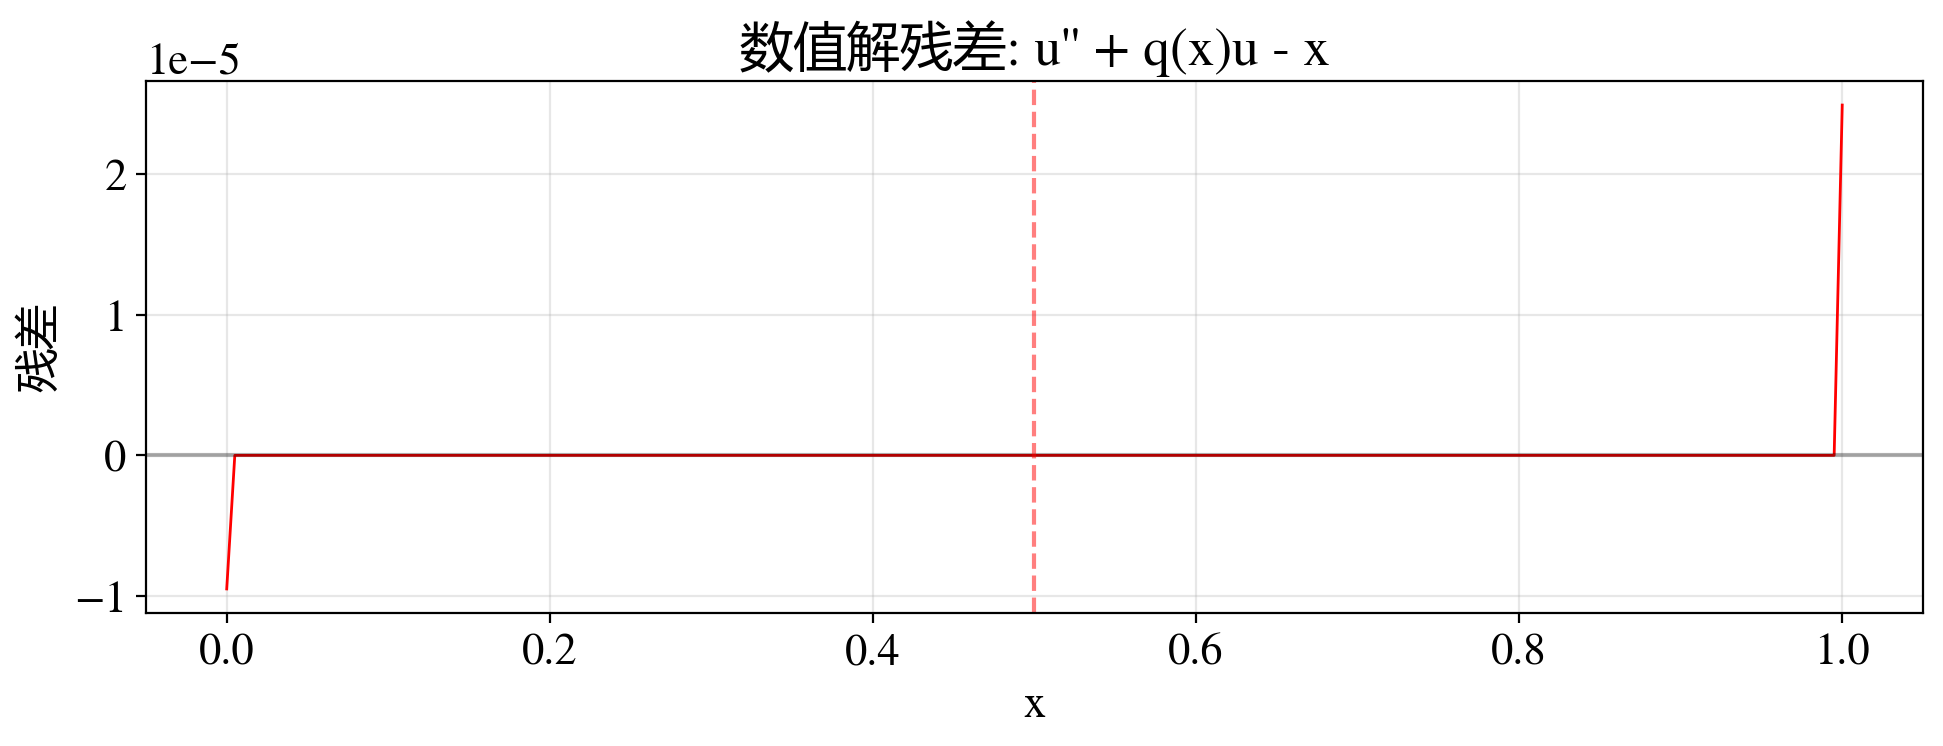

In [169]:
import numpy as np
import matplotlib.pyplot as plt

# 定义分段函数 q(x)
def q(x):
    """分段系数函数"""
    return np.where(x < 0.5, 1 + x, 1)

# 有限差分法求解边值问题
def solve_bvp_fd(N=100):
    """使用有限差分法求解边值问题"""
    
    # 定义区间和步长
    a, b = 0.0, 1.0
    h = (b - a) / N  # 步长
    
    # 网格点
    x = np.linspace(a, b, N+1)
    
    # 边界条件
    u0 = 0.0  # u(0) = 0
    uN = 0.0  # u(1) = 0
    
    # 构造系数矩阵 A (三对角矩阵)
    A = np.zeros((N-1, N-1))  # 内部点从 i=1 到 i=N-1
    b_vec = np.zeros(N-1)     # 右端项
    
    for i in range(1, N):  # i 对应内部点索引，从 1 到 N-1
        xi = a + i * h
        row = i - 1  # 矩阵行索引
        
        # 三对角矩阵元素
        if i > 1:  # 非第一行，有左邻居
            A[row, row-1] = 1 / h**2
        
        # 主对角元素: -2/h² + q(x_i)
        A[row, row] = -2 / h**2 + q(xi)
        
        if i < N-1:  # 非最后一行，有右邻居
            A[row, row+1] = 1 / h**2
        
        # 右端项: x_i
        b_vec[row] = xi
    
    # 求解线性方程组
    u_inner = np.linalg.solve(A, b_vec)
    
    # 构造完整解（包含边界点）
    u = np.zeros(N+1)
    u[0] = u0
    u[1:-1] = u_inner
    u[-1] = uN
    
    return x, u

# 使用不同网格密度求解
N_values = [20, 50, 100, 200]
solutions = {}

plt.figure(figsize=(12, 8))

# 绘制不同N下的解
for i, N in enumerate(N_values):
    x, u = solve_bvp_fd(N)
    solutions[N] = (x, u)
    
    plt.subplot(2, 2, i+1)
    plt.plot(x, u, 'b-', linewidth=2, label=f'N={N}')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'数值解 (N={N})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 标记间断点
    plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='q(x)间断点')
    plt.legend()

plt.tight_layout()
plt.show()

# 对比不同N下的解在关键点的值
print("不同网格密度下在关键点的解值:")
print("x\t\t\tN=20\t\tN=50\t\tN=100\t\tN=200")
print("-" * 70)

key_points = [0.25, 0.5, 0.75]
for x_point in key_points:
    row = f"{x_point:.2f}"
    for N in N_values:
        x, u = solutions[N]
        # 找到最接近的网格点
        idx = np.argmin(np.abs(x - x_point))
        row += f"\t\t{u[idx]:.6f}"
    print(row)

# 绘制更详细的解
plt.figure(figsize=(12, 5))

# 子图1：解的形状
plt.subplot(1, 2, 1)
for N in N_values:
    x, u = solutions[N]
    plt.plot(x, u, label=f'N={N}', alpha=0.7, linewidth=1.5)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('不同网格密度下的解')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.5)

# 子图2：收敛性检查（以N=200为参考）
plt.subplot(1, 2, 2)
x_ref, u_ref = solutions[200]  # 以N=200为参考解

errors = []
N_list = [20, 50, 100]
for N in N_list:
    x, u = solutions[N]
    # 在参考解的网格上插值
    u_interp = np.interp(x_ref, x, u)
    error = np.max(np.abs(u_interp - u_ref))
    errors.append(error)

plt.loglog(N_list, errors, 'o-', linewidth=2, markersize=8)
plt.xlabel('网格点数 N')
plt.ylabel('最大绝对误差')
plt.title('收敛性分析 (以N=200为参考)')
plt.grid(True, which="both", alpha=0.3)

# 添加收敛阶参考线
ref_N = np.array(N_list)
ref_error = errors[0] * (ref_N[0] / ref_N)**2  # 二阶收敛
plt.loglog(ref_N, ref_error, 'r--', label='二阶收敛参考线')
plt.legend()

plt.tight_layout()
plt.show()

# 分析解在间断点附近的行为
print("\n在x=0.5附近的解值:")
N = 200  # 使用最细的网格
x, u = solve_bvp_fd(N)

# 找到x=0.5附近的点
mask = (x >= 0.45) & (x <= 0.55)
print(f"x\t\tu(x)")
print("-" * 30)
for xi, ui in zip(x[mask], u[mask]):
    print(f"{xi:.4f}\t\t{ui:.6f}")

# 计算解的导数值（中心差分）
print("\n在x=0.5处的导数近似（中心差分）:")
h = 1/N
idx_mid = N//2  # 最接近0.5的索引
u_prime = (u[idx_mid+1] - u[idx_mid-1]) / (2*h)
print(f"u'(0.5) ≈ {u_prime:.6f}")

# 绘制q(x)函数和解
plt.figure(figsize=(10, 6))

# 绘制q(x)
x_plot = np.linspace(0, 1, 1000)
q_plot = q(x_plot)

ax1 = plt.subplot(2, 1, 1)
plt.plot(x_plot, q_plot, 'g-', linewidth=2)
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7)
plt.ylabel('q(x)')
plt.title('系数函数 q(x) 和解 u(x)')
plt.grid(True, alpha=0.3)
plt.legend(['q(x) = 1+x (x<0.5), 1 (x>0.5)', '间断点 x=0.5'])

# 绘制解u(x)
ax2 = plt.subplot(2, 1, 2)
x, u = solve_bvp_fd(200)
plt.plot(x, u, 'b-', linewidth=2)
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(True, alpha=0.3)

# 标记边界条件
plt.scatter([0, 1], [0, 0], color='red', s=100, zorder=5, 
           label='边界条件: u(0)=u(1)=0')
plt.legend()

plt.tight_layout()
plt.show()

# 验证解是否满足微分方程（数值验证）
print("\n数值验证：检查残差")
N = 200
x, u = solve_bvp_fd(N)
h = 1/N

# 使用中心差分计算二阶导数
u_double_prime = np.zeros_like(u)
u_double_prime[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / h**2

# 边界点的处理（使用单边差分）
u_double_prime[0] = (2*u[0] - 5*u[1] + 4*u[2] - u[3]) / h**2
u_double_prime[-1] = (2*u[-1] - 5*u[-2] + 4*u[-3] - u[-4]) / h**2

# 计算残差：u'' + q(x)u - x
residual = u_double_prime + q(x) * u - x

print(f"最大残差: {np.max(np.abs(residual)):.6e}")
print(f"平均绝对残差: {np.mean(np.abs(residual)):.6e}")

# 绘制残差
plt.figure(figsize=(10, 4))
plt.plot(x, residual, 'r-', linewidth=1)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('残差')
plt.title('数值解残差: u\'\' + q(x)u - x')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()